# Build POD Bases

This notebook constructs the displacement Proper Orthogonal Decomposition (POD) basis used by all four models (A-D) in the paper. **Inputs:** raw per-job finite-element output CSVs (`GOH_Job*_combined_data.csv`, one per simulated tissue-expansion job) that are **not** bundled in this repository -- point `DATA_DIR`/`CSV_DIR`/`CSV_GLOB` in the cells below at your own copy (see `data_processing/README.md` and `data/DATA_AVAILABILITY.md` for how to obtain the dataset).

**Pipeline:** parse nodal displacement snapshots from each job's CSV -> stack them into one snapshot matrix -> compute a full-rank SVD -> save the full left-singular-vector basis and mean to `displacements.zarr/pod_full/{U, mean}`. **Output:** `displacements.zarr/pod_full/{U, mean}` is read by every downstream training/evaluation script (outside this folder), which truncates the basis to its first r=9 modes (~99.99% cumulative snapshot energy) to build the r=9 displacement POD basis used throughout the paper's Methods section.

Later cells also contain exploratory/diagnostic code from development (residual checks, integration-point growth extraction, PK2 stress visualization, etc.) that is not required to reproduce the r=9 basis but is kept for reference.

## Setup and Loading Data

In [2]:
!pip install zarr numcodecs

In [9]:
from pathlib import Path
import re

# Point to your folder
DATA_DIR = Path(r"PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER")  # <-- set this to your local copy of the raw FE-output folder; see data_processing/README.md
# Glob pattern for all jobs 1..1000 (no zero padding assumed)
files = list(DATA_DIR.glob("GOH_Job*_combined_data.csv"))

# (Optional but nice) sort by the integer after "Job"
def job_num(p):
    m = re.search(r"Job(\d+)", p.stem)
    return int(m.group(1)) if m else 10**9

files = sorted(files, key=job_num)

# For the rest of the notebook, just set CSV_GLOB to this list
CSV_GLOB = [str(p) for p in files]

print(f"Found {len(CSV_GLOB)} CSVs. First 5:\n", "\n".join(CSV_GLOB[:5]))

Found 927 CSVs. First 5:
 PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\GOH_Job1_combined_data.csv
PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\GOH_Job2_combined_data.csv
PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\GOH_Job3_combined_data.csv
PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\GOH_Job4_combined_data.csv
PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\GOH_Job5_combined_data.csv


In [ ]:
import os, re
import numpy as np

# Assumes these already exist from your previous code:
# g_disp, sim_index, time_vals, converged_files

exp_vol_all = np.asarray(g_disp["expander_volume"]["cvol"])  # shape (S,)

def parse_job_id(path):
    """Extract the integer job ID from a path like ...GOH_Job793_combined_data.csv."""
    base = os.path.basename(path)
    m = re.search(r"Job(\d+)_combined", base)
    if not m:
        raise ValueError(f"Could not parse job ID from {base}")
    return int(m.group(1))

def load_combined_csv(csv_path):
    """
    Minimal parser for GOH_JobXXX_combined_data.csv:
    returns times_csv, vols_csv for each frame.
    """
    times = []
    vols  = []
    curr_time = None
    curr_vol  = None

    with open(csv_path, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("### Frame Time:"):
                # Commit previous frame if complete
                if curr_time is not None and curr_vol is not None:
                    times.append(curr_time)
                    vols.append(curr_vol)
                    curr_vol = None

                # line e.g. "### Frame Time: 1.4000 ###"
                parts = line.split()
                # parts = ['###', 'Frame', 'Time:', '1.4000', '###']
                t_str = parts[3]
                curr_time = float(t_str)

            elif line.startswith("CVOL"):
                # line e.g. "CVOL (MFLUID node):,101228.359375"
                v_str = line.split(",")[1]
                curr_vol = float(v_str)

        # commit last frame
        if curr_time is not None and curr_vol is not None:
            times.append(curr_time)
            vols.append(curr_vol)

    return np.array(times), np.array(vols)

def check_job_against_zarr(job_id, csv_dir, atol=1e-3):
    """
    For a given JobID, load its CSV, find matching volumes in Zarr,
    and see which sim_id (and which job in converged_files) it corresponds to.
    """
    csv_path = os.path.join(csv_dir, f"GOH_Job{job_id}_combined_data.csv")
    print(f"\n==============================")
    print(f"Checking Job {job_id} from {csv_path}")
    times_csv, vols_csv = load_combined_csv(csv_path)
    print(f"CSV frames: {len(times_csv)}")
    print("First 5 CSV times :", times_csv[:5])
    print("First 5 CSV vols  :", vols_csv[:5])

    # Use the second frame's volume (index 1) to avoid the shared initial volume
    if len(vols_csv) < 2:
        print("Not enough frames in CSV to match.")
        return

    v_target = vols_csv[1]
    z_matches = np.where(np.isclose(exp_vol_all, v_target, rtol=0.0, atol=atol))[0]

    if len(z_matches) == 0:
        print(f"No Zarr volume matches V_csv[1]={v_target:.6f} within atol={atol}")
        return

    # Take the first match as reference
    z0 = int(z_matches[0])
    sim_id_z = int(sim_index[z0])

    print(f"\nFirst matching Zarr index for frame 1 (t={times_csv[1]:.4f}): {z0}")
    print(f"sim_index[z0] = {sim_id_z}")

    # What job does this sim_id map to under current and shifted convention?
    def job_from_sim(sim_id, offset):
        idx = sim_id - 1 + offset
        if 0 <= idx < len(converged_files):
            return parse_job_id(converged_files[idx])
        return None

    job_current = job_from_sim(sim_id_z, 0)   # converged_files[sim_id-1]
    job_shifted = job_from_sim(sim_id_z, 1)   # converged_files[sim_id]

    print(f"Job from converged_files[sim_id-1] (current mapping): {job_current}")
    print(f"Job from converged_files[sim_id]   (shifted +1)     : {job_shifted}")

    # Print a small alignment table to check that we’re tracking the *right* place in Zarr
    print("\nFrame alignment (first few frames):")
    for k in range(1, min(6, len(times_csv))):
        zi = z0 + (k - 1)
        if zi >= len(exp_vol_all):
            break
        print(
            f"  frame {k:2d} | "
            f"t_csv={times_csv[k]:7.3f},  V_csv={vols_csv[k]:10.3f}  ||  "
            f"t_z={time_vals[zi]:7.3f}, V_z={exp_vol_all[zi]:10.3f}"
        )

# >>> EDIT THIS to point to your combined-data folder
CSV_DIR = r"PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER"  # <-- set this to your local copy; see data_processing/README.md

# Jobs you specifically mentioned
for jid in [114, 115, 793, 794]:
    check_job_against_zarr(jid, CSV_DIR)


## Build Displacement Snapshots and get a POD Basis

In [13]:
# CONFIG: edit these
ZARR_PATH  = "displacements.zarr"     # on-disk store for X, Phi, etc.
R_MODES    = 100                      # <-- number of POD modes to save (you can change later)
ROW_BLOCK  = 200_000                  # rows per streaming block; tune to your RAM
DTYPE_X    = "f4"                     # storage dtype for snapshots (float32 is plenty)

In [8]:
# Robust parser: no file iteration, no tell/seek conflicts
import re
import numpy as np
from typing import Iterator, Tuple, Optional, List

FRAME_RE = re.compile(r"^###\s*Frame Time:\s*([0-9.+-Ee]+)\s*###")
SECTION_NODAL = "=== NODAL DATA ==="

def iter_displacement_snapshots(csv_path: str) -> Iterator[Tuple[float, np.ndarray, np.ndarray]]:
    """
    Yields (time, node_labels, U) per frame for one CSV.
    U shape: (N,3) with columns [U1,U2,U3] in the file order.
    Assumes node order is identical across frames/files.
    """
    with open(csv_path, "r", encoding="utf-8", errors="ignore") as f:
        pushback: Optional[str] = None

        def readline() -> Optional[str]:
            nonlocal pushback
            if pushback is not None:
                s = pushback
                pushback = None
                return s
            s = f.readline()
            return s if s != "" else None  # None on EOF

        def unread(s: str):
            nonlocal pushback
            pushback = s

        # find next frame header
        while True:
            line = readline()
            if line is None:
                return
            m = FRAME_RE.match(line)
            if m:
                time_val = float(m.group(1))
                # skip CVOL line (next line)
                _ = readline()
                # advance to NODAL section
                while True:
                    line = readline()
                    if line is None:
                        return
                    if line.strip() == SECTION_NODAL:
                        break
                # header row
                header = readline()
                if header is None:
                    return
                cols = header.strip().split(",")
                if len(cols) < 4 or cols[0] != "NodeLabel":
                    raise ValueError(f"Unexpected nodal header in {csv_path}: {header}")

                nodes: List[int] = []
                rows: List[Tuple[float,float,float]] = []

                # read nodal table until next section or next frame
                while True:
                    line = readline()
                    if line is None:
                        break
                    s = line.strip()
                    if (not s) or s.startswith("===") or s.startswith("### Frame Time:"):
                        # push back for the outer loop to re-handle
                        unread(line)
                        break
                    parts = s.split(",")
                    if len(parts) < 4:
                        continue
                    try:
                        n  = int(parts[0])
                        u1 = float(parts[1]); u2 = float(parts[2]); u3 = float(parts[3])
                    except ValueError:
                        continue
                    nodes.append(n)
                    rows.append((u1,u2,u3))

                if nodes:
                    yield time_val, np.asarray(nodes, dtype=np.int64), np.asarray(rows, dtype=np.float32)
                # Loop continues to find the next frame header (using the pushback if set)

In [16]:
import glob, zarr, os, time
import numpy as np
from pathlib import Path

try:
    from numcodecs import Blosc
    _blosc = Blosc(cname="zstd", clevel=4, shuffle=Blosc.SHUFFLE)
except Exception:
    _blosc = None  # fallback: no compression
_blosc = None  # disable compression entirely if desired

def _require_array(g, name, shape, chunks, dtype):
    """
    Create-or-get an array that works on Zarr v2 or v3.
    Uses compression if available; otherwise uncompressed.
    """
    try:
        return g[name]
    except KeyError:
        pass

    try:
        if _blosc is not None:
            return g.require_array(name, shape=shape, chunks=chunks, dtype=dtype,
                                   compressors=[_blosc])
        else:
            return g.require_array(name, shape=shape, chunks=chunks, dtype=dtype)
    except TypeError:
        if _blosc is not None:
            return g.require_dataset(name, shape=shape, chunks=chunks, dtype=dtype,
                                     compressor=_blosc)
        else:
            return g.require_dataset(name, shape=shape, chunks=chunks, dtype=dtype)

# ---- CONFIG ----
N_CHECKPOINT = 50   # update checkpoint attrs every this many frames

def build_displacement_zarr_resume(csv_glob_or_list, zarr_path: str,
                                   chunks_snap: int = 16_384, dtype="f4"):
    """
    Resume-safe builder for displacement snapshots:
      - meta/node_labels: (N,) int64
      - snapshots: (3N, S) dtype
      - times: (S,) float32

    Maintains a checkpoint in Zarr attrs:
      g.attrs["checkpoint"] = {"file_idx": i, "frame_idx": j, "S_total": S}
    so reruns continue exactly where they left off, without duplicates.
    """
    # Normalize file list
    if isinstance(csv_glob_or_list, (list, tuple)):
        files = [str(p) for p in csv_glob_or_list]
    else:
        files = sorted(glob.glob(csv_glob_or_list))
    if not files:
        raise FileNotFoundError(f"No files matched or empty list: {csv_glob_or_list}")

    g = zarr.open_group(zarr_path, mode="a")

    # Read or initialize checkpoint
    ckpt = g.attrs.get("checkpoint", {"file_idx": 0, "frame_idx": 0, "S_total": 0})
    file_start = int(ckpt.get("file_idx", 0))
    frame_start_for_first = int(ckpt.get("frame_idx", 0))
    S_ckpt = int(ckpt.get("S_total", 0))

    mg = g.require_group("meta")

    # Load node labels if they exist
    node_labels = mg.get("node_labels", None)
    if node_labels is not None:
        node_labels = node_labels[:]
        N = len(node_labels)
        M = 3 * N
    else:
        N = M = None

    # Ensure displacement arrays exist (create empty if missing)
    snaps = g.get("snapshots", None)
    times = g.get("times", None)
    if node_labels is not None:
        if snaps is None:
            snaps = _require_array(
                g, "snapshots",
                shape=(M, 0),
                chunks=(min(M, chunks_snap), chunks_snap),
                dtype=dtype,
            )
        if times is None:
            times = _require_array(
                g, "times",
                shape=(0,),
                chunks=(chunks_snap,),
                dtype="f4",
            )

    # Ensure consistency if arrays already existed
    if snaps is not None and times is not None:
        M_exist, S_exist = snaps.shape
        if node_labels is not None and M_exist != 3 * len(node_labels):
            raise ValueError(f"Existing 'snapshots' rows {M_exist} != 3N ({3*len(node_labels)}).")
        if S_ckpt > 0 and S_exist != S_ckpt:
            snaps.resize((M_exist, S_ckpt))
            times.resize((S_ckpt,))
            S_exist = S_ckpt
        S = S_exist
    else:
        S = 0

    t0 = time.time()
    wrote_any = False

    for i in range(file_start, len(files)):
        fp = files[i]
        frame_counter = 0

        for t, nodes, U in iter_displacement_snapshots(fp):
            # Skip frames already written (resume)
            if i == file_start and frame_counter < frame_start_for_first:
                frame_counter += 1
                continue

            if node_labels is None:
                # First ever frame: initialize metadata and arrays
                node_labels = nodes
                N = len(node_labels); M = 3 * N

                if "node_labels" in mg:
                    del mg["node_labels"]
                node_arr = _require_array(mg, "node_labels", shape=(N,),
                                          chunks=(N,), dtype="i8")
                node_arr[:] = node_labels

                snaps = _require_array(
                    g, "snapshots",
                    shape=(M, 0),
                    chunks=(min(M, chunks_snap), chunks_snap),
                    dtype=dtype,
                )
                times = _require_array(
                    g, "times",
                    shape=(0,),
                    chunks=(chunks_snap,),
                    dtype="f4",
                )
                S = 0
            else:
                if not np.array_equal(nodes, node_labels):
                    raise ValueError("Node order or set changed; resume requires fixed order.")

            # Write this snapshot
            ucol = np.concatenate([U[:, 0], U[:, 1], U[:, 2]]).astype(dtype)
            snaps.resize((snaps.shape[0], S + 1))
            times.resize((S + 1,))
            snaps[:, S] = ucol
            times[S] = np.float32(t)
            S += 1
            frame_counter += 1
            wrote_any = True

            # periodic checkpoint
            if (S % N_CHECKPOINT) == 0:
                g.attrs["checkpoint"] = {"file_idx": i, "frame_idx": frame_counter, "S_total": S}
                print(f"[checkpoint] Written {S} snapshots so far (file {i+1}/{len(files)})")

        # end frames in this file
        g.attrs["checkpoint"] = {"file_idx": i + 1, "frame_idx": 0, "S_total": S}

    # Final checkpoint
    g.attrs["checkpoint"] = {"file_idx": len(files), "frame_idx": 0, "S_total": S}

    elapsed = time.time() - t0
    msg = "Resumed and appended" if wrote_any else "Nothing to append (already complete)"
    print(f"{msg}. Total snapshots now: {S}. Elapsed {elapsed:.2f}s")
    print(f"Wrote {S} snapshots to {zarr_path} in {time.time()-t0:.2f}s")

# --- run the builder ---
_ = build_displacement_zarr_resume(CSV_GLOB, ZARR_PATH, dtype=DTYPE_X)


[checkpoint] Written 29700 snapshots so far (file 650/927)
[checkpoint] Written 29750 snapshots so far (file 651/927)
[checkpoint] Written 29800 snapshots so far (file 651/927)
[checkpoint] Written 29850 snapshots so far (file 652/927)
[checkpoint] Written 29900 snapshots so far (file 653/927)
[checkpoint] Written 29950 snapshots so far (file 654/927)
[checkpoint] Written 30000 snapshots so far (file 655/927)
[checkpoint] Written 30050 snapshots so far (file 656/927)
[checkpoint] Written 30100 snapshots so far (file 657/927)
[checkpoint] Written 30150 snapshots so far (file 658/927)
[checkpoint] Written 30200 snapshots so far (file 659/927)
[checkpoint] Written 30250 snapshots so far (file 660/927)
[checkpoint] Written 30300 snapshots so far (file 661/927)
[checkpoint] Written 30350 snapshots so far (file 662/927)
[checkpoint] Written 30400 snapshots so far (file 663/927)
[checkpoint] Written 30450 snapshots so far (file 664/927)
[checkpoint] Written 30500 snapshots so far (file 665/92

In [40]:
# for fp in files[:5]:
#     count = 0
#     for t, nodes, U in iter_displacement_snapshots(fp):
#         count += 1
#     print(fp, " → frames:", count)

PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\GOH_Job1_combined_data.csv  → frames: 69
PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\GOH_Job2_combined_data.csv  → frames: 61
PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\GOH_Job3_combined_data.csv  → frames: 61
PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\GOH_Job4_combined_data.csv  → frames: 31
PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\GOH_Job5_combined_data.csv  → frames: 31


In [41]:
# print(X.shape)
# print("nonzero columns:", len(nonzero_snaps))

(11163, 42237)
nonzero columns: 41310


In [45]:
# import numpy as np, zarr

# g = zarr.open_group(ZARR_PATH, mode="r")
# X = np.asarray(g["snapshots"], dtype=np.float64)  # or f32

# # random weight vector
# rng = np.random.default_rng(0)
# w = rng.normal(size=X.shape[0]).astype(X.dtype)

# # compute fingerprint for all columns at once: shape (S,)
# fingerprint = X.T @ w

# unique_count = np.unique(fingerprint).size
# print("Unique snapshot columns:", unique_count)


Unique snapshot columns: 41311


In [7]:
import numpy as np, zarr, time

g = zarr.open_group(ZARR_PATH, mode="r")
X = np.asarray(g["snapshots"], dtype=np.float64)  # (M, S)
M, S = X.shape

# Take a smaller test problem
m_test = 2000      # subset of rows
s_test = 5000      # subset of columns

X_test = X[:m_test, :s_test]
Xc_test = X_test - X_test.mean(axis=1, keepdims=True)

t0 = time.time()
U_t, s_t, VT_t = np.linalg.svd(Xc_test, full_matrices=False)
t_test = time.time() - t0

print(f"Test SVD ({m_test}x{s_test}) took {t_test:.2f} s")


Test SVD (2000x5000) took 4.72 s


In [8]:
import numpy as np, zarr, time

g = zarr.open_group(ZARR_PATH, mode="r")
X = np.asarray(g["snapshots"], dtype=np.float64)   # load full dataset
M, S = X.shape

print("Loaded snapshot matrix:", X.shape, "RAM ≈ {:.2f} GB".format(X.nbytes/1e9))

# 1. Compute mean
mu = X.mean(axis=1, keepdims=True)
print("Computed mean")
# 2. Center
Xc = X - mu

# 3. Compute thin SVD
t0 = time.time()
print("Start svd")
U, s, VT = np.linalg.svd(Xc, full_matrices=False)
print("SVD time:", time.time()-t0, "s")

# U: (M, M)
# s: (M,)
# VT: (M, S)

# NOTE: this SVD keeps the FULL basis (all M modes, no truncation). The actual save
# to /pod_full/{U,s,mean} happens in the next cell. Downstream training/eval scripts
# truncate U to its first r=9 columns (~99.99% cumulative explained variance -- see
# the cumulative-variance check further below and data_processing/README.md) to
# build the r=9 displacement POD basis used by all four models.

print("Done.")


Loaded snapshot matrix: (11163, 42237) RAM ≈ 3.77 GB
Computed mean
Start svd
SVD time: 1134.1643483638763 s


ValueError: store was opened in read-only mode and does not support writing

In [13]:
import zarr
import numpy as np

M = U.shape[0]

# Re-open Zarr in append/read-write mode
g = zarr.open_group(ZARR_PATH, mode="a")  # <-- key change

# Create or overwrite the pod_full group
if "pod_full" in g:
    del g["pod_full"]
pg = g.require_group("pod_full")

# Clean up any existing arrays
for k in ("U", "s", "mean"):
    if k in pg:
        del pg[k]

# Save with reasonable chunks
pg.create_array(
    "U",
    data=U.astype(np.float32),
    chunks=(min(M, 4096), min(M, 64)),
)

pg.create_array(
    "s",
    data=s.astype(np.float32),
    chunks=(min(len(s), 1024),),
)

pg.create_array(
    "mean",
    data=mu.astype(np.float32).ravel(),
    chunks=(min(M, 4096),),
)

print("Saved POD results to /pod_full/{U,s,mean}")
# "close" by dropping the reference
del g
del pg

# --- read-only phase ---
g_ro = zarr.open_group(ZARR_PATH, mode="r")

Saved POD results to /pod_full/{U,s,mean}


In [20]:
import zarr, numpy as np

g = zarr.open_group(ZARR_PATH, mode="r")
X   = g["snapshots"]                      # (M, S)
U   = g["pod_full"]["U"]                 # (M, r) or (M, M)
s   = g["pod_full"]["s"][:]              # (r,)
mu  = g["pod_full"]["mean"][:]           # (M,)

# Check orthonormality of U (approximate, using a row subsample)
r = U.shape[1]
idx_rows = np.linspace(0, U.shape[0]-1, num=min(U.shape[0], 20000), dtype=int)

# convert slice to NumPy for matmul
U_sample = np.asarray(U[idx_rows, :])    # (n_rows, r)
G_test = (U_sample.T @ U_sample) * (U.shape[0] / len(idx_rows))

print("Approx U^T U (first 3x3):\n", G_test[:3, :3])
print("Top 5 singular values:", s[:5])
print("Mean norm:", np.linalg.norm(mu))


Approx U^T U (first 3x3):
 [[ 9.9999988e-01 -4.3190084e-08 -1.3445970e-08]
 [-4.3190084e-08  9.9999988e-01  7.5669959e-10]
 [-1.3445970e-08  7.5669959e-10  9.9999982e-01]]
Top 5 singular values: [55535.1    10821.031   5426.018   2952.19    1320.1854]
Mean norm: 483.886


In [18]:
# import numpy as np, zarr, time

# ZARR_PATH = ZARR_PATH  # your path
# BATCH = 2000           # snapshot batch size along S

# t0 = time.time()
# g = zarr.open_group(ZARR_PATH, mode="a")

# X   = g["snapshots"]                # (M, S)
# U   = np.asarray(g["pod_full"]["U"], dtype=np.float64)   # (M, r)
# mu  = np.asarray(g["pod_full"]["mean"], dtype=np.float64)  # (M,)

# M, S = X.shape
# M_U, r = U.shape
# assert M == M_U, f"M mismatch: X has {M}, U has {M_U}"

# print(f"Recomputing singular values for M={M}, S={S}, r={r} ...")

# # 1) Prepare mean as column vector
# mu_col = mu.reshape(-1, 1)

# # 2) Accumulate lambda_i = || U_i^T Xc ||^2 over all snapshots
# lam_acc = np.zeros((r,), dtype=np.float64)

# for k in range(0, S, BATCH):
#     l = min(S, k + BATCH)
#     X_block = np.asarray(X[:, k:l], dtype=np.float64)    # (M, batch)
#     Xc_block = X_block - mu_col                          # center

#     # project: Y = U^T Xc_block  -> shape (r, batch)
#     Y = U.T @ Xc_block

#     # accumulate squared norms per mode
#     lam_acc += np.sum(Y**2, axis=1)

#     print(f"  processed snapshots {l}/{S}")

# # 3) singular values are sqrt of eigenvalues
# s_new = np.sqrt(np.maximum(lam_acc, 0.0)).astype(np.float32)

# print("Top 5 recomputed singular values:", s_new[:5])
# print("Recompute time:", time.time() - t0, "s")

# # 4) Save back into Zarr
# pg = g["pod_full"]
# if "s" in pg:
#     del pg["s"]
# pg["s"] = s_new

# print("Updated pod_full/s with recomputed singular values.")


Recomputing singular values for M=11163, S=42237, r=11163 ...
  processed snapshots 2000/42237
  processed snapshots 4000/42237
  processed snapshots 6000/42237
  processed snapshots 8000/42237
  processed snapshots 10000/42237
  processed snapshots 12000/42237
  processed snapshots 14000/42237
  processed snapshots 16000/42237
  processed snapshots 18000/42237
  processed snapshots 20000/42237
  processed snapshots 22000/42237
  processed snapshots 24000/42237
  processed snapshots 26000/42237
  processed snapshots 28000/42237
  processed snapshots 30000/42237
  processed snapshots 32000/42237
  processed snapshots 34000/42237
  processed snapshots 36000/42237
  processed snapshots 38000/42237
  processed snapshots 40000/42237
  processed snapshots 42000/42237
  processed snapshots 42237/42237
Top 5 recomputed singular values: [55535.1    10821.031   5426.018   2952.19    1320.1854]
Recompute time: 83.04657483100891 s
Updated pod_full/s with recomputed singular values.


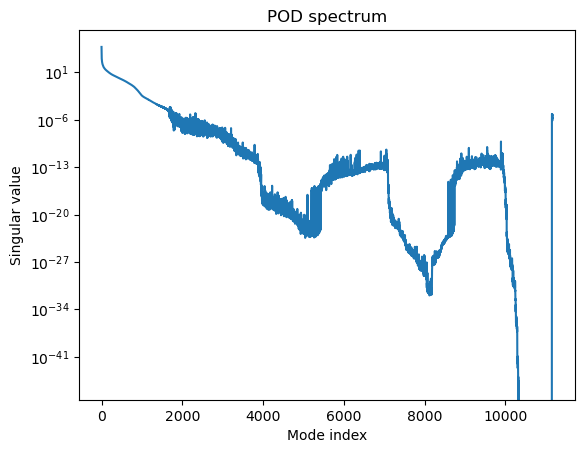

In [21]:
import matplotlib.pyplot as plt
plt.semilogy(s)
plt.xlabel("Mode index")
plt.ylabel("Singular value")
plt.title("POD spectrum")
plt.show()

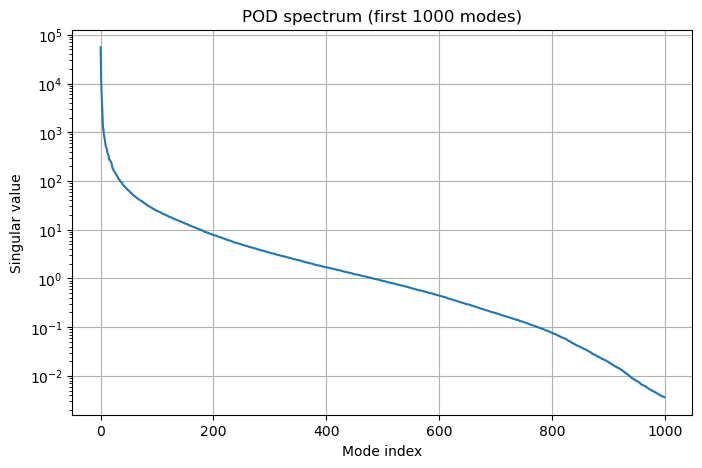

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import zarr

g = zarr.open_group(ZARR_PATH, mode="r")
s = g["pod_full"]["s"][:]

N = 1000   # change as you want

plt.figure(figsize=(8,5))
plt.semilogy(s[:N])
plt.title(f"POD spectrum (first {N} modes)")
plt.xlabel("Mode index")
plt.ylabel("Singular value")
plt.grid(True)
plt.show()

In [34]:
import numpy as np, zarr

ZARR_PATH = ZARR_PATH  # your path

g = zarr.open_group(ZARR_PATH, mode="r")
s = g["pod_full"]["s"][:]   # (M,)

# squared singular values = energy per mode
energy = s**2
total_energy = energy.sum()

def energy_fraction(r):
    """Fraction of total energy captured by first r modes."""
    return energy[:r].sum() / total_energy

R_KEEP = 30  # change this as needed
frac = energy_fraction(R_KEEP)

print(f"Energy captured by first {R_KEEP} modes: {frac:.6f} ({frac*100:.12f}%)")


Energy captured by first 30 modes: 0.999918 (99.991767883301%)


In [36]:
plot_field_on_mesh(err_field, coords, conn, ax=ax, cmap="coolwarm", vmin=-vmax, vmax=vmax)
import numpy as np
import zarr
import time
print(ZARR_PATH)
ZARR_PATH = ZARR_PATH  # keep your existing path variable

R_MODES = 50        # number of POD modes to keep
BATCH   = 2000      # number of snapshots per batch (tune if needed)

t0 = time.time()
g = zarr.open_group(ZARR_PATH, mode="a")

# --- load snapshot matrix and POD basis ---
X   = g["snapshots"]                       # (M, S)
U   = g["pod_full"]["U"]                  # (M, M or M, r_full)
mu  = g["pod_full"]["mean"][:]            # (M,)

M, S = X.shape
print(f"X shape: M={M}, S={S}")

# take first R_MODES modes
U_r = np.asarray(U[:, :R_MODES], dtype=np.float64)   # (M, R)
mu  = mu.astype(np.float64)                          # ensure float64
mu_col = mu.reshape(-1, 1)

# --- create Zarr group for latent codes ---
grp_name = f"latent_displ_r{R_MODES}"
if grp_name in g:
    del g[grp_name]
lg = g.require_group(grp_name)

# metadata so it's obvious what this is
lg.attrs.update({
    "field": "displacement",
    "r_modes": R_MODES,
    "basis_group": "pod_full",
    "basis_U_path": "/pod_full/U",
    "mean_path": "/pod_full/mean",
    "description": f"Latent coefficients for displacement using first {R_MODES} POD modes"
})

# create array for coefficients: shape (R, S)
coeffs_z = lg.create_array(
    "coeffs",
    shape=(R_MODES, S),
    chunks=(R_MODES, min(S, 4096)),   # chunk along snapshots
    dtype="f4",
)

print(f"Writing latent codes to group '{grp_name}/coeffs' ...")

# --- project snapshots in batches ---
for k in range(0, S, BATCH):
    l = min(S, k + BATCH)
    X_block = np.asarray(X[:, k:l], dtype=np.float64)   # (M, batch)
    Xc_block = X_block - mu_col                         # center

    # reduced coordinates: alpha = U_r^T Xc
    alpha_block = U_r.T @ Xc_block                      # (R, batch)

    coeffs_z[:, k:l] = alpha_block.astype(np.float32)
    print(f"  processed snapshots {l}/{S}")

print(f"Done. Total time: {time.time()-t0:.2f} s")
print(f"Latent codes stored in group '{grp_name}' with dataset 'coeffs' of shape {coeffs_z.shape}.")


displacements.zarr
X shape: M=11163, S=42237
Writing latent codes to group 'latent_displ_r50/coeffs' ...
  processed snapshots 2000/42237
  processed snapshots 4000/42237
  processed snapshots 6000/42237
  processed snapshots 8000/42237
  processed snapshots 10000/42237
  processed snapshots 12000/42237
  processed snapshots 14000/42237
  processed snapshots 16000/42237
  processed snapshots 18000/42237
  processed snapshots 20000/42237
  processed snapshots 22000/42237
  processed snapshots 24000/42237
  processed snapshots 26000/42237
  processed snapshots 28000/42237
  processed snapshots 30000/42237
  processed snapshots 32000/42237
  processed snapshots 34000/42237
  processed snapshots 36000/42237
  processed snapshots 38000/42237
  processed snapshots 40000/42237
  processed snapshots 42000/42237
  processed snapshots 42237/42237
Done. Total time: 19.91 s
Latent codes stored in group 'latent_displ_r50' with dataset 'coeffs' of shape (50, 42237).


### Project to other bases with a size of 5 to 50

In [14]:
##Repeated from above 
# CONFIG: edit these
ZARR_PATH  = "displacements.zarr"     # on-disk store for X, Phi, etc.
R_MODES    = 100                      # <-- number of POD modes to save (you can change later)
ROW_BLOCK  = 200_000                  # rows per streaming block; tune to your RAM
DTYPE_X    = "f4"                     # storage dtype for snapshots (float32 is plenty)

In [35]:
import numpy as np
import zarr
import time

# Assumes ZARR_PATH is already defined in your notebook
print("Using ZARR_PATH:", ZARR_PATH)

# CHANGED, STEP UP BY 1
R_MAX   = 10
R_LIST  = list(range(1, R_MAX, 1))   # [5, 10, 15, 20, 25, 30, 35, 40, 45]
BATCH   = 2000

t0 = time.time()
g = zarr.open_group(ZARR_PATH, mode="a")

# --- load snapshot matrix and POD basis ---
X   = g["snapshots"]                 # (M, S)
U   = g["pod_full"]["U"]            # (M, M or M, r_full)
mu  = g["pod_full"]["mean"][:]      # (M,) or (M,1)

M, S = X.shape
print(f"X shape: M={M}, S={S}")

# ensure mean is (M,1)
mu = np.asarray(mu, dtype=np.float64).reshape(-1, 1)

# take first R_MAX modes
U_rmax = np.asarray(U[:, :R_MAX], dtype=np.float64)   # (M, R_MAX)

# storage for all coefficients up to R_MAX
coeffs_full = np.empty((R_MAX, S), dtype=np.float32)

print(f"Computing latent coefficients up to r={R_MAX} ...")

# --- project snapshots in batches (single pass) ---
for k in range(0, S, BATCH):
    l = min(S, k + BATCH)
    X_block  = np.asarray(X[:, k:l], dtype=np.float64)   # (M, batch)
    Xc_block = X_block - mu                              # center

    # reduced coordinates: alpha = U_rmax^T Xc
    alpha_block = U_rmax.T @ Xc_block                    # (R_MAX, batch)
    coeffs_full[:, k:l] = alpha_block.astype(np.float32)

    print(f"  processed snapshots {l}/{S}")

# --- write separate latent groups for each r in R_LIST ---
for r in R_LIST:
    grp_name = f"latent_displ_r{r}"
    print(f"Writing coefficients for r={r} to group '{grp_name}' ...")

    # delete existing group if present
    if grp_name in g:
        del g[grp_name]
    lg = g.require_group(grp_name)

    # metadata so it's obvious what this is
    lg.attrs.update({
        "field": "displacement",
        "r_modes": r,
        "r_max_computed": R_MAX,
        "basis_group": "pod_full",
        "basis_U_path": "/pod_full/U",
        "mean_path": "/pod_full/mean",
        "description": f"Latent coefficients for displacement using first {r} POD modes"
    })

    # create array for coefficients: shape (r, S)
    coeffs_z = lg.create_array(
        "coeffs",
        shape=(r, S),
        chunks=(r, min(S, 4096)),   # chunk along snapshots
        dtype="f4",
    )

    coeffs_z[:, :] = coeffs_full[:r, :]

print(f"Done. Total time: {time.time() - t0:.2f} s")
print("Latent codes stored in groups:", [f"latent_displ_r{r}" for r in R_LIST])


Using ZARR_PATH: displacements.zarr
X shape: M=11163, S=42237
Computing latent coefficients up to r=10 ...
  processed snapshots 2000/42237
  processed snapshots 4000/42237
  processed snapshots 6000/42237
  processed snapshots 8000/42237
  processed snapshots 10000/42237
  processed snapshots 12000/42237
  processed snapshots 14000/42237
  processed snapshots 16000/42237
  processed snapshots 18000/42237
  processed snapshots 20000/42237
  processed snapshots 22000/42237
  processed snapshots 24000/42237
  processed snapshots 26000/42237
  processed snapshots 28000/42237
  processed snapshots 30000/42237
  processed snapshots 32000/42237
  processed snapshots 34000/42237
  processed snapshots 36000/42237
  processed snapshots 38000/42237
  processed snapshots 40000/42237
  processed snapshots 42000/42237
  processed snapshots 42237/42237
Writing coefficients for r=1 to group 'latent_displ_r1' ...
Writing coefficients for r=2 to group 'latent_displ_r2' ...
Writing coefficients for r=3 

In [17]:
import zarr
import numpy as np

# Open your displacement Zarr store
g = zarr.open("displacements.zarr", mode="r")

# Show tree so you can confirm what's inside
print("=== Zarr tree ===")
print(g.tree())

# Load the times dataset
times = np.asarray(g["times"])

print("\n=== times dataset info ===")
print("shape:", times.shape)
print("dtype:", times.dtype)
print("min:", np.min(times))
print("max:", np.max(times))

# If it's small, show all values
if times.size <= 200:
    print("\nvalues:", times)
else:
    print("\nfirst 10 values:", times[:70])
    print("last 10 values:", times[-10:])


=== Zarr tree ===


/
├── expander_volume
│   ├── cvol (42237,) float32
│   └── times (42237,) float32
├── latent_displ_r10
│   └── coeffs (10, 42237) float32
├── latent_displ_r15
│   └── coeffs (15, 42237) float32
├── latent_displ_r20
│   └── coeffs (20, 42237) float32
├── latent_displ_r25
│   └── coeffs (25, 42237) float32
├── latent_displ_r30
│   └── coeffs (30, 42237) float32
├── latent_displ_r35
│   └── coeffs (35, 42237) float32
├── latent_displ_r40
│   └── coeffs (40, 42237) float32
├── latent_displ_r45
│   └── coeffs (45, 42237) float32
├── latent_displ_r5
│   └── coeffs (5, 42237) float32
├── latent_displ_r50
│   └── coeffs (50, 42237) float32
├── latent_norm_151
│   ├── mean (151,) float32
│   └── std (151,) float32
├── latent_norm_stats
│   ├── mean (150,) float32
│   └── std (150,) float32
├── mapping
│   ├── frame_index (42237,) int32
│   ├── sim_index (42237,) int32
│   └── time_vals (42237,) float32
├── meta
│   └── node_labels (3721,) int64
├── param_norm
│   ├── mean (1, 8) float32
│   └── std (1, 8) float32
├── param_norm_stats
│   ├── mean (8,) float32
│   └── std (8,) float32
├── pod
│   ├── Phi (11163, 100) float32
│   ├── mean (11163,) float32
│   └── svals (100,) float32
├── pod_full
│   ├── U (11163, 11163) float32
│   ├── mean (11163,) float32
│   └── s (11163,) float32
├── snapshots (11163, 42237) float32
└── times (42237,) float32



=== times dataset info ===
shape: (42237,)
dtype: float32
min: 0.0
max: 98.0

first 10 values: [ 0.   1.4  2.8  4.2  5.6  7.   8.4  9.8 11.2 12.6 14.  15.4 16.8 18.2
 19.6 21.  22.4 23.8 25.2 26.6 28.  29.4 30.8 32.2 33.6 35.  36.4 37.8
 39.2 40.6 42.  43.4 44.8 46.2 47.6 49.  50.4 51.8 53.2 54.6 56.  57.4
 58.8 60.2 61.6 63.  64.4 65.8 67.2 68.6 70.  71.4 72.8 74.2 75.6 77.
 78.4 79.8 81.2 82.6 84.  85.4 86.8 88.2 89.6 91.  92.4 92.8 98.   0. ]
last 10 values: [71.4 72.8 74.2 75.6 77.  78.4 79.8 81.2 82.6 84. ]


=== ZARR TREE ===


/
├── expander_volume
│   ├── cvol (42237,) float32
│   └── times (42237,) float32
├── latent_displ_r10
│   └── coeffs (10, 42237) float32
├── latent_displ_r15
│   └── coeffs (15, 42237) float32
├── latent_displ_r20
│   └── coeffs (20, 42237) float32
├── latent_displ_r25
│   └── coeffs (25, 42237) float32
├── latent_displ_r30
│   └── coeffs (30, 42237) float32
├── latent_displ_r35
│   └── coeffs (35, 42237) float32
├── latent_displ_r40
│   └── coeffs (40, 42237) float32
├── latent_displ_r45
│   └── coeffs (45, 42237) float32
├── latent_displ_r5
│   └── coeffs (5, 42237) float32
├── latent_displ_r50
│   └── coeffs (50, 42237) float32
├── latent_norm_151
│   ├── mean (151,) float32
│   └── std (151,) float32
├── latent_norm_stats
│   ├── mean (150,) float32
│   └── std (150,) float32
├── mapping
│   ├── frame_index (42237,) int32
│   ├── sim_index (42237,) int32
│   └── time_vals (42237,) float32
├── meta
│   └── node_labels (3721,) int64
├── param_norm
│   ├── mean (1, 8) float32
│   └── std (1, 8) float32
├── param_norm_stats
│   ├── mean (8,) float32
│   └── std (8,) float32
├── pod
│   ├── Phi (11163, 100) float32
│   ├── mean (11163,) float32
│   └── svals (100,) float32
├── pod_full
│   ├── U (11163, 11163) float32
│   ├── mean (11163,) float32
│   └── s (11163,) float32
├── snapshots (11163, 42237) float32
└── times (42237,) float32



=== sim_index ===
shape: (42237,) dtype: int32
first 10: [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  2  2  2  2  2  2  2  2  2  2  2  2  2  2
  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2
  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4
  4  4  4  4  4  4  4  4  4  4  4  4  4  5  5  5  5  5  5  5  5  5  5  5
  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5
  5  5  5  5  5  5  6  6  6  6  6  6  6  6  6  6  6  6  6  6  6  

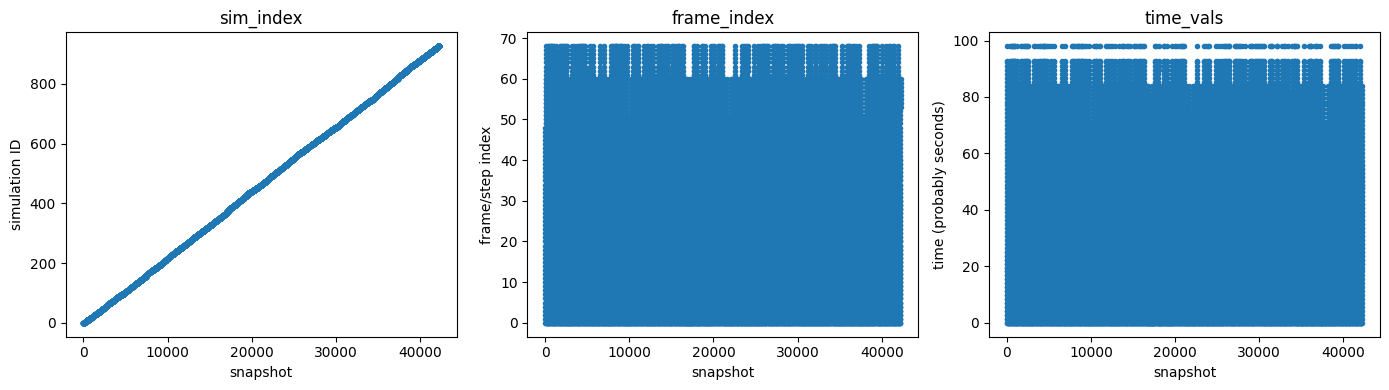

In [22]:
import zarr
import numpy as np
import matplotlib.pyplot as plt

# --- Open Zarr storage ---
g = zarr.open("displacements.zarr", mode="r")

print("=== ZARR TREE ===")
print(g.tree())

# --- Load mapping arrays ---
sim_index   = np.asarray(g["mapping/sim_index"])
frame_index = np.asarray(g["mapping/frame_index"])
time_vals   = np.asarray(g["mapping/time_vals"])

# --- Print basic info ---
print("\n=== sim_index ===")
print("shape:", sim_index.shape, "dtype:", sim_index.dtype)
print("first 10:", sim_index[:1000])
print("last 10:", sim_index[-10:])

print("\n=== frame_index ===")
print("shape:", frame_index.shape, "dtype:", frame_index.dtype)
print("first 10:", frame_index[:10])
print("last 10:", frame_index[-10:])

print("\n=== time_vals ===")
print("shape:", time_vals.shape, "dtype:", time_vals.dtype)
print("min:", np.min(time_vals), "max:", np.max(time_vals))
print("first 10:", time_vals[:200])
print("last 10:", time_vals[-10:])

# --- Optional visualization ---
plt.figure(figsize=(14,4))

plt.subplot(1, 3, 1)
plt.plot(sim_index, ".")
plt.title("sim_index")
plt.xlabel("snapshot")
plt.ylabel("simulation ID")

plt.subplot(1, 3, 2)
plt.plot(frame_index, ".")
plt.title("frame_index")
plt.xlabel("snapshot")
plt.ylabel("frame/step index")

plt.subplot(1, 3, 3)
plt.plot(time_vals, ".")
plt.title("time_vals")
plt.xlabel("snapshot")
plt.ylabel("time (probably seconds)")

plt.tight_layout()
plt.show()


In [30]:
# Frozen list of per-job CSV paths for which a converged FE run was found (some job
# numbers are skipped -- those jobs did not converge and were excluded from the
# dataset). The path root below is a placeholder: point it at your own copy of the
# raw FE-output folder (see data_processing/README.md).
converged_list = ['PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job1_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job2_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job3_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job4_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job5_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job6_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job7_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job8_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job9_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job10_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job11_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job12_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job13_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job14_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job16_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job17_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job18_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job19_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job20_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job21_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job22_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job23_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job24_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job25_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job26_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job27_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job28_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job29_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job30_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job31_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job32_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job33_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job34_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job36_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job37_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job38_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job39_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job41_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job42_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job43_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job44_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job45_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job46_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job47_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job48_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job49_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job50_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job51_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job52_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job53_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job54_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job55_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job57_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job58_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job59_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job60_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job61_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job63_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job64_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job65_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job66_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job67_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job68_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job69_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job70_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job71_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job72_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job73_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job74_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job76_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job77_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job78_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job79_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job80_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job81_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job82_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job83_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job84_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job85_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job86_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job87_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job91_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job92_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job94_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job95_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job96_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job97_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job98_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job99_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job100_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job101_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job102_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job103_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job104_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job105_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job106_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job107_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job108_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job109_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job110_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job111_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job113_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job114_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job115_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job116_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job117_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job118_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job119_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job120_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job121_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job122_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job123_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job124_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job125_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job126_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job127_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job128_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job129_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job130_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job131_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job132_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job133_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job134_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job135_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job136_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job137_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job138_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job139_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job140_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job141_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job142_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job143_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job144_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job145_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job146_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job147_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job148_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job149_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job150_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job151_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job152_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job153_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job154_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job155_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job156_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job157_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job158_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job159_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job160_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job161_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job162_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job163_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job164_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job165_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job166_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job167_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job168_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job169_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job170_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job171_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job172_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job174_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job175_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job176_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job177_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job178_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job179_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job181_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job182_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job183_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job184_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job185_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job186_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job188_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job189_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job190_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job191_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job192_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job193_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job194_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job195_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job196_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job197_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job198_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job199_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job200_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job201_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job202_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job203_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job205_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job206_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job207_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job208_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job209_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job210_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job211_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job212_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job213_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job214_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job215_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job216_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job217_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job218_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job219_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job220_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job222_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job224_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job225_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job226_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job227_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job228_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job229_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job230_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job231_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job232_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job233_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job234_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job235_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job236_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job237_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job238_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job239_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job241_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job243_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job244_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job245_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job246_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job247_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job248_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job249_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job250_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job251_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job252_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job253_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job254_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job256_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job257_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job258_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job259_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job260_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job261_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job263_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job264_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job265_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job266_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job267_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job268_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job269_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job270_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job271_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job272_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job273_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job274_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job275_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job276_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job277_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job278_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job279_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job281_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job282_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job283_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job284_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job285_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job286_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job287_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job288_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job289_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job290_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job291_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job292_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job293_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job294_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job295_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job296_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job297_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job298_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job299_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job300_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job301_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job302_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job303_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job305_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job306_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job308_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job309_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job310_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job311_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job313_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job314_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job315_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job316_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job317_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job318_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job319_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job320_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job322_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job323_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job324_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job325_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job326_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job327_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job328_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job329_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job330_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job331_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job332_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job334_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job335_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job336_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job337_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job338_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job339_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job340_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job341_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job342_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job343_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job344_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job345_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job346_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job347_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job348_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job349_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job350_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job351_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job352_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job353_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job354_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job355_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job356_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job357_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job358_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job360_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job361_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job362_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job363_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job364_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job365_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job366_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job367_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job368_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job369_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job370_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job371_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job372_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job373_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job374_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job376_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job377_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job378_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job379_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job380_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job381_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job382_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job383_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job384_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job385_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job386_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job387_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job388_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job390_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job391_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job392_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job393_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job394_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job395_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job396_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job398_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job399_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job400_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job401_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job402_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job403_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job404_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job405_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job406_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job407_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job408_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job409_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job410_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job411_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job412_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job414_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job415_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job416_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job417_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job418_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job419_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job420_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job421_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job422_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job424_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job425_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job426_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job427_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job428_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job429_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job431_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job433_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job434_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job435_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job436_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job438_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job439_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job440_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job441_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job442_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job443_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job444_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job445_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job447_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job448_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job449_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job450_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job451_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job452_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job453_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job454_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job455_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job456_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job457_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job458_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job459_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job460_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job461_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job463_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job464_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job465_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job466_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job467_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job468_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job469_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job470_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job471_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job472_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job473_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job474_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job475_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job476_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job477_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job478_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job479_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job480_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job481_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job482_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job483_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job485_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job486_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job487_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job488_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job489_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job490_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job491_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job492_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job493_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job494_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job495_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job496_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job497_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job498_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job499_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job500_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job501_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job502_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job503_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job504_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job505_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job506_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job507_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job508_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job509_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job511_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job512_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job513_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job514_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job515_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job516_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job517_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job518_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job519_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job520_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job521_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job522_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job523_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job524_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job525_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job526_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job527_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job528_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job529_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job530_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job531_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job532_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job533_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job534_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job535_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job536_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job537_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job538_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job539_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job540_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job541_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job542_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job543_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job544_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job545_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job546_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job547_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job548_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job549_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job550_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job551_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job552_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job553_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job554_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job555_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job556_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job557_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job558_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job559_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job560_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job561_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job562_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job563_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job565_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job566_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job567_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job568_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job569_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job570_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job571_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job572_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job573_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job574_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job575_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job576_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job577_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job578_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job579_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job580_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job581_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job582_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job583_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job584_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job587_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job588_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job589_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job590_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job591_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job592_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job593_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job594_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job595_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job596_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job597_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job598_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job599_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job600_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job601_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job602_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job603_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job604_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job605_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job606_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job608_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job609_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job610_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job611_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job612_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job613_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job614_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job615_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job616_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job617_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job618_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job619_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job620_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job621_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job622_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job623_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job624_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job625_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job626_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job627_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job628_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job629_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job630_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job631_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job632_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job633_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job634_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job635_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job636_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job637_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job638_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job639_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job640_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job641_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job642_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job643_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job644_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job645_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job646_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job647_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job649_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job650_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job651_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job652_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job653_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job654_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job655_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job656_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job657_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job658_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job659_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job660_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job662_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job663_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job664_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job665_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job666_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job667_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job668_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job669_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job670_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job671_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job672_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job673_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job674_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job675_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job676_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job677_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job678_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job679_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job680_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job682_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job683_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job684_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job685_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job686_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job687_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job688_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job689_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job690_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job691_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job692_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job693_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job694_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job695_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job696_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job697_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job698_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job699_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job700_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job701_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job702_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job703_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job706_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job707_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job708_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job709_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job710_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job711_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job712_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job713_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job714_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job715_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job717_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job718_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job721_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job722_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job723_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job724_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job725_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job726_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job728_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job729_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job730_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job731_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job732_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job733_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job734_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job735_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job736_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job737_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job738_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job739_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job740_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job741_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job742_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job743_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job744_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job745_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job746_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job747_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job748_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job750_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job751_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job752_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job753_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job754_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job755_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job756_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job757_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job758_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job759_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job760_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job761_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job762_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job763_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job764_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job765_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job766_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job767_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job768_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job769_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job770_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job771_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job772_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job773_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job774_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job775_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job776_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job777_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job778_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job779_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job781_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job783_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job785_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job786_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job787_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job788_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job789_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job791_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job792_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job793_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job794_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job795_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job796_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job797_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job798_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job799_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job800_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job801_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job802_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job803_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job804_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job805_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job806_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job807_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job808_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job809_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job810_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job812_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job813_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job814_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job815_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job816_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job817_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job818_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job819_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job821_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job822_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job823_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job824_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job825_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job826_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job828_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job829_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job830_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job831_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job832_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job833_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job834_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job835_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job836_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job838_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job839_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job840_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job841_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job842_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job843_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job844_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job845_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job846_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job847_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job848_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job849_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job850_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job851_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job853_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job854_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job855_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job856_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job857_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job858_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job859_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job860_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job861_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job862_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job863_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job864_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job865_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job866_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job867_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job868_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job869_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job870_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job871_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job872_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job873_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job874_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job875_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job876_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job877_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job878_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job879_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job880_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job881_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job882_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job883_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job884_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job885_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job886_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job887_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job888_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job889_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job890_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job891_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job892_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job893_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job894_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job895_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job896_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job897_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job899_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job900_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job901_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job902_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job903_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job904_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job905_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job906_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job907_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job908_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job909_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job910_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job911_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job912_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job914_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job915_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job916_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job917_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job918_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job920_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job921_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job923_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job925_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job926_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job927_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job928_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job929_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job930_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job931_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job932_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job933_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job934_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job935_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job936_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job937_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job938_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job940_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job941_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job942_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job943_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job944_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job945_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job946_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job947_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job948_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job949_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job951_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job952_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job953_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job954_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job955_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job956_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job957_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job958_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job959_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job960_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job961_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job962_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job963_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job964_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job965_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job966_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job967_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job968_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job969_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job970_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job971_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job972_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job973_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job974_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job976_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job977_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job978_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job979_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job980_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job981_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job982_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job983_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job984_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job985_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job986_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job987_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job988_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job989_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job990_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job991_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job992_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job993_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job994_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job995_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job997_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job998_combined_data.csv', 'PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job1000_combined_data.csv']

In [31]:
import numpy as np
import zarr
import re
import os

# --------------------------
# 1. Load design file
# --------------------------
design_path = "PGOH_Ideal_tol_Tcrit_V_mu_kk1_kk2_kappa_k1_design.txt"

# Each row = one job, 4th column = final volume
# Shape should be (1000, n_cols)
design = np.loadtxt(design_path)
final_volume_by_job = design[:, 3]   # shape (1000,)

print("Design file loaded:")
print("  shape:", design.shape)
print("  example final volumes:", final_volume_by_job[:5])

# --------------------------
# 2. Parse converged_list -> job index per sim
# --------------------------
# converged_list is a Python list of full paths like:
# ["PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\\GOH_Job961_combined_data.csv", ...]
# sim_index = 0 corresponds to converged_list[0], etc.

pattern = re.compile(r"Job(\d+)", re.IGNORECASE)
n_sims = len(converged_list)
job_index_per_sim = np.empty(n_sims, dtype=np.int32)  # job numbers are 1-based

for i, path in enumerate(converged_list):
    fname = os.path.basename(path)      # "GOH_Job961_combined_data.csv"
    m = pattern.search(fname)
    if not m:
        raise ValueError(f"Could not parse job number from filename: {fname}")
    job_idx = int(m.group(1))          # 1-based job number
    job_index_per_sim[i] = job_idx

print("\nParsed job indices for converged sims:")
print("  n_sims:", n_sims)
print("  first 10 job indices:", job_index_per_sim[:10])

# --------------------------
# 3. Map sim -> final volume
# --------------------------
# final_volume_by_job is 0-based (row 0 = Job1, etc.), job_index_per_sim is 1-based
final_volume_per_sim = final_volume_by_job[job_index_per_sim - 1]  # shape (n_sims,)

print("\nExample mapping sim -> job -> final volume:")
for i in range(min(5, n_sims)):
    print(f"  sim {i}: job {job_index_per_sim[i]}, V_final = {final_volume_per_sim[i]:.2f}")

# --------------------------
# 4. Map snapshots -> job index & final volume
# --------------------------
g = zarr.open_group("displacements.zarr", mode="a")

sim_index = np.asarray(g["mapping/sim_index"])  # shape (N_snap,)
N_snap = sim_index.shape[0]

print("\nSnapshot mapping:")
print("  N_snap =", N_snap)
print("  sim_index min/max:", sim_index.min(), sim_index.max())

# For each snapshot k: sim = sim_index[k], then job = job_index_per_sim[sim]
job_index_per_snapshot = job_index_per_sim[sim_index]       # shape (N_snap,)
final_volume_per_snapshot = final_volume_per_sim[sim_index] # shape (N_snap,)

print("\nSanity check for first 10 snapshots:")
for k in range(min(10, N_snap)):
    s = sim_index[k]
    print(f"  snap {k}: sim {s}, job {job_index_per_snapshot[k]}, "
          f"V_final = {final_volume_per_snapshot[k]:.2f}")

# --------------------------
# 5. Store results in Zarr
# --------------------------
mgrp = g.require_group("mapping")

# Per-sim arrays
if "job_index_per_sim" in mgrp:
    del mgrp["job_index_per_sim"]
mgrp.create_array(
    "job_index_per_sim",
    data=job_index_per_sim,   # dtype inferred
)

if "final_volume_per_sim" in mgrp:
    del mgrp["final_volume_per_sim"]
mgrp.create_array(
    "final_volume_per_sim",
    data=final_volume_per_sim,  # dtype inferred
)

# Per-snapshot arrays
if "job_index_per_snapshot" in mgrp:
    del mgrp["job_index_per_snapshot"]
mgrp.create_array(
    "job_index_per_snapshot",
    data=job_index_per_snapshot,
    chunks=(min(N_snap, 1_000_000),),
)

if "final_volume_per_snapshot" in mgrp:
    del mgrp["final_volume_per_snapshot"]
mgrp.create_array(
    "final_volume_per_snapshot",
    data=final_volume_per_snapshot,
    chunks=(min(N_snap, 1_000_000),),
)

print("\nSaved to displacements.zarr/mapping:")
print("  - job_index_per_sim          (shape:", job_index_per_sim.shape, ")")
print("  - final_volume_per_sim       (shape:", final_volume_per_sim.shape, ")")
print("  - job_index_per_snapshot     (shape:", job_index_per_snapshot.shape, ")")
print("  - final_volume_per_snapshot  (shape:", final_volume_per_snapshot.shape, ")")


Design file loaded:
  shape: (1000, 9)
  example final volumes: [695735.362 580848.556 535445.172 236359.061 266870.122]

Parsed job indices for converged sims:
  n_sims: 927
  first 10 job indices: [ 1  2  3  4  5  6  7  8  9 10]

Example mapping sim -> job -> final volume:
  sim 0: job 1, V_final = 695735.36
  sim 1: job 2, V_final = 580848.56
  sim 2: job 3, V_final = 535445.17
  sim 3: job 4, V_final = 236359.06
  sim 4: job 5, V_final = 266870.12

Snapshot mapping:
  N_snap = 42237
  sim_index min/max: 0 926

Sanity check for first 10 snapshots:
  snap 0: sim 0, job 1, V_final = 695735.36
  snap 1: sim 0, job 1, V_final = 695735.36
  snap 2: sim 0, job 1, V_final = 695735.36
  snap 3: sim 0, job 1, V_final = 695735.36
  snap 4: sim 0, job 1, V_final = 695735.36
  snap 5: sim 0, job 1, V_final = 695735.36
  snap 6: sim 0, job 1, V_final = 695735.36
  snap 7: sim 0, job 1, V_final = 695735.36
  snap 8: sim 0, job 1, V_final = 695735.36
  snap 9: sim 0, job 1, V_final = 695735.36

Sa

In [32]:
import numpy as np
import zarr

ZARR_PATH = "displacements.zarr"
base_step = 100000.0   # increment in volume setpoint
block_days = 14.0      # duration of each setpoint stage in days
eps = 1e-9

g = zarr.open_group(ZARR_PATH, mode="a")
mgrp = g["mapping"]

# Load required mapping arrays
sim_index = np.asarray(mgrp["sim_index"])              # (N_snap,)
time_vals = np.asarray(mgrp["time_vals"])              # (N_snap,)
final_volume_per_sim = np.asarray(mgrp["final_volume_per_sim"])  # (n_sims,)

N_snap = sim_index.shape[0]
n_sims = final_volume_per_sim.shape[0]

print(f"N_snap = {N_snap}, n_sims = {n_sims}")
print("sim_index range:", sim_index.min(), "to", sim_index.max())

# Allocate output: setpoint per snapshot
volume_setpoint_per_snapshot = np.empty(N_snap, dtype=np.float64)

for j in range(n_sims):
    # Mask of snapshots belonging to sim j
    mask = (sim_index == j)
    if not np.any(mask):
        continue

    t_j = time_vals[mask]             # times for this sim's snapshots
    V_f = float(final_volume_per_sim[j])

    # --- Build setpoint ladder for sim j ---
    n_full = int(V_f // base_step)    # number of full 100k steps
    sp_levels = [base_step * i for i in range(1, n_full + 1)]

    if len(sp_levels) == 0:
        # Edge case: final volume < 100k -> just one setpoint = V_f
        sp_levels = [V_f]
    else:
        # If final volume is not exactly a multiple of 100k, append V_f
        if abs(V_f - sp_levels[-1]) > 1e-6:
            sp_levels.append(V_f)

    sp_levels = np.array(sp_levels, dtype=np.float64)
    L = sp_levels.shape[0]

    # --- Map times to setpoint phases ---
    phase = ((t_j - eps) // block_days).astype(int)  # 0-based index
    phase = np.clip(phase, 0, L - 1)                 # clamp to valid range

    volume_setpoint_per_snapshot[mask] = sp_levels[phase]

    # Optional: quick sanity print for first few sims
    if j < 3:
        print(f"\nSim {j}: V_final = {V_f:.2f}")
        print(f"  sp_levels: {sp_levels}")
        print(f"  first 5 times: {t_j[:5]}")
        print(f"  first 5 SPs:   {volume_setpoint_per_snapshot[mask][:5]}")

# --- Store in Zarr ---
if "volume_setpoint_per_snapshot" in mgrp:
    del mgrp["volume_setpoint_per_snapshot"]

mgrp.create_array(
    "volume_setpoint_per_snapshot",
    data=volume_setpoint_per_snapshot,
    chunks=(min(N_snap, 1_000_000),),
)

print("\nSaved 'mapping/volume_setpoint_per_snapshot' with shape:",
      volume_setpoint_per_snapshot.shape)
print("Example entries:", volume_setpoint_per_snapshot[:10])


N_snap = 42237, n_sims = 927
sim_index range: 0 to 926

Sim 0: V_final = 695735.36
  sp_levels: [100000.    200000.    300000.    400000.    500000.    600000.
 695735.362]
  first 5 times: [0.  1.4 2.8 4.2 5.6]
  first 5 SPs:   [100000. 100000. 100000. 100000. 100000.]

Sim 1: V_final = 580848.56
  sp_levels: [100000.    200000.    300000.    400000.    500000.    580848.556]
  first 5 times: [0.  1.4 2.8 4.2 5.6]
  first 5 SPs:   [100000. 100000. 100000. 100000. 100000.]

Sim 2: V_final = 535445.17
  sp_levels: [100000.    200000.    300000.    400000.    500000.    535445.172]
  first 5 times: [0.  1.4 2.8 4.2 5.6]
  first 5 SPs:   [100000. 100000. 100000. 100000. 100000.]

Saved 'mapping/volume_setpoint_per_snapshot' with shape: (42237,)
Example entries: [100000. 100000. 100000. 100000. 100000. 100000. 100000. 100000. 100000.
 100000.]


In [34]:
import numpy as np
import zarr
import os

# --------------------------
# Paths
# --------------------------
DESIGN_PATH = "PGOH_Ideal_tol_Tcrit_V_mu_kk1_kk2_kappa_k1_design.txt"
DISP_ZARR_PATH = "displacements.zarr"
OUT_ZARR_PATH  = "Sim_design_params_7_dims.zarr"  # new zarr store

# --------------------------
# 1. Load design file
# --------------------------
# Each of 1000 rows = one job; we want columns 2,3,5,6,7,8,9
#   -> 0-based indices: 1,2,4,5,6,7,8
design = np.loadtxt(DESIGN_PATH)
print("Design file loaded:")
print("  shape:", design.shape)

cols_idx = np.array([1, 2, 4, 5, 6, 7, 8], dtype=int)
design_params = design[:, cols_idx]   # shape (1000, 7)

print("Selected param columns shape:", design_params.shape)
print("Example design params (jobs 1–3):")
for j in range(3):
    print(f"  Job {j+1}: {design_params[j, :]}")

# --------------------------
# 2. Load mapping (per snapshot)
# --------------------------
g = zarr.open_group(DISP_ZARR_PATH, mode="r")
mgrp = g["mapping"]

sim_index = np.asarray(mgrp["sim_index"])                   # (N_snap,)
job_index_per_snapshot = np.asarray(mgrp["job_index_per_snapshot"])  # (N_snap,)

N_snap = sim_index.shape[0]
print("\nMapping info:")
print("  N_snap:", N_snap)
print("  sim_index range:", sim_index.min(), "to", sim_index.max())
print("  job_index_per_snapshot range:", job_index_per_snapshot.min(),
      "to", job_index_per_snapshot.max())

# --------------------------
# 3. Build per-snapshot design param array
# --------------------------
# job_index_per_snapshot is 1-based; design rows are 0-based (0->Job1)
job_rows = job_index_per_snapshot - 1    # shape (N_snap,)
snapshot_params = design_params[job_rows, :]  # shape (N_snap, 7)

print("\nSnapshot params array shape:", snapshot_params.shape)

print("\nSanity check for first 5 snapshots:")
for k in range(5):
    sim = sim_index[k]
    job = job_index_per_snapshot[k]
    print(f"  snap {k}: sim {sim}, job {job}, params = {snapshot_params[k, :]}")

# --------------------------
# 4. Save to new Zarr store
# --------------------------
if os.path.exists(OUT_ZARR_PATH):
    print(f"\nWARNING: {OUT_ZARR_PATH} already exists; it will be overwritten.")
    # You can delete it if you want a clean store
    # import shutil; shutil.rmtree(OUT_ZARR_PATH)

root_out = zarr.open_group(OUT_ZARR_PATH, mode="w")

# Create main array: shape (N_snap, 7)
params_arr = root_out.create_array(
    "design_params_per_snapshot",
    data=snapshot_params,
    chunks=(min(N_snap, 1_000_000), 7),
)

# Optional: store some metadata
root_out.attrs.update({
    "description": "Design parameters (7 dims) per snapshot, mapped via job_index_per_snapshot.",
    "source_design_file": DESIGN_PATH,
    "columns_original_1_based": [2, 3, 5, 6, 7, 8, 9],
    "columns_zero_based": cols_idx.tolist(),
})

print("\nSaved new Zarr store at:", OUT_ZARR_PATH)
print("  dataset: 'design_params_per_snapshot' with shape", params_arr.shape)

print("\nRandom sample check (snapshots 100–104):")
for k in range(1000, min(1005, N_snap)):
    print(f"  snap {k}: job {job_index_per_snapshot[k]}, params = {snapshot_params[k, :]}")


Design file loaded:
  shape: (1000, 9)
Selected param columns shape: (1000, 7)
Example design params (jobs 1–3):
  Job 1: [18.688  1.048  0.214  1.86   1.019  0.318  4.468]
  Job 2: [25.772  1.105  0.148  2.282  0.573  0.036  5.943]
  Job 3: [20.185  1.047  0.132  1.547  0.5    0.222  7.743]

Mapping info:
  N_snap: 42237
  sim_index range: 0 to 926
  job_index_per_snapshot range: 1 to 1000

Snapshot params array shape: (42237, 7)

Sanity check for first 5 snapshots:
  snap 0: sim 0, job 1, params = [18.688  1.048  0.214  1.86   1.019  0.318  4.468]
  snap 1: sim 0, job 1, params = [18.688  1.048  0.214  1.86   1.019  0.318  4.468]
  snap 2: sim 0, job 1, params = [18.688  1.048  0.214  1.86   1.019  0.318  4.468]
  snap 3: sim 0, job 1, params = [18.688  1.048  0.214  1.86   1.019  0.318  4.468]
  snap 4: sim 0, job 1, params = [18.688  1.048  0.214  1.86   1.019  0.318  4.468]


Saved new Zarr store at: Sim_design_params_7_dims.zarr
  dataset: 'design_params_per_snapshot' with shape 

### Visualize Snapshots

In [11]:
import numpy as np, zarr

g = zarr.open_group(ZARR_PATH, mode="r")

X = np.asarray(g["snapshots"])       # (3N, S)
times = np.asarray(g["times"])       # (S,)
node_labels = np.asarray(g["meta"]["node_labels"])  # (N,)

# Load coordinates from your CSV
coords = np.loadtxt(NODES_CSV_PATH, delimiter=",")  # id, x, y, z
id_map = {int(row[0]): i for i, row in enumerate(coords)}

# Build coordinate array in correct node_labels order
xyz = np.array([coords[id_map[n]][1:] for n in node_labels])   # (N, 3)


NameError: name 'NODES_CSV_PATH' is not defined

In [58]:
def snapshot_to_displacements(Xcol):
    N = len(node_labels)
    Ux = Xcol[0:N]
    Uy = Xcol[N:2*N]
    Uz = Xcol[2*N:3*N]
    return Ux, Uy, Uz


In [59]:
import matplotlib.pyplot as plt

def plot_snapshot(j):
    Ux, Uy, Uz = snapshot_to_displacements(X[:, j])

    plt.figure(figsize=(10,3))
    plt.subplot(1,3,1)
    plt.scatter(xyz[:,0], xyz[:,1], c=Ux, s=3)
    plt.colorbar(); plt.title(f"Ux (snap {j})")

    plt.subplot(1,3,2)
    plt.scatter(xyz[:,0], xyz[:,1], c=Uy, s=3)
    plt.colorbar(); plt.title(f"Uy (snap {j})")

    plt.subplot(1,3,3)
    plt.scatter(xyz[:,0], xyz[:,1], c=Uz, s=3)
    plt.colorbar(); plt.title(f"Uz (snap {j})")

    plt.tight_layout()
    plt.show()


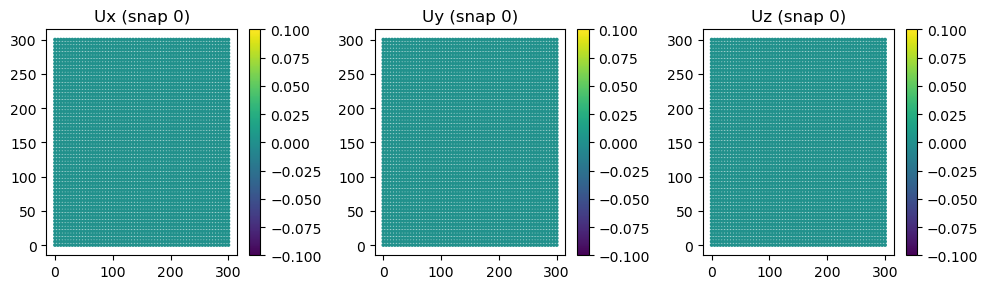

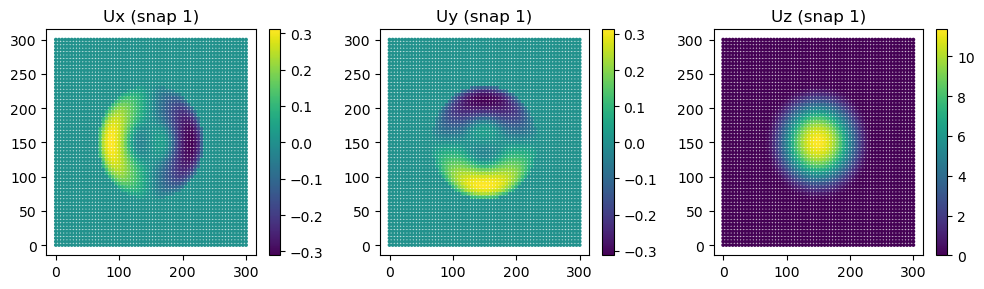

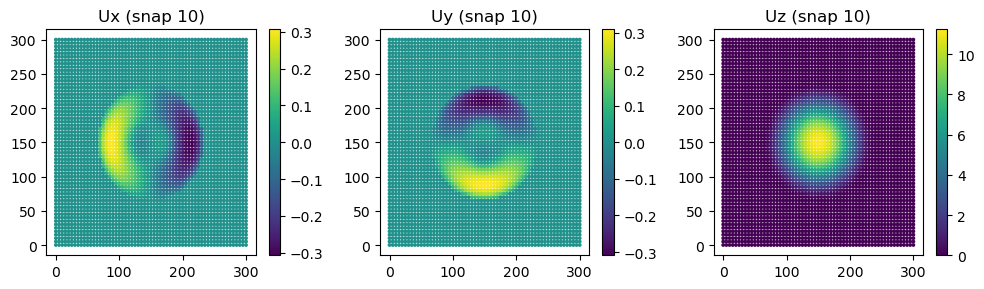

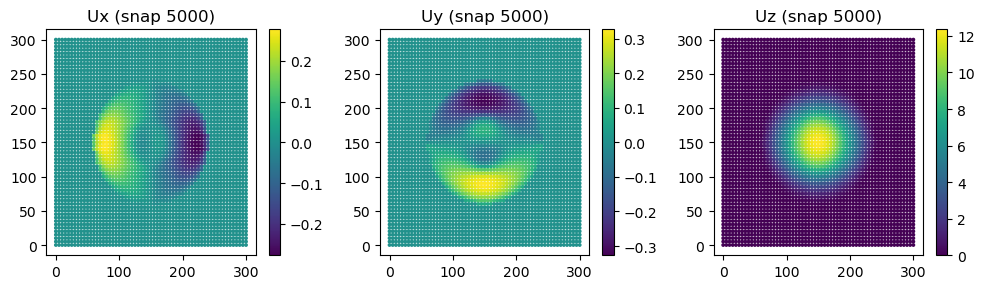

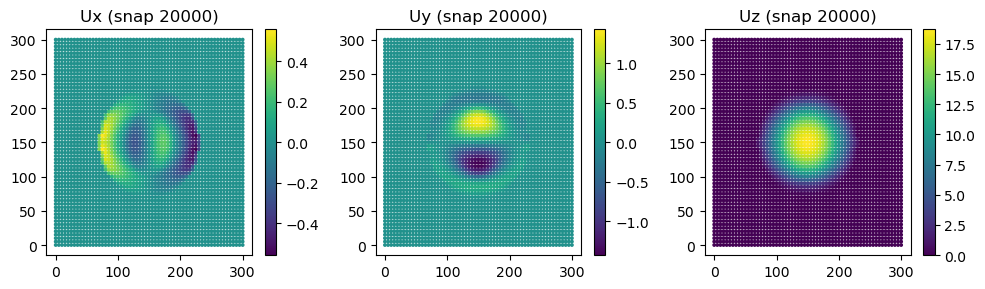

In [60]:
plot_snapshot(0)
plot_snapshot(1)
plot_snapshot(10)
plot_snapshot(5000)
plot_snapshot(20000)


In [67]:
import jax.numpy as jnp
print("JAX float64 enabled?", jnp.ones(1).dtype)

JAX float64 enabled? float64


In [70]:
import numpy as np, zarr

g = zarr.open_group(ZARR_PATH, mode="r")
X = g["snapshots"]
M, S = X.shape

# pick a small subset
rows = slice(0, 500)

# extract mini-matrix (200×S)
Xmini = np.asarray(X[0:500, :], dtype=np.float64)

# compute mean
mu = Xmini.mean(axis=1, keepdims=True)

# center
Xc = Xmini - mu

# compute covariance block
Ctest = Xc @ Xc.T   # 200×200

print("Ctest finite?", np.isfinite(Ctest).all())
print("min(Ctest), max(Ctest):", Ctest.min(), Ctest.max())


Ctest finite? True
min(Ctest), max(Ctest): 0.0 0.0


In [61]:
def compare_snapshots(indices):
    n = len(indices)
    plt.figure(figsize=(5*n, 4))

    for k, j in enumerate(indices):
        Ux, Uy, Uz = snapshot_to_displacements(X[:, j])
        ax = plt.subplot(1, n, k+1)
        plt.scatter(xyz[:,0], xyz[:,1], c=Uz, s=3)
        plt.title(f"Uz snap {j}")
        plt.colorbar()
    plt.show()


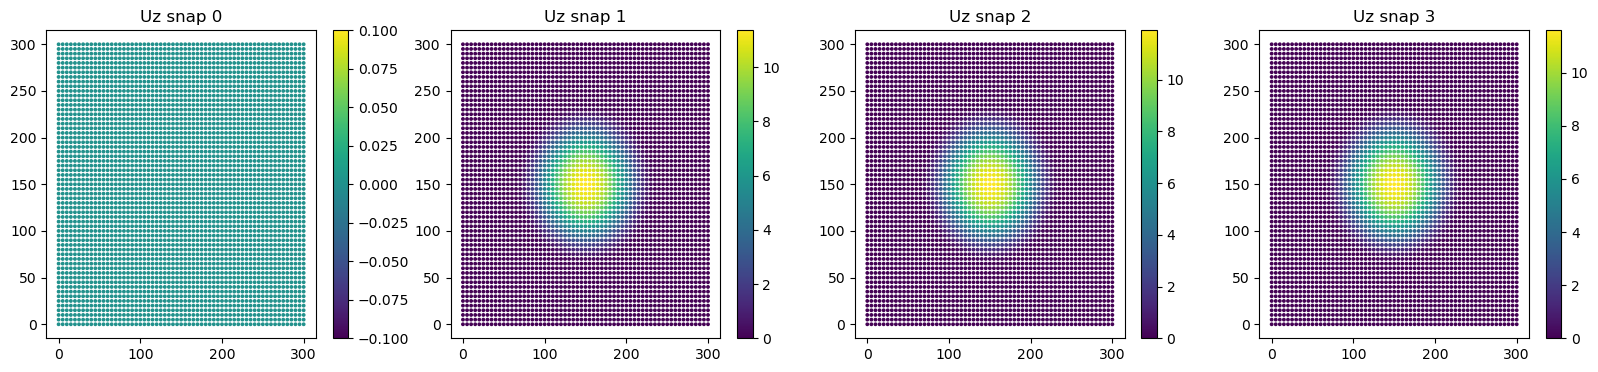

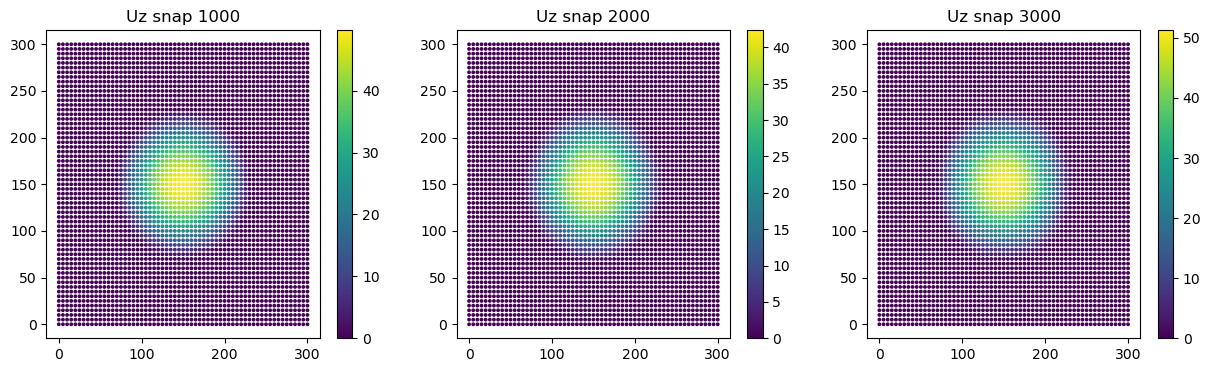

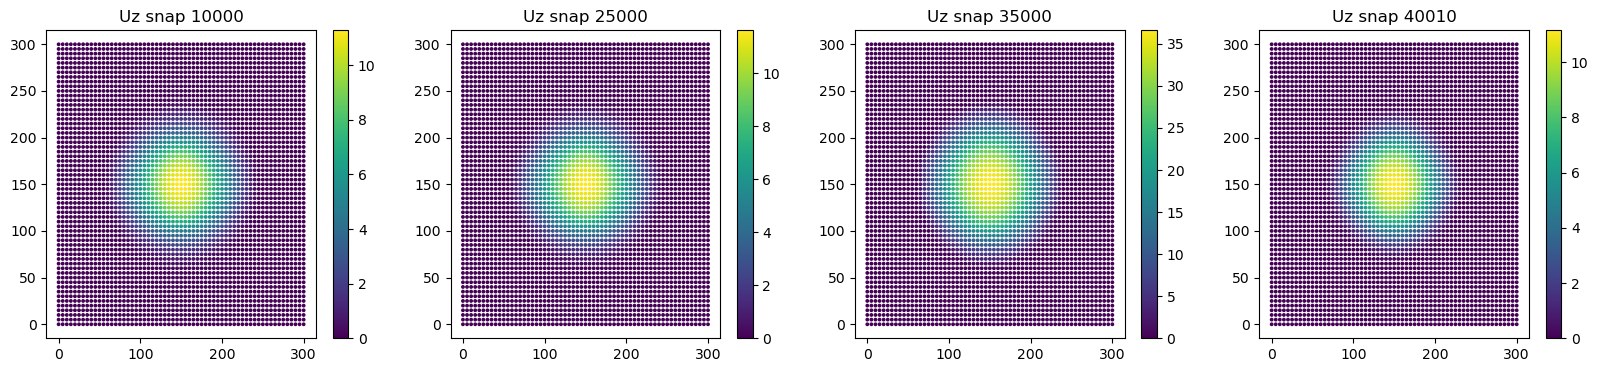

In [65]:
compare_snapshots([0, 1, 2, 3])
compare_snapshots([1000, 2000, 3000])
compare_snapshots([10000, 25000, 35000, 40010])


In [66]:
# For several random snapshot cols:
for j in np.random.choice(X.shape[1], size=5, replace=False):
    Ux,Uy,Uz = snapshot_to_displacements(X[:,j])
    print("Snapshot", j, "mean Ux:", np.mean(Ux), "range:", (Ux.min(), Ux.max()))


Snapshot 5610 mean Ux: 0.0 range: (np.float32(-0.81338906), np.float32(0.81338906))
Snapshot 3096 mean Ux: 0.0 range: (np.float32(-0.559586), np.float32(0.559586))
Snapshot 37451 mean Ux: 0.0 range: (np.float32(0.0), np.float32(0.0))
Snapshot 3161 mean Ux: 0.0 range: (np.float32(-1.4233496), np.float32(1.4233496))
Snapshot 367 mean Ux: 0.0 range: (np.float32(-5.030862), np.float32(5.030862))


In [ ]:
import numpy as np, zarr, time

g = zarr.open_group(ZARR_PATH, "r")
X = np.asarray(g["snapshots"], dtype=np.float64)  # (M, S)
M, S = X.shape

# Take a smaller test problem
m_test = 2000      # subset of rows
s_test = 5000      # subset of columns

X_test = X[:m_test, :s_test]
Xc_test = X_test - X_test.mean(axis=1, keepdims=True)

t0 = time.time()
U_t, s_t, VT_t = np.linalg.svd(Xc_test, full_matrices=False)
t_test = time.time() - t0

print(f"Test SVD ({m_test}x{s_test}) took {t_test:.2f} s")


Total modes saved: 11163
Modes for 95% energy: 1
Modes for 99% energy: 3


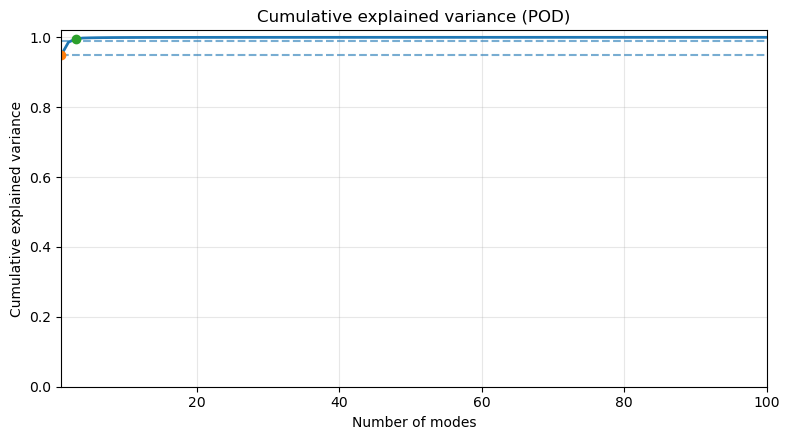

In [19]:
import numpy as np, zarr, matplotlib.pyplot as plt

# Load singular values saved by your POD step
g = zarr.open_group(ZARR_PATH, mode="r")
svals = g["pod_full"]["s"][:]             # shape (r_saved,)
r_saved = len(svals)

# Use the user's choice if defined; otherwise use all saved
try:
    r_plot = int(min(R_MODES, r_saved))
except NameError:
    r_plot = r_saved

# Explained variance from singular values (energy ~ s^2)
energy = svals**2
energy_total = energy.sum()
var_ratio = energy / energy_total
cum_var = np.cumsum(var_ratio)

# The paper retains r=9 displacement POD modes, chosen because they already capture
# ~99.99% of cumulative snapshot energy (see data_processing/README.md and Methods
# Sec. 2). This cell only reports the 95%/99% energy thresholds as a sanity check;
# the actual r=9 truncation is applied by downstream training/eval scripts that
# slice pod_full/U to its first 9 columns.

# Report thresholds
def modes_for(thresh):
    idx = np.searchsorted(cum_var, thresh) + 1
    return int(min(idx, r_saved))

r95 = modes_for(0.95)
r99 = modes_for(0.99)
print(f"Total modes saved: {r_saved}")
print(f"Modes for 95% energy: {r95}")
print(f"Modes for 99% energy: {r99}")

# Plot cumulative explained variance
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.arange(1, r_plot+1), cum_var[:r_plot], lw=2)
ax.axhline(0.95, ls="--", alpha=0.6)
ax.axhline(0.99, ls="--", alpha=0.6)
ax.set_xlim(1, r_plot)
ax.set_ylim(0, 1.02)
ax.set_xlabel("Number of modes")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("Cumulative explained variance (POD)")
ax.grid(True, alpha=0.3)

# Optional: mark the 95% and 99% points if within r_plot
if r95 <= r_plot: ax.plot(r95, cum_var[r95-1], "o")
if r99 <= r_plot: ax.plot(r99, cum_var[r99-1], "o")
fig.savefig("u_cumulative_var.png",transparent=True, dpi=300)
plt.tight_layout()
plt.show()


In [20]:
print(cum_var[-1])

nan


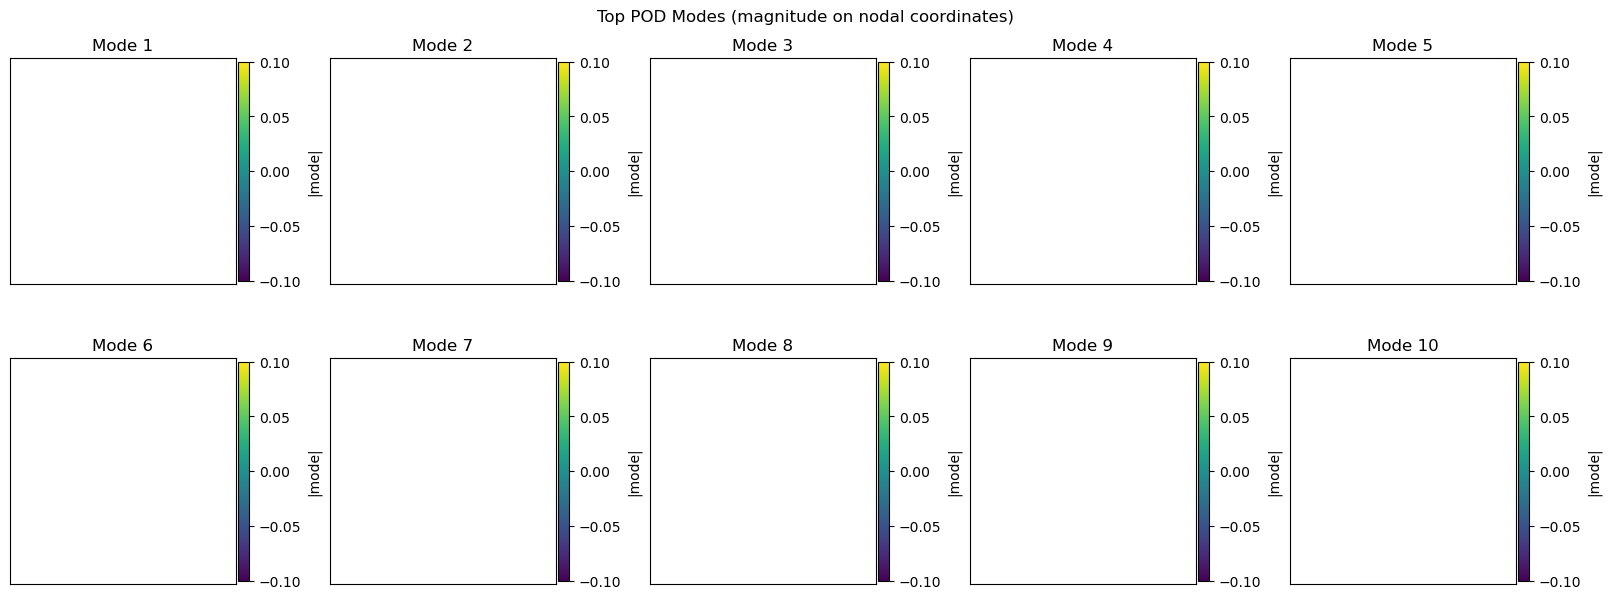

N nodes in snapshots: 3721
Unique coord rows:    3721 (duplicates removed: 0)
labels min..max:      7443..11163  (strict mapping by id)


In [21]:
import numpy as np, zarr, matplotlib.pyplot as plt

# --- paths ---
ZARR_PATH = ZARR_PATH
NODES_CSV_PATH = r"GOH_Nodes_Test_for_Visualization.csv"

# --- load POD + meta ---
g = zarr.open_group(store=ZARR_PATH, mode="r")
Phi   = g["pod"]["Phi"]                  # (3N, r)
svals = g["pod"]["svals"][:]             # (r,)
labels = g["meta"]["node_labels"][:]     # (N,)
N = len(labels)
M, r_saved = Phi.shape
assert M == 3*N, f"Phi has {M} rows; expected 3N={3*N}"

# --- load all node coordinates (id, x, y, z) ---
coords_all = np.genfromtxt(NODES_CSV_PATH, delimiter=",", dtype=float)
ids_all = coords_all[:,0].astype(int)
xyz_all = coords_all[:,1:4]

# --- build an exact id->row map (robust, no searchsorted assumptions) ---
id_to_idx = {nid: i for i, nid in enumerate(ids_all)}
missing = [nid for nid in labels if nid not in id_to_idx]
if missing:
    raise ValueError(f"{len(missing)} node IDs from snapshots not found in coord file, e.g. {missing[:10]}")

# coords in EXACT snapshot order
xyz = np.vstack([xyz_all[id_to_idx[nid]] for nid in labels])   # (N,3)
x, y, z = xyz.T

# --- sanity checks: duplicates & one-to-one mapping ---
# 1) labels are unique and same size as coords
assert len(np.unique(labels)) == N, "Duplicate node labels in snapshots!"
# 2) coordinate rows are unique (no repeated points that could 'tile' patterns)
uniq_rows, uniq_count = np.unique(xyz, axis=0, return_counts=True)
if np.any(uniq_count > 1):
    dup_ct = int((uniq_count > 1).sum())
    print(f"WARNING: {dup_ct} duplicated coordinate locations found in xyz "
          f"(this can visually 'tile' patterns). Showing a unique-only plot below.")
    # mask to unique rows only (keep first occurrence)
    keep_mask = np.ones(N, dtype=bool)
    seen = set()
    for i, row in enumerate(map(tuple, xyz)):
        if row in seen:
            keep_mask[i] = False
        else:
            seen.add(row)
else:
    keep_mask = slice(None)

# --- helper: split components from [U1(all), U2(all), U3(all)] ---
def split_components(vec_3N, N):
    return np.column_stack((vec_3N[0:N], vec_3N[N:2*N], vec_3N[2*N:3*N]))  # (N,3)

# --- how many modes to plot ---
N_MODES_TO_PLOT = 10  # or 30, or however many you want
n_plot = min(N_MODES_TO_PLOT, r_saved)
phi_mem = np.asarray(Phi[:, :n_plot])  # (3N, n_plot)

fig, axes = plt.subplots(2, 5, figsize=(16, 6), constrained_layout=True)
axes = axes.ravel()

for i in range(n_plot):
    ax = axes[i]
    mode = split_components(phi_mem[:, i], N)  # (N,3)
    mag = np.linalg.norm(mode, axis=1)

    # normalize per-mode for color
    #vmax = mag.max() if mag.size else 1.0
    #c = mag / (vmax + 1e-12)
    c = mag
    sc = ax.scatter(x[keep_mask], y[keep_mask], c=c[keep_mask], s=6, cmap="viridis")
    ax.set_title(f"Mode {i+1}")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([]); ax.set_yticks([])
    cb = plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.01)
    cb.set_label("|mode|")

for j in range(n_plot, len(axes)):
    axes[j].axis("off")
fig.savefig("Displacement_modes.png",transparent=True,dpi=300)
fig.suptitle("Top POD Modes (magnitude on nodal coordinates)", y=1.02)
plt.show()

# --- quick numeric sanity prints ---
print(f"N nodes in snapshots: {N}")
print(f"Unique coord rows:    {uniq_rows.shape[0]} (duplicates removed: {N - (uniq_rows.shape[0])})")
print(f"labels min..max:      {labels.min()}..{labels.max()}  (strict mapping by id)")

In [ ]:
print(x[pts].shape)
print(cvals[pts].shape)

In [ ]:
print(xyz_sorted.shape)

In [ ]:
print(pos)

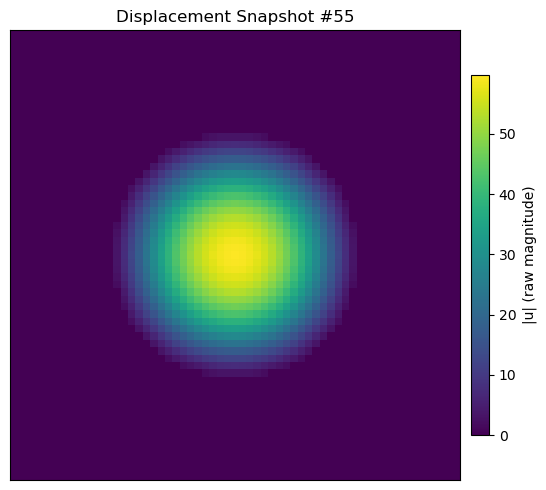

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# --- select a snapshot index ---
snap_idx = 55  # or use np.random.randint(X.shape[1])
u_snap = np.asarray(X[:, snap_idx])         # (3N,)
u_xyz = split_components(u_snap, N)         # (N, 3)
mag = np.linalg.norm(u_xyz, axis=1)         # (N,)

# --- auto-detect grid shape from coordinates ---
x_unique = np.unique(x)
y_unique = np.unique(y)
nx = len(x_unique)
ny = len(y_unique)
assert nx * ny == N, f"Inferred shape {nx}×{ny} doesn't match N={N}"

# --- sort coordinates to match grid layout ---
xy_pairs = np.column_stack((x, y))
sort_idx = np.lexsort((x, y))  # sort by y then x
mag_sorted = mag[sort_idx]
mag_grid = mag_sorted.reshape((ny, nx))  # shape (rows, cols)

# --- plot without normalization ---
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(mag_grid, origin='lower', cmap="viridis", interpolation='none',
               extent=[x.min(), x.max(), y.min(), y.max()])
cb = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cb.set_label("|u| (raw magnitude)")

ax.set_title(f"Displacement Snapshot #{snap_idx}")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(f"Displacement_snapshot_raw_{snap_idx}.png", dpi=300, transparent=True)
plt.show()


## Extract the volumes

In [ ]:
import re
import glob
import numpy as np
import zarr
from typing import Iterator, Tuple

# Reuse your FRAME_RE:
# FRAME_RE = re.compile(r"^###\s*Frame Time:\s*([0-9.+-Ee]+)\s*###")

CVOL_RE = re.compile(r"^CVOL\s*\(MFLUID node\):\s*,\s*([0-9.+-Ee]+)")

def iter_volume_snapshots(csv_path: str) -> Iterator[Tuple[float, float]]:
    """
    Yields (time, cvol) per frame for one CSV.

    Expects blocks of the form:
        ### Frame Time: 0.0000 ###
        CVOL (MFLUID node):,13272.728515625
        ...
    """
    with open(csv_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = FRAME_RE.match(line)
            if not m:
                continue
            t = float(m.group(1))

            # Next line should be the CVOL line
            cvol_line = f.readline()
            if not cvol_line:
                raise ValueError(f"Unexpected EOF after frame header in {csv_path}")

            m2 = CVOL_RE.match(cvol_line.strip())
            if not m2:
                raise ValueError(f"Expected CVOL line after frame header in {csv_path}, got: {cvol_line!r}")

            v = float(m2.group(1))
            yield t, v


def build_cvol_zarr(csv_glob_or_list, zarr_path: str, chunks: int = 4096):
    """
    Scan all CSV files, extract expander volume per frame, and save to Zarr:

      - /expander_volume/times : (S,) float32
      - /expander_volume/cvol  : (S,) float32

    S = total number of frames across all files, in the same order as the
    displacement snapshots.
    """
    # Normalize file list (same pattern as your displacement builder)
    if isinstance(csv_glob_or_list, (list, tuple)):
        files = [str(p) for p in csv_glob_or_list]
    else:
        files = sorted(glob.glob(csv_glob_or_list))
    if not files:
        raise FileNotFoundError(f"No files matched or empty list: {csv_glob_or_list}")

    times_list = []
    vols_list  = []

    print("[CVOL] Scanning CSV files for expander volume ...")
    for i, fp in enumerate(files):
        count = 0
        for t, v in iter_volume_snapshots(fp):
            times_list.append(t)
            vols_list.append(v)
            count += 1
        print(f"  {fp}  → frames: {count}")
    print(f"[CVOL] Total frames found: {len(times_list)}")

    times = np.asarray(times_list, dtype=np.float32)
    cvol  = np.asarray(vols_list,  dtype=np.float32)

    # Open existing Zarr (displacement store) and cross-check length
    g = zarr.open_group(zarr_path, mode="a")

    if "times" in g:
        disp_times = np.asarray(g["times"][:], dtype=np.float32)
        if len(disp_times) != len(times):
            raise ValueError(
                f"Mismatch: displacement times S={len(disp_times)} vs CVOL frames S={len(times)}"
            )
        # Optional: sanity check that times match (within tolerance)
        if not np.allclose(disp_times, times, rtol=1e-5, atol=1e-7):
            print("[CVOL] Warning: times from CSV do not exactly match g['times']; proceeding anyway.")
    else:
        print("[CVOL] Note: no /times array found in Zarr; skipping consistency check.")

       # Create /expander_volume group and save arrays
    grp_name = "expander_volume"
    if grp_name in g:
        del g[grp_name]
    eg = g.require_group(grp_name)

    # Metadata to clearly identify this dataset
    eg.attrs.update({
        "field": "expander_volume",
        "description": "Expander CVOL(MFLUID node) per frame, aligned with displacement snapshots",
        "source_csv_glob": str(csv_glob_or_list),
        "cvol_units": "as in input files (e.g., mm^3 or model units)",
    })

    # IMPORTANT: when using data=..., do NOT also pass dtype=
    eg.create_array(
        "times",
        data=times,
        chunks=(min(len(times), chunks),),
        overwrite=True,
    )
    eg.create_array(
        "cvol",
        data=cvol,
        chunks=(min(len(cvol), chunks),),
        overwrite=True,
    )

    print(f"[CVOL] Saved expander volumes to group '/{grp_name}' with arrays 'times' and 'cvol'.")



# --- run the builder ---
build_cvol_zarr(CSV_GLOB, ZARR_PATH)


## Build the Lamg snapshots (project to nodes) and get a POD basis

In [3]:
import numpy as np
import pandas as pd
from pathlib import Path

def load_c3d8_mesh_from_csv(nodes_csv, elements_csv):
    """
    Load a C3D8 mesh from two CSVs:
      nodes_csv:    lines like `id, x, y, z`
      elements_csv: lines like `label, n1, n2, n3, n4, n5, n6, n7, n8`

    Returns:
      node_coords : (N, 3) float array, ordered by ascending node id
      elem_conn   : (n_elem, 8) int array of 0-based node indices
      elem_labels : (n_elem,) int array of Abaqus element labels
      node_id2idx : dict mapping original node id -> 0-based index (if you need it later)
    """
    nodes_csv = Path(nodes_csv)
    elements_csv = Path(elements_csv)

    # --- Read nodes ---
    # Robust to variable spaces; no header line in your example
    df_nodes = pd.read_csv(
        nodes_csv, header=None, names=["id", "x", "y", "z"],
        skip_blank_lines=True, engine="python"
    )
    # Ensure correct types
    df_nodes["id"] = df_nodes["id"].astype(int)
    for c in ["x", "y", "z"]:
        df_nodes[c] = df_nodes[c].astype(float)

    # Sort by node id to get a stable, contiguous order
    df_nodes = df_nodes.sort_values("id").reset_index(drop=True)

    # Build mapping: original node id -> 0-based row index
    node_id2idx = {nid: i for i, nid in enumerate(df_nodes["id"].to_numpy())}

    # Node coordinate array
    node_coords = df_nodes[["x", "y", "z"]].to_numpy(dtype=float)

    # --- Read elements ---
    df_elems = pd.read_csv(
        elements_csv, header=None,
        names=["label","n1","n2","n3","n4","n5","n6","n7","n8"],
        skip_blank_lines=True, engine="python"
    )
    df_elems["label"] = df_elems["label"].astype(int)

    # Map each node id in connectivity to 0-based index using the dict
    conn_cols = ["n1","n2","n3","n4","n5","n6","n7","n8"]
    df_conn = df_elems[conn_cols].map(lambda nid: node_id2idx[int(nid)]).astype(int)

    elem_conn   = df_conn.to_numpy(dtype=int)
    elem_labels = df_elems["label"].to_numpy(dtype=int)

    # Basic sanity checks
    assert elem_conn.shape[1] == 8, "C3D8 elements must have 8 nodes per element."
    assert node_coords.ndim == 2 and node_coords.shape[1] == 3, "node_coords must be (N,3)."

    return node_coords, elem_conn, elem_labels, node_id2idx


# -----------------------------
# Example usage
# -----------------------------
nodes_path = "GOH_Nodes_Test_for_Visualization.csv"
elems_path = "GOH_Elements_Test_for_Visualization.csv"

node_coords, elem_conn, elem_labels, node_id2idx = load_c3d8_mesh_from_csv(nodes_path, elems_path)

print(f"Loaded {node_coords.shape[0]} nodes and {elem_conn.shape[0]} C3D8 elements.")
print(f"Node coords shape: {node_coords.shape}")
print(f"Elem conn shape:   {elem_conn.shape}")
print(f"Elem labels range: {elem_labels.min()}..{elem_labels.max()}")

Loaded 11163 nodes and 7200 C3D8 elements.
Node coords shape: (11163, 3)
Elem conn shape:   (7200, 8)
Elem labels range: 1..7200


In [4]:
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

# ------------------------------------------------------------
# Geometry helpers
# ------------------------------------------------------------
def hex8_shape_functions(xi, eta, zeta):
    """
    Trilinear HEX8 shape functions at (xi, eta, zeta) in [-1,1]^3.
    Returns N (8,), ordered to match the typical HEX8 node order:

      Local node order assumed: 
        0:(-1,-1,-1), 1:(+1,-1,-1), 2:(+1,+1,-1), 3:(-1,+1,-1),
        4:(-1,-1,+1), 5:(+1,-1,+1), 6:(+1,+1,+1), 7:(-1,+1,+1)

    (If your elem_conn uses a different convention, adapt the local order.)
    """
    c = np.array([-1, 1])
    # local coords for the 8 corner nodes:
    local = np.array([
        [-1, -1, -1],
        [ 1, -1, -1],
        [ 1,  1, -1],
        [-1,  1, -1],
        [-1, -1,  1],
        [ 1, -1,  1],
        [ 1,  1,  1],
        [-1,  1,  1],
    ], dtype=float)
    N = 0.125 * (1 + local[:,0]*xi) * (1 + local[:,1]*eta) * (1 + local[:,2]*zeta)
    return N  # shape (8,)

def gauss_points_2x2x2(a=1.0/np.sqrt(3.0)):
    return [
        (-a, -a, -a),  # 1
        ( a, -a, -a),  # 2
        ( a,  a, -a),  # 3
        (-a,  a, -a),  # 4
        (-a, -a,  a),  # 5
        ( a, -a,  a),  # 6
        (-a,  a,  a),  # 7  <-- swapped
        ( a,  a,  a),  # 8  <-- swapped
    ]

def compute_ip_positions_hex8(node_coords, elem_conn, gauss_pts=None):
    """
    Compute physical coordinates of each integration point for every element.
    Returns:
      ip_positions: (n_elem*8, 3) stacked in order (elem0 ip1..ip8, elem1 ip1..ip8, ...)
      elem_ip_to_flat: dict mapping (ElemLabel, IPIndex) -> flat index [0..n_elem*8-1]
        (Note: ElemLabel is 1-based Abaqus label; IPIndex is 1..8)
    Assumes elem_conn rows are 0-based node IDs into node_coords.
    """
    if gauss_pts is None:
        gauss_pts = gauss_points_2x2x2()
    n_elem = elem_conn.shape[0]
    ip_positions = np.zeros((n_elem * 8, 3), dtype=float)
    # Flat index is (e * 8 + (ip_index-1))
    for e in range(n_elem):
        nodes = elem_conn[e]  # (8,)
        X = node_coords[nodes, :]  # (8,3)
        for ip_i, (xi, eta, zeta) in enumerate(gauss_pts, start=1):
            N = hex8_shape_functions(xi, eta, zeta)[:, None]  # (8,1)
            x_ip = (N * X).sum(axis=0)  # (3,)
            flat = e*8 + (ip_i-1)
            ip_positions[flat, :] = x_ip
    return ip_positions

def build_elemip_index(elem_labels):
    """
    Create a mapping from (ElemLabel, IPIndex) -> flat index aligned with compute_ip_positions_hex8 output.
    Assumes elem_labels[e] equals the Abaqus label for element row e.
    """
    mapping = {}
    for e, lab in enumerate(elem_labels):
        for ip in range(1, 9):
            mapping[(int(lab), int(ip))] = e*8 + (ip-1)
    return mapping

# ------------------------------------------------------------
# Node <- IP mapping (4-nearest)
# ------------------------------------------------------------
def precompute_node_to_ip_neighbors(node_coords, ip_positions, k=4):
    """
    Build a static map of nearest IPs to each node using a KD-tree on IP positions.
    Returns:
      neighbors_idx: (N, k) array of flat IP indices for each node
    """
    tree = cKDTree(ip_positions)
    dists, idxs = tree.query(node_coords, k=k)
    # Ensure shape (N,k)
    if idxs.ndim == 1:
        idxs = idxs[:, None]
    return idxs

# ------------------------------------------------------------
# Reading per-frame CSVs and building IP arrays
# ------------------------------------------------------------
def read_ip_values_for_frame(csv_path, elemip_to_flat, fields=("SDV1", "SDV4")):
    """
    Read a frame CSV and return dense arrays (len = n_elem*8) for requested fields.
    The CSV must contain 'ElemLabel', 'IPIndex' and the requested SDV columns.
    """
    df = pd.read_csv(csv_path)
    # Preallocate dense arrays
    n_ip_total = len(elemip_to_flat)
    out = {f: np.zeros(n_ip_total, dtype=float) for f in fields}

    # Fast path: vectorized reindex using a single flat index column
    # Build flat index per row; rows that don't exist in the mapping will be ignored
    # (but with Abaqus-style outputs they should all exist).
    flats = df.apply(lambda r: elemip_to_flat.get((int(r["ElemLabel"]), int(r["IPIndex"])), -1), axis=1).to_numpy()
    valid = flats >= 0
    for f in fields:
        tmp = np.zeros(n_ip_total, dtype=float)
        tmp[flats[valid]] = df.loc[valid, f].to_numpy()
        out[f] = tmp
    return out  # dict of 1D arrays length n_elem*8

# ------------------------------------------------------------
# IP -> Node aggregation (uniform average of nearest 4)
# ------------------------------------------------------------
def ip_to_nodes_uniform(neighbors_idx, ip_field_values):
    """
    Given neighbors_idx: (N,k) and ip_field_values: (M,) with M=n_elem*8,
    return nodal array (N,) as the mean of the k nearest IPs.
    """
    # Gather values: (N,k)
    gathered = ip_field_values[neighbors_idx]
    return gathered.mean(axis=1)

# ------------------------------------------------------------
# POD (SVD) utilities
# ------------------------------------------------------------
def compute_pod(snapshot_matrix, center=True, r=None, energy_tol=None):
    """
    snapshot_matrix: (n_dof, n_snap)
    center: subtract temporal mean
    r: optional target rank (overrides energy_tol if provided)
    energy_tol: retain modes up to this cumulative energy (e.g., 0.999)

    Returns:
      Phi: (n_dof, r_kept) POD modes (columns)
      S:   (r_kept,) singular values
      mean_field: (n_dof,) mean used (zeros if center=False)
      energy_cum: (r_kept,) cumulative energy fraction
    """
    A = snapshot_matrix.copy()
    mean_field = A.mean(axis=1) if center else np.zeros(A.shape[0])
    if center:
        A = A - mean_field[:, None]

    # economy SVD
    U, s, VT = np.linalg.svd(A, full_matrices=False)

    if r is None and energy_tol is not None:
        e = np.cumsum(s**2) / np.sum(s**2) if s.size > 0 else np.array([])
        r = int(np.searchsorted(e, energy_tol) + 1) if e.size else 0
    if r is None:
        r = U.shape[1]

    r = min(r, U.shape[1])
    Phi = U[:, :r]
    S = s[:r]
    energy_cum = np.cumsum(S**2) / np.sum(S**2) if S.size else np.array([])
    return Phi, S, mean_field, energy_cum

# ------------------------------------------------------------
# End-to-end driver
# ------------------------------------------------------------
def build_pod_from_ip_csvs(csv_paths, node_coords, elem_conn, elem_labels,
                           k_nearest=4, fields=("SDV1","SDV4"),
                           center=True, energy_tol=0.999):
    """
    1) Precompute IP positions from geometry (HEX8).
    2) Precompute node->nearest-IP neighbor map (k=4).
    3) For each frame CSV:
         - read IP values for requested fields
         - aggregate to nodes via uniform average of nearest k IPs
         - store nodal snapshots
    4) Compute POD for each requested field independently.

    Returns:
      results: dict keyed by field, with:
        {
          'Phi': (N, r), 'S': (r,), 'mean': (N,),
          'energy_cum': (r,), 'snapshots': (N, n_frames)
        }
      plus utilities:
        {
          'neighbors_idx': (N,k),
          'ip_positions': (M,3),
          'elemip_to_flat': dict
        }
    """
    # 1) IP positions and indexing
    ip_positions = compute_ip_positions_hex8(node_coords, elem_conn)
    elemip_to_flat = build_elemip_index(elem_labels)

    # 2) Nearest neighbors (static)
    neighbors_idx = precompute_node_to_ip_neighbors(node_coords, ip_positions, k=k_nearest)

    # 3) Read & aggregate frames
    N = node_coords.shape[0]
    n_frames = len(csv_paths)
    nodal_snaps = {f: np.zeros((N, n_frames), dtype=float) for f in fields}

    for j, csvp in enumerate(csv_paths):
        ip_vals = read_ip_values_for_frame(csvp, elemip_to_flat, fields=fields)
        for f in fields:
            nodal_field = ip_to_nodes_uniform(neighbors_idx, ip_vals[f])
            nodal_snaps[f][:, j] = nodal_field

    # 4) POD per field
    results = {}
    for f in fields:
        Phi, S, mean_field, energy_cum = compute_pod(nodal_snaps[f], center=center, energy_tol=energy_tol)
        results[f] = {
            "Phi": Phi,
            "S": S,
            "mean": mean_field,
            "energy_cum": energy_cum,
            "snapshots": nodal_snaps[f],
        }

    # utilities to reuse later
    results["_utils"] = {
        "neighbors_idx": neighbors_idx,
        "ip_positions": ip_positions,
        "elemip_to_flat": elemip_to_flat,
    }
    return results

In [6]:
import re, csv
import pandas as pd
from io import StringIO

def iter_ip_snapshots(csv_path, fields=("SDV1","SDV4"), time_col=None, frame_col=None):
    """
    Yield (t, df_ip) pairs from a 'combined' CSV-like text file that contains:
      - arbitrary nodal data section(s)
      - a line '=== INTEGRATION POINT DATA ==='
      - a header:  ElemLabel,IPIndex,SDV1,SDV3,SDV4,SDV6,...
      - rows for that frame
      - optional '### Frame Time: <float> ###' lines before each frame
    Repeats for multiple frames.

    Returns for each frame:
      t: float or None (parsed from '### Frame Time: <t> ###' if present)
      df_ip: pandas DataFrame with columns ['ElemLabel','IPIndex', *fields_present]
             (only the IP table for that frame)
    """
    # Regex to capture '### Frame Time: 68.6000 ###'
    time_pat = re.compile(r"^\s*#+\s*Frame\s+Time\s*:\s*([0-9eE\.\+\-]+)")
    ip_section_flag = "=== INTEGRATION POINT DATA ==="

    current_time = None
    in_ip_section = False
    ip_header = None
    rows_accum = []

    def flush_frame():
        """Build a DataFrame for the accumulated IP rows (if any) and return it."""
        nonlocal rows_accum, ip_header
        if not rows_accum or not ip_header:
            return None
        # Build CSV text from header + rows, then read via pandas
        sio = StringIO()
        w = csv.writer(sio)
        w.writerow(ip_header)
        w.writerows(rows_accum)
        sio.seek(0)
        df = pd.read_csv(sio)
        # Coerce required columns
        if "ElemLabel" in df.columns:
            df["ElemLabel"] = df["ElemLabel"].astype(int)
        if "IPIndex" in df.columns:
            df["IPIndex"] = df["IPIndex"].astype(int)
        return df

    with open(csv_path, "r", newline="") as f:
        for raw_line in f:
            line = raw_line.rstrip("\n")

            # Check for time markers
            m = time_pat.search(line)
            if m:
                # If we were in the middle of collecting an IP table, flush it as a frame
                if in_ip_section:
                    df_ip = flush_frame()
                    if df_ip is not None:
                        # Filter to requested fields if provided
                        yield (current_time, _filter_ip_fields(df_ip, fields))
                    # Reset accumulators for next frame’s IP table
                    rows_accum = []
                    ip_header = None
                    in_ip_section = False
                # Update current frame time
                try:
                    current_time = float(m.group(1))
                except Exception:
                    current_time = None
                continue

            # Detect start of IP section
            if ip_section_flag in line:
                in_ip_section = True
                ip_header = None
                rows_accum = []
                continue

            if in_ip_section:
                # The line immediately after the marker should be header OR blank
                if ip_header is None:
                    stripped = line.strip()
                    if not stripped:
                        # skip empty line between marker and header (if any)
                        continue
                    # Parse header as CSV
                    ip_header = [h.strip() for h in next(csv.reader([stripped]))]
                    continue

                # If we hit a blank line or the start of a new section/time, we will flush on the next marker/time
                if not line.strip():
                    # allow blank lines inside the block — Abaqus-style outputs can be quirky
                    continue

                # If we reach a new non-data marker that looks like a section header (starts with '=' or '#'),
                # the safer approach is to defer flushing until we see the next time marker or next IP section.
                # Otherwise, collect data rows.
                if line.lstrip().startswith(("===", "###")):
                    # We'll let the outer loop detect the next marker/time and flush then.
                    continue

                # Collect a normal CSV data row for this IP table
                row = next(csv.reader([line]))
                # Basic guard: enforce row length to match header (truncate/extend if needed)
                if len(row) < len(ip_header):
                    row = row + [""] * (len(ip_header) - len(row))
                elif len(row) > len(ip_header):
                    row = row[:len(ip_header)]
                rows_accum.append(row)

        # End of file: flush any pending IP table as a final frame
        if in_ip_section:
            df_ip = flush_frame()
            if df_ip is not None:
                yield (current_time, _filter_ip_fields(df_ip, fields))


def _filter_ip_fields(df_ip, fields):
    """
    Return df with ['ElemLabel','IPIndex', *requested_fields_that_exist].
    """
    keep = ["ElemLabel", "IPIndex"]
    if fields:
        for f in fields:
            if f in df_ip.columns:
                keep.append(f)
    else:
        # If fields=None or empty, keep all SDV* columns
        keep += [c for c in df_ip.columns if c not in ("ElemLabel", "IPIndex")]
    return df_ip[keep]


def frame_df_to_dense_ip_arrays(df_ip, elemip_to_flat, fields=("SDV1","SDV4")):
    """
    Convert a single-frame IP DataFrame -> dense 1D arrays aligned to elemip_to_flat.
    df_ip must include ElemLabel, IPIndex, and requested SDV columns.
    Returns dict: {field: np.ndarray of length len(elemip_to_flat)}
    """
    # Pre-size arrays
    n_ip_total = len(elemip_to_flat)
    out = {f: (pd.Series(0.0, index=range(n_ip_total), dtype=float).to_numpy()) for f in fields}

    # Build flat indices for each row
    flats = df_ip.apply(
        lambda r: elemip_to_flat.get((int(r["ElemLabel"]), int(r["IPIndex"])), -1),
        axis=1
    ).to_numpy()
    valid = flats >= 0

    # Scatter values
    for f in fields:
        if f in df_ip.columns:
            vals = df_ip.loc[valid, f].to_numpy()
            out[f][flats[valid]] = vals
    return out


In [7]:
import numpy as np, zarr, glob, time
from typing import Sequence, Union

# Optional compressor (same pattern you used)
try:
    from numcodecs import Blosc
    _blosc = Blosc(cname="zstd", clevel=4, shuffle=Blosc.SHUFFLE)
except Exception:
    _blosc = None  # fallback: uncompressed
_blosc = None
def _require_array(g, name, shape, chunks, dtype):
    """Create-or-get an array that works on Zarr v2 or v3 (mirrors your helper)."""
    try:
        return g[name]
    except KeyError:
        pass
    try:  # v3
        if _blosc is not None:
            return g.require_array(name, shape=shape, chunks=chunks, dtype=dtype, compressors=[_blosc])
        else:
            return g.require_array(name, shape=shape, chunks=chunks, dtype=dtype)
    except TypeError:  # v2
        if _blosc is not None:
            return g.require_dataset(name, shape=shape, chunks=chunks, dtype=dtype, compressor=_blosc)
        else:
            return g.require_dataset(name, shape=shape, chunks=chunks, dtype=dtype)

def build_ip_nodal_zarr_resume(
    csv_list_or_glob: Union[str, Sequence[str]],
    zarr_path: str,
    node_coords: np.ndarray,
    elem_conn: np.ndarray,
    elem_labels: np.ndarray,
    *,
    fields=("SDV1","SDV4"),
    k_nearest: int = 4,
    chunks_snap: int = 16_384,
    dtype="f4",
    checkpoint_every: int = 50,
    block_size: int = 50,  # NEW: number of frames to batch before writing
):
    # Resolve file list
    if isinstance(csv_list_or_glob, (list, tuple)):
        files = [str(p) for p in csv_list_or_glob]
    else:
        files = sorted(glob.glob(csv_list_or_glob))
    if not files:
        raise FileNotFoundError(f"No files found for {csv_list_or_glob}")

    # Geometry → one-time preprocess
    ip_positions   = compute_ip_positions_hex8(node_coords, elem_conn)
    elemip_to_flat = build_elemip_index(elem_labels)
    neighbors_idx  = precompute_node_to_ip_neighbors(node_coords, ip_positions, k=k_nearest)

    N = node_coords.shape[0]
    g = zarr.open_group(zarr_path, mode="a")

    # Meta (store once)
    g.attrs.setdefault("ip_mapping", {"k_nearest": int(k_nearest), "N": int(N), "fields": list(fields)})
    mg = g.require_group("meta")
    mg.attrs["node_count"] = int(N)
    mg.attrs["elem_count"] = int(elem_conn.shape[0])

    # Resume checkpoint
    ckpt = g.attrs.get("checkpoint", {"file_idx": 0, "frame_idx": 0, "S_total": 0})
    file_start = int(ckpt.get("file_idx", 0))
    frame_start_for_first = int(ckpt.get("frame_idx", 0))
    S_total = int(ckpt.get("S_total", 0))

    # Create/get arrays
    snaps = {}
    for f in fields:
        arr = g.get(f"snaps_{f}", None)
        if arr is None:
            snaps[f] = _require_array(
                g,
                f"snaps_{f}",
                shape=(N, 0),
                chunks=(min(N, chunks_snap), chunks_snap),
                dtype=dtype,
            )
        else:
            snaps[f] = arr

    times = g.get("times", None)
    if times is None:
        times = _require_array(g, "times", shape=(0,), chunks=(chunks_snap,), dtype="f4")

    wrote_any = False

    # --- NEW: buffers for block writing ---
    block_data = {f: [] for f in fields}   # each entry: list of (N,) arrays
    block_times = []

    def flush_block():
        nonlocal S_total, wrote_any, block_data, block_times
        if not block_times:
            return

        B = len(block_times)  # number of frames in block

        # times
        old_T = times.shape[0]
        times.resize((old_T + B,))
        times[old_T : old_T + B] = np.asarray(block_times, dtype=np.float32)

        # each field
        for f in fields:
            if not block_data[f]:
                # If some frames are missing this field in your data,
                # you might want to handle that more carefully.
                continue
            old_S = snaps[f].shape[1]
            snaps[f].resize((N, old_S + B))
            # stack to (B, N) then transpose to (N, B)
            block_arr = np.stack(block_data[f], axis=0).astype(dtype)  # (B, N)
            snaps[f][:, old_S : old_S + B] = block_arr.T

        S_total += B
        wrote_any = True

        # reset buffers
        block_data = {f: [] for f in fields}
        block_times = []

    # Stream files & frames
    for i in range(file_start, len(files)):
        fp = files[i]
        frame_counter = 0
        for t, df_ip in iter_ip_snapshots(fp, fields=fields):
            # skip frames if resuming inside this file
            if i == file_start and frame_counter < frame_start_for_first:
                frame_counter += 1
                continue

            dense = frame_df_to_dense_ip_arrays(df_ip, elemip_to_flat, fields=fields)

            # Build nodal fields in memory
            for f in fields:
                if f not in dense:
                    continue  # keep same semantics as original
                nodal = ip_to_nodes_uniform(neighbors_idx, dense[f])  # (N,)
                block_data[f].append(nodal)

            block_times.append(np.float32(t))
            frame_counter += 1

            # If block full → flush to Zarr
            if len(block_times) >= block_size:
                flush_block()
                # Update checkpoint after each flush (preserves resume semantics)
                g.attrs["checkpoint"] = {"file_idx": i, "frame_idx": frame_counter, "S_total": S_total}
                if checkpoint_every and (S_total % checkpoint_every) == 0:
                    print(f"[checkpoint] Written {S_total} snapshots so far (file {i+1}/{len(files)})")

        # flush any partial block at file boundary
        flush_block()
        g.attrs["checkpoint"] = {"file_idx": i+1, "frame_idx": 0, "S_total": S_total}

    # final checkpoint
    g.attrs["checkpoint"] = {"file_idx": len(files), "frame_idx": 0, "S_total": S_total}

    msg = "Appended" if wrote_any else "Nothing to append (already complete)"
    print(f"[info] {msg}. Total snapshots: {S_total}.")


In [8]:
def _iter_row_blocks(M: int, block: int):
    for a in range(0, M, block):
        yield a, min(M, a+block)

def exact_pod_gram_to_zarr_field(
    zarr_path: str,
    field: str,          # e.g., "SDV1" or "SDV4"
    r_modes: int,
    row_block: int = 200_000,
    dtype_out: str = "f4"
):
    """
    Exact SVD (Gram method) of mean-centered snapshots_<field>.
    Saves to /pod_<field>/{Phi, svals, mean}.
    """
    g = zarr.open_group(zarr_path, mode="a")
    X = g[f"snaps_{field}"]     # (N, S)
    N, S = X.shape
    print(f"[POD:{field}] X shape N={N}, S={S} ...")

    # 1) mean across snapshots (rows streamed)
    mean = np.zeros((N,), dtype=np.float64)
    for a, b in _iter_row_blocks(N, row_block):
        mean[a:b] = np.asarray(X[a:b, :]).mean(axis=1, dtype=np.float64)
    mean_f32 = mean.astype(np.float32)

    # 2) Gram G = Xc^T Xc  (S x S)
    print(f"[POD:{field}] Building Gram (SxS) ...")
    G = np.zeros((S, S), dtype=np.float64)
    for a, b in _iter_row_blocks(N, row_block):
        B = np.asarray(X[a:b, :], dtype=np.float64)
        B -= mean[a:b, None]
        G += B.T @ B

    # 3) eigendecomposition
    print(f"[POD:{field}] Eigendecomposition ...")
    lam, V = np.linalg.eigh(G)         # ascending
    idx = np.argsort(lam)[::-1]
    lam = lam[idx]
    V = V[:, idx]

    s_all = np.sqrt(np.maximum(lam, 0.0))
    if r_modes > s_all.size:
        raise ValueError(f"Requested r={r_modes} but only {s_all.size} singular values available.")
    s = s_all[:r_modes].astype(np.float32)
    V = V[:, :r_modes].astype(np.float64)

    # 4) allocate outputs
    pg = g.require_group(f"pod_{field}")
    for k in ("Phi","svals","mean"):
        if k in pg: del pg[k]
    Phi_z = pg.create_array("Phi",   shape=(N, r_modes),
                            chunks=(min(N, row_block), min(r_modes, 256)), dtype=dtype_out)
    pg.create_array("svals", shape=(r_modes,), dtype="f4")[:] = s
    pg.create_array("mean",  shape=(N,),       dtype="f4")[:] = mean_f32

    # 5) backproject Φ = Xc V Σ^{-1} (rows streamed)
    inv_sigma = (1.0 / s.astype(np.float64))
    for a, b in _iter_row_blocks(N, row_block):
        B = np.asarray(X[a:b, :], dtype=np.float64)
        B -= mean[a:b, None]
        block = B @ V               # (rb, r)
        block *= inv_sigma          # divide columns by σ_i
        Phi_z[a:b, :] = block.astype(dtype_out)

    print(f"[POD:{field}] Done. Saved r={r_modes} modes.")
    return Phi_z, s, mean_f32

def run_pod_for_fields(zarr_path: str, fields=("SDV1","SDV4"), r_modes: int = 100, row_block: int = 200_000):
    out = {}
    for f in fields:
        Phi_z, svals, mean_vec = exact_pod_gram_to_zarr_field(
            zarr_path, field=f, r_modes=r_modes, row_block=row_block, dtype_out="f4"
        )
        out[f] = (Phi_z, svals, mean_vec)
    return out

In [51]:
# 1) Extract & save nodal snapshots from IP data (resume-safe, with checkpoints)
build_ip_nodal_zarr_resume(
    CSV_GLOB,                # your list of GOH_Job*_combined_data.csv
    zarr_path="ip_nodal.zarr",
    node_coords=node_coords,
    elem_conn=elem_conn,
    elem_labels=elem_labels,
    fields=("SDV1","SDV4"),
    k_nearest=4,
    chunks_snap=16_384,
    dtype="f4",
    checkpoint_every=50     # prints: [checkpoint] Written {S} snapshots so far (file {i+1}/{len(files)})
)

[checkpoint] Written 36900 snapshots so far (file 809/927)
[checkpoint] Written 40450 snapshots so far (file 889/927)
[info] Appended. Total snapshots: 42237.


# Map Growth Fields to the Elements

In [16]:
# =========================
# Block 6 — Element (surface IP 5–8) averaging + resume-safe Zarr writer
# =========================
import numpy as np
import pandas as pd
import zarr
from pathlib import Path
import glob

# --- reuse from your earlier blocks ---
# - build_elemip_index(elem_labels)
# - iter_ip_snapshots(...)
# - frame_df_to_dense_ip_arrays(df_ip, elemip_to_flat, fields)

def elem_surface_ip_flat_indices(n_elem: int):
    """
    For each HEX8 element, return the 4 flat indices corresponding to IPs 5–8.
    Flat indexing convention: flat = e*8 + (ip-1), ip=1..8.
    So IPs 5..8 correspond to offsets 4..7.
    Returns: (n_elem, 4) int array
    """
    base = (np.arange(n_elem, dtype=int) * 8)[:, None]          # (n_elem,1)
    offs = np.array([4, 5, 6, 7], dtype=int)[None, :]           # (1,4)
    return base + offs                                          # (n_elem,4)

def ip_to_elems_surface_avg(ip_field_values, surf_ip_idx):
    """
    ip_field_values: (n_elem*8,) dense array
    surf_ip_idx: (n_elem,4) flat indices for IPs 5..8 for each element
    Returns: elem_values (n_elem,) as average over the 4 surface IPs.
    """
    gathered = ip_field_values[surf_ip_idx]   # (n_elem,4)
    return gathered.mean(axis=1)

def _ensure_list_of_files(csv_glob_or_list):
    if isinstance(csv_glob_or_list, (list, tuple)):
        files = list(csv_glob_or_list)
    else:
        files = sorted(glob.glob(str(csv_glob_or_list)))
    if not files:
        raise FileNotFoundError(f"No CSV files matched: {csv_glob_or_list}")
    return files

def build_ip_elem_zarr_resume(
    CSV_GLOB,
    zarr_path="ip_growth_elem.zarr",
    elem_labels=None,
    fields=("SDV1","SDV4"),
    chunks_snap=8192,
    dtype="f4",
    checkpoint_every=50,
):
    """
    Read your combined per-job CSVs, extract IP fields, and save *element-level* snapshots by
    averaging IPs 5–8 (surface) for each HEX8 element.

    Writes:
      /snaps_<field> : (n_elem, S)  [resizeable along S]
      /times         : (S,) float64 [optional if frame times exist; NaN otherwise]
      /meta/elem_labels : (n_elem,) int
      /meta/fields      : (len(fields),) str

    Resume-safe:
      If zarr exists, continues appending from existing S.
    """
    if elem_labels is None:
        raise ValueError("elem_labels is required (Abaqus element labels, aligned with elem_conn rows).")

    files = _ensure_list_of_files(CSV_GLOB)
    zarr_path = str(zarr_path)

    # --- open/create zarr ---
    g = zarr.open_group(zarr_path, mode="a")

    # --- meta ---
    mg = g.require_group("meta")


    if "elem_labels" not in mg:
        mg.create_array("elem_labels", data=np.asarray(elem_labels, dtype=np.int64))


    # Store fields as attributes (avoids object dtype issues in Zarr v3)
    if "fields" not in mg.attrs:
        mg.attrs["fields"] = list(fields)
    n_elem = len(elem_labels)
    surf_ip_idx = elem_surface_ip_flat_indices(n_elem)  # (n_elem,4)

    # --- build elem/ip mapping once ---
    elemip_to_flat = build_elemip_index(elem_labels)  # (ElemLabel, IPIndex) -> flat [0..n_elem*8-1]

    # --- create/require snapshot arrays ---
    snaps = {}
    for f in fields:
        name = f"snaps_{f}"
        if name not in g:
            # compressor=None avoids blosc; keeps things simple/portable
            snaps[f] = g.create_array(
                name,
                shape=(n_elem, 0),
                chunks=(min(n_elem, chunks_snap), 16),
                dtype=dtype,
                compressor=None,
            )
        else:
            snaps[f] = g[name]

    if "times" not in g:
        times = g.create_array("times", shape=(0,), chunks=(1024,), dtype="f8", compressor=None)
    else:
        times = g["times"]

    # --- current size (resume) ---
    S0 = snaps[fields[0]].shape[1]
    for f in fields[1:]:
        if snaps[f].shape[1] != S0:
            raise ValueError(f"Existing snapshot counts disagree: {fields[0]} has {S0}, {f} has {snaps[f].shape[1]}")
    if times.shape[0] != S0:
        # allow missing/older times array mismatch, but better to keep consistent
        # We'll resize times to match S0 if needed (filling with NaN)
        times.resize((S0,))
        if S0 > 0:
            ttmp = np.asarray(times[:], dtype=np.float64)
            if ttmp.size < S0:
                pad = np.full((S0-ttmp.size,), np.nan, dtype=np.float64)
                times[:] = np.concatenate([ttmp, pad])

    S_total = S0
    written_frames = 0

    print(f"[elem-zarr] Writing to: {zarr_path}")
    print(f"[elem-zarr] Elements: {n_elem}, fields: {fields}")
    print(f"[elem-zarr] Resume: starting at S={S_total} existing snapshots")

    # --- helper to append one frame ---
    def append_frame(t, df_ip):
        nonlocal S_total, written_frames

        ip_vals = frame_df_to_dense_ip_arrays(df_ip, elemip_to_flat, fields=fields)

        # element surface avg per field
        elem_vals = {}
        for f in fields:
            elem_vals[f] = ip_to_elems_surface_avg(ip_vals[f], surf_ip_idx).astype(dtype, copy=False)

        # resize zarr and write
        newS = S_total + 1
        for f in fields:
            snaps[f].resize((n_elem, newS))
            snaps[f][:, S_total] = elem_vals[f]

        times.resize((newS,))
        times[S_total] = float(t) if (t is not None) else np.nan

        S_total = newS
        written_frames += 1

    # --- main loop over files and frames ---
    file_counter = 0
    for i, fp in enumerate(files):
        file_counter += 1
        # iterate frames inside a combined file
        for (t, df_ip) in iter_ip_snapshots(fp, fields=fields):
            append_frame(t, df_ip)

            if (written_frames % checkpoint_every) == 0:
                print(f"[checkpoint] Written {written_frames} new snapshots (total S={S_total}) — file {file_counter}/{len(files)}")

    print(f"[elem-zarr] Done. Added {written_frames} snapshots. Total S={S_total}")
    return g

In [21]:
# =========================
# Block 7 — Run it (writes ip_growth_elem.zarr)
# =========================

# CSV_GLOB can be a glob pattern like:
# CSV_GLOB = r"/path/to/GOH_Job*_combined_data.csv"
# or a list of explicit file paths.

build_ip_elem_zarr_resume(
    CSV_GLOB,
    zarr_path="ip_growth_elem.zarr",
    elem_labels=elem_labels,
    fields=("SDV1","SDV4"),
    chunks_snap=8192,
    dtype="f4",
    checkpoint_every=50
)

[elem-zarr] Writing to: ip_growth_elem.zarr
[elem-zarr] Elements: 7200, fields: ('SDV1', 'SDV4')
[elem-zarr] Resume: starting at S=1713 existing snapshots
[checkpoint] Written 50 new snapshots (total S=1763) — file 1/927
[checkpoint] Written 100 new snapshots (total S=1813) — file 2/927
[checkpoint] Written 150 new snapshots (total S=1863) — file 3/927
[checkpoint] Written 200 new snapshots (total S=1913) — file 4/927
[checkpoint] Written 250 new snapshots (total S=1963) — file 5/927
[checkpoint] Written 300 new snapshots (total S=2013) — file 7/927
[checkpoint] Written 350 new snapshots (total S=2063) — file 8/927
[checkpoint] Written 400 new snapshots (total S=2113) — file 9/927
[checkpoint] Written 450 new snapshots (total S=2163) — file 9/927
[checkpoint] Written 500 new snapshots (total S=2213) — file 10/927
[checkpoint] Written 550 new snapshots (total S=2263) — file 11/927
[checkpoint] Written 600 new snapshots (total S=2313) — file 12/927
[checkpoint] Written 650 new snapshots 

<Group file://ip_growth_elem.zarr>

In [18]:
# =========================
# Block 8 — Quick sanity check
# =========================
import zarr, numpy as np

g = zarr.open_group("ip_growth_elem.zarr", mode="r")
for f in ("SDV1","SDV4"):
    X = g[f"snaps_{f}"]
    print("fields:", g["meta"].attrs.get("fields", None))
print("times:", g["times"].shape, "nan% =", np.isnan(np.asarray(g["times"][:])).mean()*100)
print("elem_labels:", g["meta"]["elem_labels"].shape)

fields: ['SDV1', 'SDV4']
fields: ['SDV1', 'SDV4']
times: (1713,) nan% = 0.0
elem_labels: (7200,)


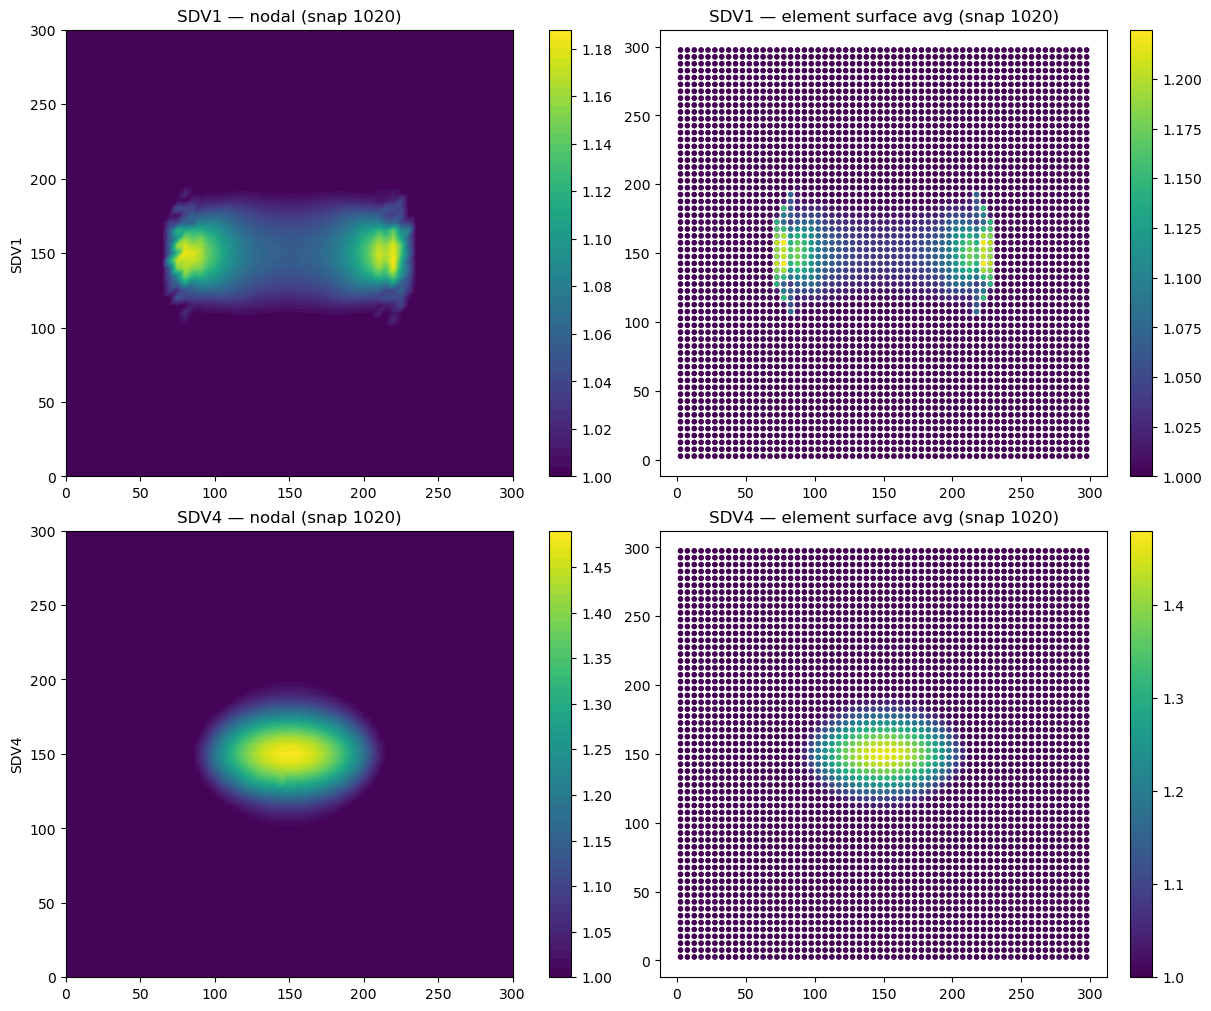

In [24]:
## Visualize a sample snapshot
import numpy as np
import zarr
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation

# -------------------------
# User controls
# -------------------------
SNAP_IDX = 1020           # snapshot index to plot
FIELDS   = ("SDV1", "SDV4")

ZARR_NODAL = "ip_nodal.zarr"
ZARR_ELEM  = "ip_growth_elem.zarr"

# -------------------------
# Load zarrs
# -------------------------
gN = zarr.open_group(ZARR_NODAL, mode="r")
gE = zarr.open_group(ZARR_ELEM,  mode="r")

# -------------------------
# Build a surface triangulation for plotting
# (simple: project to XY; OK for visualization)
# -------------------------
xy = node_coords[:, :2]

# Use bottom face triangles from HEX8 connectivity
# faces: (n_elem*2, 3)
triangles = []
for e in range(elem_conn.shape[0]):
    n = elem_conn[e]
    # bottom face assumed nodes 0-3
    triangles.append([n[0], n[1], n[2]])
    triangles.append([n[0], n[2], n[3]])

triangles = np.asarray(triangles, dtype=int)
tri = Triangulation(xy[:, 0], xy[:, 1], triangles)

# -------------------------
# Element centroids (for elem plots)
# -------------------------
elem_centroids = node_coords[elem_conn].mean(axis=1)[:, :2]

# -------------------------
# Plot
# -------------------------
fig, axs = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

for i, f in enumerate(FIELDS):
    # --- nodal ---
    uN = gN[f"snaps_{f}"][:, SNAP_IDX]
    c0 = axs[i, 0].tricontourf(tri, uN, levels=50)
    axs[i, 0].set_title(f"{f} — nodal (snap {SNAP_IDX})")
    axs[i, 0].set_aspect("equal")
    fig.colorbar(c0, ax=axs[i, 0])

    # --- element ---
    uE = gE[f"snaps_{f}"][:, SNAP_IDX]
    c1 = axs[i, 1].scatter(
        elem_centroids[:, 0],
        elem_centroids[:, 1],
        c=uE,
        s=8,
        cmap="viridis"
    )
    axs[i, 1].set_title(f"{f} — element surface avg (snap {SNAP_IDX})")
    axs[i, 1].set_aspect("equal")
    fig.colorbar(c1, ax=axs[i, 1])

axs[0, 0].set_ylabel("SDV1")
axs[1, 0].set_ylabel("SDV4")

plt.show()

## Compute area growth metric and store this feature in Zarr

In [28]:
# =========================
# Block 12 — Compute & store net growth area gain per snapshot in ip_growth_elem.zarr
# =========================
import numpy as np
import zarr

def compute_store_net_area_gain(
    zarr_path="ip_growth_elem.zarr",
    sdv_x="SDV1",
    sdv_y="SDV4",
    out_group="derived",
    out_name="Ag_net",              # net growth area gain per snapshot
    elem_area_cm2=0.25,             # 25 mm^2 = 0.25 cm^2
    snap_block=256,                 # process snapshots in blocks to save memory
    dtype_out="f8",
):
    """
    Reads elementwise growth stretches SDV1 (x) and SDV4 (y) from:
      /snaps_SDV1 : (n_elem, S)
      /snaps_SDV4 : (n_elem, S)

    For each element e and snapshot s:
      A_e(s)      = SDV1(e,s) * SDV4(e,s) * elem_area_cm2
      dA_e(s)     = A_e(s) - elem_area_cm2
      Ag_net(s)   = sum_e dA_e(s) = elem_area_cm2 * sum_e( SDV1*SDV4 - 1 )

    Stores:
      /<out_group>/<out_name> : (S,) float64
    """
    g = zarr.open_group(zarr_path, mode="a")
    Xx = g[f"snaps_{sdv_x}"]   # (n_elem, S)
    Xy = g[f"snaps_{sdv_y}"]   # (n_elem, S)

    n_elem, S = Xx.shape
    if Xy.shape != (n_elem, S):
        raise ValueError(f"Shape mismatch: snaps_{sdv_x} is {Xx.shape}, snaps_{sdv_y} is {Xy.shape}")

    dg = g.require_group(out_group)

    # Create or validate output array
    if out_name in dg:
        Ag = dg[out_name]
        if Ag.shape != (S,):
            raise ValueError(f"Existing {out_group}/{out_name} has shape {Ag.shape}, expected {(S,)}")
    else:
        Ag = dg.create_array(
            out_name,
            shape=(S,),
            chunks=(min(S, max(1024, snap_block)),),
            dtype=dtype_out,
            compressor=None,
        )

    # Compute in snapshot blocks (columns)
    print(f"[Ag_net] n_elem={n_elem}, S={S}, elem_area_cm2={elem_area_cm2}")
    for s0 in range(0, S, snap_block):
        s1 = min(S, s0 + snap_block)

        # Load block: (n_elem, B)
        bx = np.asarray(Xx[:, s0:s1], dtype=np.float64)
        by = np.asarray(Xy[:, s0:s1], dtype=np.float64)

        # Ag_net(s) = area * sum_e( bx*by - 1 )
        # sums over elements -> (B,)
        block_net = elem_area_cm2 * np.sum((bx * by) - 1.0, axis=0)

        Ag[s0:s1] = block_net.astype(dtype_out, copy=False)

        if (s0 // snap_block) % 10 == 0 or s1 == S:
            print(f"[Ag_net] wrote snapshots {s0}:{s1} / {S}")

    # (Optional) store metadata as attrs
    dg.attrs["Ag_net_definition"] = "Ag_net(s) = elem_area_cm2 * sum_e( SDV1(e,s)*SDV4(e,s) - 1 )"
    dg.attrs["elem_area_cm2"] = float(elem_area_cm2)
    dg.attrs["sdv_x"] = sdv_x
    dg.attrs["sdv_y"] = sdv_y

    print(f"[Ag_net] Done. Saved to {zarr_path}/{out_group}/{out_name} (cm^2).")
    return Ag


# ---- run it ----
Ag = compute_store_net_area_gain(
    zarr_path="ip_growth_elem.zarr",
    sdv_x="SDV1",
    sdv_y="SDV4",
    out_group="derived",
    out_name="Ag_net",
    elem_area_cm2=0.25,
    snap_block=256,
    dtype_out="f8",
)

print("Ag_net shape:", Ag.shape, "dtype:", Ag.dtype)
print("Ag_net sample [0:5]:", np.asarray(Ag[:5]))

C:\Users\youruser\AppData\Roaming\Python\Python313\site-packages\zarr\core\group.py:2711: ZarrUserWarning: The `compressor` argument is deprecated. Use `compressors` instead.
  compressors = _parse_deprecated_compressor(


[Ag_net] n_elem=7200, S=43950, elem_area_cm2=0.25
[Ag_net] wrote snapshots 0:256 / 43950
[Ag_net] wrote snapshots 2560:2816 / 43950
[Ag_net] wrote snapshots 5120:5376 / 43950
[Ag_net] wrote snapshots 7680:7936 / 43950
[Ag_net] wrote snapshots 10240:10496 / 43950
[Ag_net] wrote snapshots 12800:13056 / 43950
[Ag_net] wrote snapshots 15360:15616 / 43950
[Ag_net] wrote snapshots 17920:18176 / 43950
[Ag_net] wrote snapshots 20480:20736 / 43950
[Ag_net] wrote snapshots 23040:23296 / 43950
[Ag_net] wrote snapshots 25600:25856 / 43950
[Ag_net] wrote snapshots 28160:28416 / 43950
[Ag_net] wrote snapshots 30720:30976 / 43950
[Ag_net] wrote snapshots 33280:33536 / 43950
[Ag_net] wrote snapshots 35840:36096 / 43950
[Ag_net] wrote snapshots 38400:38656 / 43950
[Ag_net] wrote snapshots 40960:41216 / 43950
[Ag_net] wrote snapshots 43520:43776 / 43950
[Ag_net] wrote snapshots 43776:43950 / 43950
[Ag_net] Done. Saved to ip_growth_elem.zarr/derived/Ag_net (cm^2).
Ag_net shape: (43950,) dtype: float64
Ag

# Check displacement zarr

In [5]:
import numpy as np, zarr

g_u   = zarr.open_group(ZARR_PATH, mode="r")      # displacement zarr
g_sdv = zarr.open_group("ip_nodal.zarr", mode="r")

t_u   = np.asarray(g_u["times"][:], dtype=np.float64)     # (42237,)
t_sdv = np.asarray(g_sdv["times"][:], dtype=np.float64)   # (42264,)  if you saved them

print("displacement times:", t_u.shape)
print("SDV times:",          t_sdv.shape)
print("extra snapshots:",    len(t_sdv) - len(t_u))


displacement times: (42237,)
SDV times: (42263,)
extra snapshots: 26


In [6]:
S_u = len(t_u)
S_sdv = len(t_sdv)

print("Allclose first S_u times?",
      np.allclose(t_sdv[:S_u], t_u, rtol=1e-6, atol=1e-8))

if S_sdv > S_u:
    print("Tail SDV times (extra frames):", t_sdv[S_u:])


Allclose first S_u times? False
Tail SDV times (extra frames): [49.         50.40000153 51.79999924 53.20000076 54.59999847 56.
 57.40000153 58.79999924 60.20000076 61.59999847 63.         64.40000153
 65.80000305 67.19999695 68.59999847 70.         71.40000153 72.80000305
 74.19999695 75.59999847 77.         78.40000153 79.80000305 81.19999695
 82.59999847 84.        ]


In [19]:
import numpy as np, zarr

g_u   = zarr.open_group(ZARR_PATH, mode="r")
g_sdv = zarr.open_group("ip_nodal.zarr", mode="r")

t_u   = np.asarray(g_u["times"][:], dtype=np.float64)
t_sdv = np.asarray(g_sdv["times"][:], dtype=np.float64)

S_u   = len(t_u)

# indices where they differ more than a tiny tolerance
diff_idx = np.where(~np.isclose(t_sdv[:S_u], t_u, rtol=1e-6, atol=1e-8))[0]

print("Number of mismatched positions in first S_u:", len(diff_idx))
print("First 10 mismatch indices:", diff_idx[:10])

if len(diff_idx) > 0:
    i0 = diff_idx[0]
    print("Around first mismatch:")
    print("  t_u   [{}-5:{}+5]:   {}".format(i0, i0, t_u[max(0,i0-5):i0+5]))
    print("  t_sdv[{}-5:{}+5]:   {}".format(i0, i0, t_sdv[max(0,i0-5):i0+5]))


Number of mismatched positions in first S_u: 0
First 10 mismatch indices: []


In [18]:
import numpy as np, zarr

# Load time sequences
g_u   = zarr.open_group(ZARR_PATH, mode="r")
g_sdv = zarr.open_group("ip_nodal.zarr", mode="r")

t_u   = np.asarray(g_u["times"][:], dtype=np.float64)
t_sdv = np.asarray(g_sdv["times"][:], dtype=np.float64)

S_u   = len(t_u)
S_sdv = len(t_sdv)

print("Displacement S:", S_u)
print("SDV S:", S_sdv)

# ---- 1) find first mismatch index ----
diff_idx = np.where(~np.isclose(t_sdv[:S_u], t_u, rtol=1e-6, atol=1e-8))[0]
i0 = diff_idx[0]
print("First mismatch index:", i0)

# ---- 2) "virtual removal" of the next 26 SDV frames ----
REMOVE = 26

mask = np.ones(S_sdv, dtype=bool)
mask[i0:i0+REMOVE] = False

t_sdv_trim = t_sdv[mask]

print("After trimming, SDV length:", len(t_sdv_trim))

# ---- 3) Compare trimmed SDV times against t_u ----
min_len = min(len(t_sdv_trim), S_u)
match = np.allclose(t_sdv_trim[:min_len], t_u[:min_len], atol=1e-8, rtol=1e-6)

print("Do trimmed SDV times match displacement times up to min_len?", match)

# If they mismatch, show first mismatch
if not match:
    diff_idx2 = np.where(~np.isclose(t_sdv_trim[:min_len], t_u[:min_len], atol=1e-8, rtol=1e-6))[0]
    print("First mismatch after trimming:", diff_idx2[0])
    print("t_u:", t_u[diff_idx2[0]])
    print("t_sdv_trim:", t_sdv_trim[diff_idx2[0]])


Displacement S: 42237
SDV S: 42237


IndexError: index 0 is out of bounds for axis 0 with size 0

In [23]:
import numpy as np, zarr, time

g = zarr.open_group("ip_nodal.zarr", mode="r")
X_SDV1 = np.asarray(g["Snaps_SDV1"], dtype=np.float64)   # load full dataset
M_SDV1, S_SDV1 = X_SDV1.shape

print("Loaded snapshot matrix:", X_SDV1.shape, "RAM ≈ {:.2f} GB".format(X_SDV1.nbytes/1e9))

# 1. Compute mean
mu_SDV1 = X_SDV1.mean(axis=1, keepdims=True)
print("Computed mean")
# 2. Center
Xc_SDV1 = X_SDV1 - mu_SDV1

# 3. Compute thin SVD
t0 = time.time()
print("Start svd")
U_SDV1, s_SDV1, VT_SDV1 = np.linalg.svd(Xc_SDV1, full_matrices=False)
print("SVD time:", time.time()-t0, "s")

# U: (M, M)
# s: (M,)
# VT: (M, S)

# 4. Save to Zarr
# pg = g.require_group("pod_full")
# pg["U"] = U.astype(np.float32)
# pg["s"] = s.astype(np.float32)
# pg["mean"] = mu.astype(np.float32)

print("Done.")


Loaded snapshot matrix: (11163, 42237) RAM ≈ 3.77 GB
Computed mean
Start svd
SVD time: 1224.1669263839722 s
Done.


In [25]:
import zarr
import numpy as np

M = U_SDV1.shape[0]

# Re-open Zarr in append/read-write mode
g = zarr.open_group("ip_nodal.zarr", mode="a")  # <-- key change

# Create or overwrite the pod_full group
if "SDV1_pod_full" in g:
    del g["SDV1_pod_full"]
pg = g.require_group("SDV1_pod_full")

# Clean up any existing arrays
for k in ("U_SDV1", "s_SDV1", "mean_SDV1"):
    if k in pg:
        del pg[k]

# Save with reasonable chunks
pg.create_array(
    "U_SDV1",
    data=U_SDV1.astype(np.float32),
    chunks=(min(M_SDV1, 4096), min(M_SDV1, 64)),
)

pg.create_array(
    "s_SDV1",
    data=s_SDV1.astype(np.float32),
    chunks=(min(len(s_SDV1), 1024),),
)

pg.create_array(
    "mean_SDV1",
    data=mu_SDV1.astype(np.float32).ravel(),
    chunks=(min(M_SDV1, 4096),),
)

print("Saved POD results to /pod_full/{U_SDV1,s_SDV1,mean_SDV1}")
# "close" by dropping the reference
del g
del pg

# --- read-only phase ---
g_ro = zarr.open_group("ip_nodal.zarr", mode="r")

Saved POD results to /pod_full/{U_SDV1,s_SDV1,mean_SDV1}


In [ ]:
import numpy as np, zarr, time

g = zarr.open_group("ip_nodal.zarr", mode="r")
X_SDV4 = np.asarray(g["Snaps_SDV4"], dtype=np.float64)   # load full dataset
M_SDV4, S_SDV4 = X_SDV4.shape

print("Loaded snapshot matrix:", X_SDV4.shape, "RAM ≈ {:.2f} GB".format(X_SDV4.nbytes/1e9))

# 1. Compute mean
mu_SDV4 = X_SDV4.mean(axis=1, keepdims=True)
print("Computed mean")
# 2. Center
Xc_SDV4 = X_SDV4 - mu_SDV4

# 3. Compute thin SVD
t0 = time.time()
print("Start svd")
U_SDV4, s_SDV4, VT_SDV4 = np.linalg.svd(Xc_SDV4, full_matrices=False)
print("SVD time:", time.time()-t0, "s")

# U: (M, M)
# s: (M,)
# VT: (M, S)

# 4. Save to Zarr
# pg = g.require_group("pod_full")
# pg["U"] = U.astype(np.float32)
# pg["s"] = s.astype(np.float32)
# pg["mean"] = mu.astype(np.float32)

print("Done.")


Loaded snapshot matrix: (11163, 42237) RAM ≈ 3.77 GB
Computed mean
Start svd


In [31]:
import zarr
import numpy as np

M = U_SDV4.shape[0]

# Re-open Zarr in append/read-write mode
g = zarr.open_group("ip_nodal.zarr", mode="a")  # <-- key change

# Create or overwrite the pod_full group
if "SDV4_pod_full" in g:
    del g["SDV4_pod_full"]
pg = g.require_group("SDV4_pod_full")

# Clean up any existing arrays
for k in ("U_SDV4", "s_SDV4", "mean_SDV4"):
    if k in pg:
        del pg[k]

# Save with reasonable chunks
pg.create_array(
    "U_SDV4",
    data=U_SDV4.astype(np.float32),
    chunks=(min(M_SDV4, 4096), min(M_SDV4, 64)),
)

pg.create_array(
    "s_SDV4",
    data=s_SDV4.astype(np.float32),
    chunks=(min(len(s_SDV4), 1024),),
)

pg.create_array(
    "mean_SDV4",
    data=mu_SDV4.astype(np.float32).ravel(),
    chunks=(min(M_SDV4, 4096),),
)

print("Saved POD results to /pod_full/{U_SDV4,s_SDV4,mean_SDV4}")
# "close" by dropping the reference
del g
del pg

# --- read-only phase ---
g_ro = zarr.open_group("ip_nodal.zarr", mode="r")

Saved POD results to /pod_full/{U_SDV4,s_SDV4,mean_SDV4}


In [29]:
import zarr, numpy as np

g = zarr.open_group("ip_nodal.zarr", mode="r")
X_SDV1   = g["snaps_SDV1"]                      # (M, S)
U_SDV1   = g["SDV1_pod_full"]["U_SDV1"]                 # (M, r) or (M, M)
s_SDV1   = g["SDV1_pod_full"]["s_SDV1"][:]              # (r,)
mu_SDV1  = g["SDV1_pod_full"]["mean_SDV1"][:]           # (M,)

# Check orthonormality of U (approximate, using a row subsample)
r = U_SDV1.shape[1]
idx_rows = np.linspace(0, U_SDV1.shape[0]-1, num=min(U_SDV1.shape[0], 20000), dtype=int)

# convert slice to NumPy for matmul
U_sample = np.asarray(U_SDV1[idx_rows, :])    # (n_rows, r)
G_test = (U_sample.T @ U_sample) * (U_SDV1.shape[0] / len(idx_rows))

print("Approx U^T U (first 3x3):\n", G_test[:3, :3])
print("Top 5 singular values:", s_SDV1[:5])
print("Mean norm:", np.linalg.norm(mu_SDV1))

Approx U^T U (first 3x3):
 [[ 9.9999994e-01  5.0989911e-08 -7.4505806e-09]
 [ 5.0989911e-08  1.0000000e+00  1.1175871e-08]
 [-7.4505806e-09  1.1175871e-08  1.0000000e+00]]
Top 5 singular values: [382.81558   94.12143   60.613873  33.774914  29.761637]
Mean norm: 106.066666


In [32]:
import zarr, numpy as np

g = zarr.open_group("ip_nodal.zarr", mode="r")
X_SDV4   = g["snaps_SDV4"]                      # (M, S)
U_SDV4   = g["SDV4_pod_full"]["U_SDV4"]                 # (M, r) or (M, M)
s_SDV4   = g["SDV4_pod_full"]["s_SDV4"][:]              # (r,)
mu_SDV4  = g["SDV4_pod_full"]["mean_SDV4"][:]           # (M,)

# Check orthonormality of U (approximate, using a row subsample)
r = U_SDV4.shape[1]
idx_rows = np.linspace(0, U_SDV4.shape[0]-1, num=min(U_SDV4.shape[0], 20000), dtype=int)

# convert slice to NumPy for matmul
U_sample = np.asarray(U_SDV4[idx_rows, :])    # (n_rows, r)
G_test = (U_sample.T @ U_sample) * (U_SDV4.shape[0] / len(idx_rows))

print("Approx U^T U (first 3x3):\n", G_test[:3, :3])
print("Top 5 singular values:", s_SDV4[:5])
print("Mean norm:", np.linalg.norm(mu_SDV4))

Approx U^T U (first 3x3):
 [[ 1.0000000e+00 -2.5430609e-09 -9.8054898e-09]
 [-2.5430609e-09  1.0000001e+00 -5.7216312e-09]
 [-9.8054898e-09 -5.7216312e-09  1.0000001e+00]]
Top 5 singular values: [690.5926   171.03587   68.494675  57.56022   28.293015]
Mean norm: 106.26221


In [1]:
import numpy as np
import zarr
import time

R_MODES = 50
BATCH   = 2000    # tune for speed/memory
ZARR_SDV_PATH = "ip_nodal.zarr"   # your SDV Zarr store


def project_sdv_field(
    snaps_name: str,
    pod_group: str,
    U_name: str,
    mean_name: str,
    latent_group_name: str,
    r_modes: int = 50,
    batch: int = 2000,
):
    """
    Generic projector for SDV1 or SDV4 using your naming scheme.
    """
    t0 = time.time()
    g = zarr.open_group(ZARR_SDV_PATH, mode="a")

    # ----------------- Load snapshots and POD basis -----------------
    X = g[snaps_name]                      # (M, S)
    pg = g[pod_group]
    U = pg[U_name]                         # (M, r_full)
    mu = pg[mean_name][:]                  # (M,)

    M, S = X.shape
    print(f"[{snaps_name}] Snapshot matrix shape: M={M}, S={S}")

    # Extract first R modes
    U_r = np.asarray(U[:, :r_modes], dtype=np.float64)
    mu = mu.astype(np.float64)
    mu_col = mu.reshape(-1, 1)

    # ----------------- Create latent group -----------------
    if latent_group_name in g:
        del g[latent_group_name]
    lg = g.require_group(latent_group_name)

    lg.attrs.update({
        "field": snaps_name,
        "r_modes": r_modes,
        "pod_group": pod_group,
        "U_dataset": f"/{pod_group}/{U_name}",
        "mean_dataset": f"/{pod_group}/{mean_name}",
        "description": f"Latent coefficients for {snaps_name} using first {r_modes} POD modes",
    })

    # Create Zarr array for coefficients (shape = (r, S))
    coeffs_z = lg.create_array(
        "coeffs",
        shape=(r_modes, S),
        chunks=(r_modes, min(S, 4096)),
        dtype="f4",
    )

    print(f"[{snaps_name}] Writing latent codes into '{latent_group_name}/coeffs' ...")

    # ----------------- Batch projection -----------------
    for k in range(0, S, batch):
        l = min(S, k + batch)

        X_block = np.asarray(X[:, k:l], dtype=np.float64)   # (M, batch)
        Xc_block = X_block - mu_col                        # center

        alpha_block = U_r.T @ Xc_block                     # (r, batch)
        coeffs_z[:, k:l] = alpha_block.astype(np.float32)

        print(f"  {snaps_name}: processed {l}/{S}")

    print(f"[{snaps_name}] DONE in {time.time()-t0:.2f} s\n"
          f"Saved to group '{latent_group_name}' with coeffs shape {coeffs_z.shape}.\n")



# ============================
# Run for SDV1
# ============================

project_sdv_field(
    snaps_name       = "snaps_SDV1",
    pod_group        = "SDV1_pod_full",
    U_name           = "U_SDV1",
    mean_name        = "mean_SDV1",
    latent_group_name= "latent_SDV1_r50",
    r_modes          = R_MODES,
    batch            = BATCH,
)



# ============================
# Run for SDV4
# ============================

project_sdv_field(
    snaps_name       = "snaps_SDV4",
    pod_group        = "SDV4_pod_full",
    U_name           = "U_SDV4",
    mean_name        = "mean_SDV4",
    latent_group_name= "latent_SDV4_r50",
    r_modes          = R_MODES,
    batch            = BATCH,
)


[snaps_SDV1] Snapshot matrix shape: M=11163, S=42237
[snaps_SDV1] Writing latent codes into 'latent_SDV1_r50/coeffs' ...
  snaps_SDV1: processed 2000/42237
  snaps_SDV1: processed 4000/42237
  snaps_SDV1: processed 6000/42237
  snaps_SDV1: processed 8000/42237
  snaps_SDV1: processed 10000/42237
  snaps_SDV1: processed 12000/42237
  snaps_SDV1: processed 14000/42237
  snaps_SDV1: processed 16000/42237
  snaps_SDV1: processed 18000/42237
  snaps_SDV1: processed 20000/42237
  snaps_SDV1: processed 22000/42237
  snaps_SDV1: processed 24000/42237
  snaps_SDV1: processed 26000/42237
  snaps_SDV1: processed 28000/42237
  snaps_SDV1: processed 30000/42237
  snaps_SDV1: processed 32000/42237
  snaps_SDV1: processed 34000/42237
  snaps_SDV1: processed 36000/42237
  snaps_SDV1: processed 38000/42237
  snaps_SDV1: processed 40000/42237
  snaps_SDV1: processed 42000/42237
  snaps_SDV1: processed 42237/42237
[snaps_SDV1] DONE in 4.18 s
Saved to group 'latent_SDV1_r50' with coeffs shape (50, 42237).

## Create the bottom surface zarrs for lambda_g snaps

In [2]:
import zarr

root = zarr.open("ip_nodal.zarr", mode="r")

folders = ["snaps_SDV4", "snaps_SDV1"]

for fld in folders:
    print(f"\n===== {fld} =====")
    if fld not in root:
        print(f"'{fld}' not found in Zarr group.")
        continue
    
    arr = root[fld]
    print(f"shape = {arr.shape}")
    print(f"dtype = {arr.dtype}")
    print(f"nbytes = {arr.nbytes/1e6:.2f} MB")



===== snaps_SDV4 =====
shape = (11163, 42237)
dtype = float32
nbytes = 1885.97 MB

===== snaps_SDV1 =====
shape = (11163, 42237)
dtype = float32
nbytes = 1885.97 MB


In [5]:
import zarr

# Open the Zarr group in append mode so we can write new arrays
root = zarr.open("ip_nodal.zarr", mode="a")

def extract_bottom_third(src_name, dst_name):
    if src_name not in root:
        print(f"Source array '{src_name}' not found in ip_nodal.zarr")
        return
    
    src = root[src_name]
    
    # Assume shape = (n_nodes, n_snaps)
    n_nodes, n_snaps = src.shape
    one_third = n_nodes // 3
    start_idx = 2 * one_third        # start of bottom third
    n_bottom = n_nodes - start_idx   # number of nodes in bottom layer

    print(f"\nProcessing '{src_name}' -> '{dst_name}'")
    print(f"  n_nodes = {n_nodes}, n_snaps = {n_snaps}")
    print(f"  bottom third starts at node index {start_idx}")
    print(f"  bottom layer node count = {n_bottom}")

    # Remove destination array if it already exists
    if dst_name in root:
        print(f"  '{dst_name}' already exists – deleting old version.")
        del root[dst_name]

    # Create destination dataset with NO compression
    dst = root.create_dataset(
        dst_name,
        shape=(n_bottom, n_snaps),
        dtype=src.dtype,
        chunks=src.chunks,      # preserves chunk layout
        compressor=None,        # <-- NO COMPRESSION
        fill_value=None,
    )

    # Copy data in chunks along the snapshot axis
    if src.chunks is not None and len(src.chunks) == 2:
        chunk_cols = src.chunks[1]
    else:
        chunk_cols = n_snaps  # fallback

    for j0 in range(0, n_snaps, chunk_cols):
        j1 = min(n_snaps, j0 + chunk_cols)
        dst[:, j0:j1] = src[start_idx:, j0:j1]

    print(f"  Done. New array shape = {dst.shape}")

# Run for both SDV arrays
extract_bottom_third("snaps_SDV1", "snaps_SDV1_bottom")
extract_bottom_third("snaps_SDV4", "snaps_SDV4_bottom")



Processing 'snaps_SDV1' -> 'snaps_SDV1_bottom'
  n_nodes = 11163, n_snaps = 42237
  bottom third starts at node index 7442
  bottom layer node count = 3721


/tmp/ipykernel_301475/3803408662.py:30: ZarrDeprecationWarning: Use Group.create_array instead.
  dst = root.create_dataset(
/home/youruser/.local/lib/python3.11/site-packages/zarr/core/group.py:1139: ZarrUserWarning: The `compressor` argument is deprecated. Use `compressors` instead.
  compressors = _parse_deprecated_compressor(


  Done. New array shape = (3721, 42237)

Processing 'snaps_SDV4' -> 'snaps_SDV4_bottom'
  n_nodes = 11163, n_snaps = 42237
  bottom third starts at node index 7442
  bottom layer node count = 3721
  Done. New array shape = (3721, 42237)


### Perform SVD

In [7]:
import numpy as np, zarr, time

# Open Zarr group in append mode so we can write results
g = zarr.open_group("ip_nodal.zarr", mode="a")

# Load bottom-layer SDV1 snapshots
X_SDV1_bottom = np.asarray(g["snaps_SDV1_bottom"], dtype=np.float64)   # (M, S)
M_SDV1_bottom, S_SDV1_bottom = X_SDV1_bottom.shape

print("Loaded SDV1 bottom snapshot matrix:", X_SDV1_bottom.shape,
      "RAM ≈ {:.2f} GB".format(X_SDV1_bottom.nbytes / 1e9))

# 1. Compute mean over snapshots (axis=1)
mu_SDV1_bottom = X_SDV1_bottom.mean(axis=1, keepdims=True)
print("Computed mean (SDV1 bottom)")

# 2. Center data
Xc_SDV1_bottom = X_SDV1_bottom - mu_SDV1_bottom

# 3. Thin SVD
t0 = time.time()
print("Start SVD (SDV1 bottom)")
U_SDV1_bottom, s_SDV1_bottom, VT_SDV1_bottom = np.linalg.svd(
    Xc_SDV1_bottom, full_matrices=False
)
print("SVD time (SDV1 bottom):", time.time() - t0, "s")

# U_SDV1_bottom:  (M_SDV1_bottom, M_SDV1_bottom)
# s_SDV1_bottom:  (M_SDV1_bottom,)
# VT_SDV1_bottom: (M_SDV1_bottom, S_SDV1_bottom)

# 4. Save to Zarr (group will be created if it doesn't exist)
pg = g.require_group("pod_SDV1_bottom")

pg["U"]    = U_SDV1_bottom.astype(np.float32)
pg["s"]    = s_SDV1_bottom.astype(np.float32)
pg["mean"] = mu_SDV1_bottom.astype(np.float32)

print("Saved POD (SDV1 bottom) to group 'pod_SDV1_bottom'.")
print("Done with SDV1 bottom.")


Loaded SDV1 bottom snapshot matrix: (3721, 42237) RAM ≈ 1.26 GB
Computed mean (SDV1 bottom)
Start SVD (SDV1 bottom)
SVD time (SDV1 bottom): 103.44925904273987 s
Saved POD (SDV1 bottom) to group 'pod_SDV1_bottom'.
Done with SDV1 bottom.


In [8]:
import numpy as np, zarr, time

# Open Zarr group in append mode so we can write results
g = zarr.open_group("ip_nodal.zarr", mode="a")

# Load bottom-layer SDV4 snapshots
X_SDV4_bottom = np.asarray(g["snaps_SDV4_bottom"], dtype=np.float64)   # (M, S)
M_SDV4_bottom, S_SDV4_bottom = X_SDV4_bottom.shape

print("Loaded SDV4 bottom snapshot matrix:", X_SDV4_bottom.shape,
      "RAM ≈ {:.2f} GB".format(X_SDV4_bottom.nbytes / 1e9))

# 1. Compute mean over snapshots (axis=1)
mu_SDV4_bottom = X_SDV4_bottom.mean(axis=1, keepdims=True)
print("Computed mean (SDV4 bottom)")

# 2. Center data
Xc_SDV4_bottom = X_SDV4_bottom - mu_SDV4_bottom

# 3. Thin SVD
t0 = time.time()
print("Start SVD (SDV4 bottom)")
U_SDV4_bottom, s_SDV4_bottom, VT_SDV4_bottom = np.linalg.svd(
    Xc_SDV4_bottom, full_matrices=False
)
print("SVD time (SDV4 bottom):", time.time() - t0, "s")

# U_SDV4_bottom:  (M_SDV4_bottom, M_SDV4_bottom)
# s_SDV4_bottom:  (M_SDV4_bottom,)
# VT_SDV4_bottom: (M_SDV4_bottom, S_SDV4_bottom)

# 4. Save to Zarr (group will be created if it doesn't exist)
pg = g.require_group("pod_SDV4_bottom")

pg["U"]    = U_SDV4_bottom.astype(np.float32)
pg["s"]    = s_SDV4_bottom.astype(np.float32)
pg["mean"] = mu_SDV4_bottom.astype(np.float32)

print("Saved POD (SDV4 bottom) to group 'pod_SDV4_bottom'.")
print("Done with SDV4 bottom.")


Loaded SDV4 bottom snapshot matrix: (3721, 42237) RAM ≈ 1.26 GB
Computed mean (SDV4 bottom)
Start SVD (SDV4 bottom)
SVD time (SDV4 bottom): 103.36915111541748 s
Saved POD (SDV4 bottom) to group 'pod_SDV4_bottom'.
Done with SDV4 bottom.


### Project bottom snaps using the reduced basis

In [ ]:
import numpy as np
import zarr
import time

R_MAX  = 10
R_LIST = list(range(1, R_MAX, 1))   # [5, 10, 15, ..., 50]
BATCH  = 2000
ZARR_SDV_PATH = "ip_nodal.zarr"


def project_sdv_field_multi_r(
    snaps_name: str,
    pod_group: str,
    U_name: str,
    mean_name: str,
    latent_base_name: str,
    r_list,
    batch: int = 2000,
):
    """
    Project snapshots X (M, S) onto POD basis U (M, r_full) and store
    latent coefficients for multiple r values in separate groups.

    For each r in r_list, creates a group:
        f"{latent_base_name}_r{r}"
    with a dataset "coeffs" having shape (r, S).
    """
    t0 = time.time()
    g = zarr.open_group(ZARR_SDV_PATH, mode="a")

    # ----------------- Load snapshots and POD basis -----------------
    X = g[snaps_name]                      # (M, S)
    pg = g[pod_group]
    U_full = pg[U_name]                    # (M, r_full)

    # Ensure mean is a column vector (M, 1)
    mu_raw = pg[mean_name][:]
    mu = np.asarray(mu_raw, dtype=np.float64).reshape(-1, 1)

    M, S = X.shape
    r_max = max(r_list)

    print(f"[{snaps_name}] Snapshot matrix shape: M={M}, S={S}")
    print(f"[{snaps_name}] Will compute coefficients up to r_max = {r_max}")

    # Extract first r_max modes as float64
    U_rmax = np.asarray(U_full[:, :r_max], dtype=np.float64)   # (M, r_max)

    # Storage for all coefficients up to r_max
    coeffs_full = np.empty((r_max, S), dtype=np.float32)

    # ----------------- Batch projection (single pass) -----------------
    print(f"[{snaps_name}] Computing latent coefficients up to r={r_max} ...")
    for k in range(0, S, batch):
        l = min(S, k + batch)

        X_block = np.asarray(X[:, k:l], dtype=np.float64)   # (M, batch)
        Xc_block = X_block - mu                            # center

        alpha_block = U_rmax.T @ Xc_block                  # (r_max, batch)
        coeffs_full[:, k:l] = alpha_block.astype(np.float32)

        print(f"  {snaps_name}: processed {l}/{S}")

    # ----------------- Write separate groups for each r -----------------
    for r in r_list:
        group_name = f"{latent_base_name}_r{r}"
        print(f"[{snaps_name}] Writing coefficients for r={r} to group '{group_name}'")

        # Remove existing group if present
        if group_name in g:
            del g[group_name]
        lg = g.require_group(group_name)

        lg.attrs.update({
            "field": snaps_name,
            "r_modes": r,
            "r_max_computed": r_max,
            "pod_group": pod_group,
            "U_dataset": f"/{pod_group}/{U_name}",
            "mean_dataset": f"/{pod_group}/{mean_name}",
            "description": f"Latent coefficients for {snaps_name} using first {r} POD modes",
        })

        coeffs_z = lg.create_array(
            "coeffs",
            shape=(r, S),
            chunks=(r, min(S, 4096)),
            dtype="f4",
        )
        coeffs_z[:, :] = coeffs_full[:r, :]

    print(f"[{snaps_name}] DONE in {time.time() - t0:.2f} s")
    print(f"  Stored r in {r_list} under base '{latent_base_name}_r*'.\n")


# ============================
# Run for SDV1_bottom
# ============================

project_sdv_field_multi_r(
    snaps_name        = "snaps_SDV1_bottom",   # bottom-layer snapshots
    pod_group         = "pod_SDV1_bottom",     # POD group from earlier SVD
    U_name            = "U",                   # dataset inside pod_SDV1_bottom
    mean_name         = "mean",                # dataset inside pod_SDV1_bottom
    latent_base_name  = "latent_SDV1_bottom",  # will create latent_SDV1_bottom_r5, etc.
    r_list            = R_LIST,
    batch             = BATCH,
)


# ============================
# Run for SDV4_bottom
# ============================

project_sdv_field_multi_r(
    snaps_name        = "snaps_SDV4_bottom",   # bottom-layer snapshots
    pod_group         = "pod_SDV4_bottom",     # POD group from earlier SVD
    U_name            = "U",                   # dataset inside pod_SDV4_bottom
    mean_name         = "mean",                # dataset inside pod_SDV4_bottom
    latent_base_name  = "latent_SDV4_bottom",  # will create latent_SDV4_bottom_r5, etc.
    r_list            = R_LIST,
    batch             = BATCH,
)


[snaps_SDV1_bottom] Snapshot matrix shape: M=3721, S=42237
[snaps_SDV1_bottom] Will compute coefficients up to r_max = 9
[snaps_SDV1_bottom] Computing latent coefficients up to r=9 ...
  snaps_SDV1_bottom: processed 2000/42237
  snaps_SDV1_bottom: processed 4000/42237
  snaps_SDV1_bottom: processed 6000/42237
  snaps_SDV1_bottom: processed 8000/42237
  snaps_SDV1_bottom: processed 10000/42237
  snaps_SDV1_bottom: processed 12000/42237
  snaps_SDV1_bottom: processed 14000/42237
  snaps_SDV1_bottom: processed 16000/42237
  snaps_SDV1_bottom: processed 18000/42237
  snaps_SDV1_bottom: processed 20000/42237
  snaps_SDV1_bottom: processed 22000/42237
  snaps_SDV1_bottom: processed 24000/42237
  snaps_SDV1_bottom: processed 26000/42237
  snaps_SDV1_bottom: processed 28000/42237
  snaps_SDV1_bottom: processed 30000/42237
  snaps_SDV1_bottom: processed 32000/42237
  snaps_SDV1_bottom: processed 34000/42237
  snaps_SDV1_bottom: processed 36000/42237
  snaps_SDV1_bottom: processed 38000/42237
  

### Build Map to Track Snapshot Indices, Simulation Number and Time

In [11]:
import numpy as np
import zarr

# same parser you used before
# from your_parser_module import iter_displacement_snapshots

# ----------------------
# INPUTS
# ----------------------
files = list(CSV_GLOB)          # <-- FIXED: already a list of file paths
N_files = len(files)
print("Found", N_files, "simulation files.")

ZARR_PATH = ZARR_PATH           # displacement zarr

# ----------------------
# Load displacement Zarr to get total snapshot count
# ----------------------
g = zarr.open_group(ZARR_PATH, mode="a")
S_total = g["snapshots"].shape[1]
print("Total global snapshots:", S_total)

# ----------------------
# Allocate mapping arrays
# ----------------------
sim_index   = np.zeros(S_total, dtype=np.int32)
frame_index = np.zeros(S_total, dtype=np.int32)
time_vals   = np.zeros(S_total, dtype=np.float32)

# ----------------------
# Build mapping
# ----------------------
write_pos = 0

for sim_id, fp in enumerate(files):
    frame = 0
    print(f"Processing file {sim_id+1}/{N_files}: {fp}")

    for t, nodes, U in iter_displacement_snapshots(fp):
        if write_pos >= S_total:
            raise RuntimeError("ERROR: more snapshots parsed from CSVs than exist in Zarr!")
        
        sim_index[write_pos]   = sim_id
        frame_index[write_pos] = frame
        time_vals[write_pos]   = t

        frame += 1
        write_pos += 1

print("\nFilled mapping for", write_pos, "snapshots.")

if write_pos != S_total:
    print("WARNING: mismatch — Zarr has", S_total, "snapshots but CSVs yielded", write_pos)

## ----------------------
# Save mapping to Zarr
# ----------------------
mg = g.require_group("mapping")

for arr in ["sim_index", "frame_index", "time_vals"]:
    if arr in mg:
        del mg[arr]

# sim_index
sim_arr = mg.create_array(
    "sim_index",
    shape=(S_total,),
    chunks=(min(S_total, 16384),),
    dtype="i4",
)
sim_arr[:] = sim_index

# frame_index
frame_arr = mg.create_array(
    "frame_index",
    shape=(S_total,),
    chunks=(min(S_total, 16384),),
    dtype="i4",
)
frame_arr[:] = frame_index

# time_vals
time_arr = mg.create_array(
    "time_vals",
    shape=(S_total,),
    chunks=(min(S_total, 16384),),
    dtype="f4",
)
time_arr[:] = time_vals

print("\nMapping saved to ZARR_PATH/mapping/")


Found 927 simulation files.
Total global snapshots: 42237
Processing file 1/927: PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\GOH_Job1_combined_data.csv
Processing file 2/927: PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\GOH_Job2_combined_data.csv
Processing file 3/927: PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\GOH_Job3_combined_data.csv
Processing file 4/927: PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\GOH_Job4_combined_data.csv
Processing file 5/927: PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\GOH_Job5_combined_data.csv
Processing file 6/927: PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\GOH_Job6_combined_data.csv
Processing file 7/927: PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\GOH_Job7_combined_data.csv
Processing file 8/927: PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\GOH_Job8_combined_data.csv
Processing file 9/927: PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\GOH_Job9_combined_data.csv
Processing file 10/927: PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\GOH_Job10_combined_data.csv
Processing file 11/927: PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\GOH_Job11_combined_data.csv
Processing fil

[SDV1] Phi shape: (11163, 10), top σ: [116.44476   35.872005  19.899864  12.819022  10.379655]


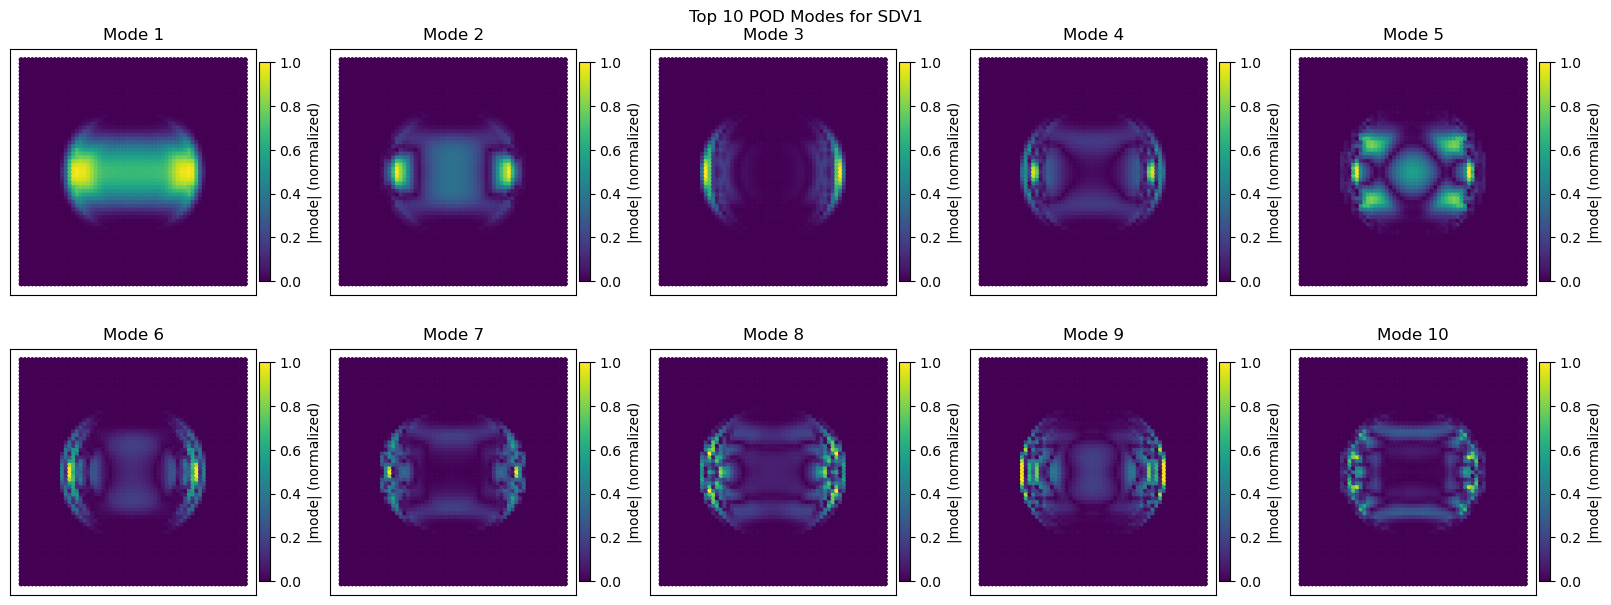

[SDV4] Phi shape: (11163, 10), top σ: [232.16602   58.232243  21.248182  18.450006   9.190696]


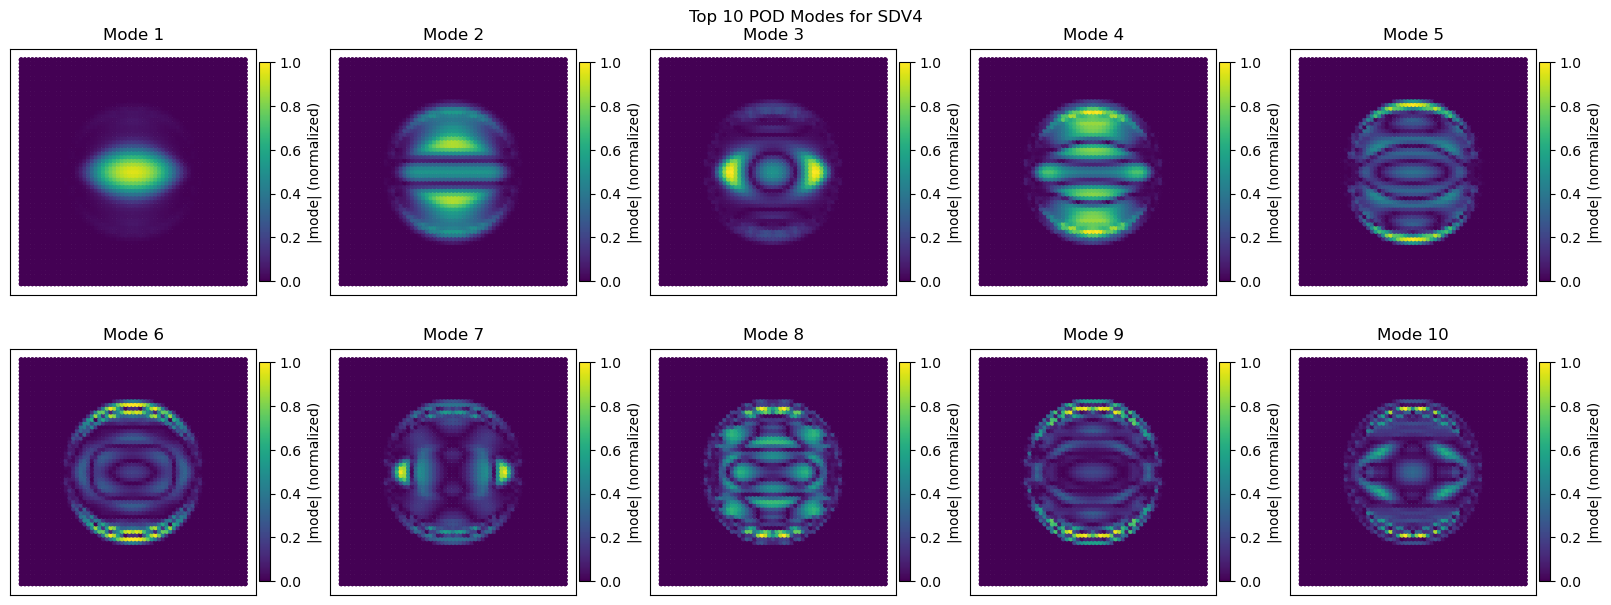

In [27]:
import numpy as np
import zarr
import matplotlib.pyplot as plt

# --- CONFIG ---
ZARR_PATH = "ip_nodal.zarr"             # the store created by build_ip_nodal_zarr_resume
NODES_CSV_PATH = r"GOH_Nodes_Test_for_Visualization.csv"
FIELDS = ("SDV1", "SDV4")
N_MODES_TO_PLOT = 10

# --- load geometry ---
coords_all = np.genfromtxt(NODES_CSV_PATH, delimiter=",", dtype=float)
ids_all = coords_all[:, 0].astype(int)
xyz_all = coords_all[:, 1:4]
id_to_idx = {nid: i for i, nid in enumerate(ids_all)}

# --- open Zarr ---
g = zarr.open_group(ZARR_PATH, mode="r")
labels = g["meta"]["node_labels"][:]
N = len(labels)

# --- reorder coordinates to match snapshot node order ---
xyz = np.vstack([xyz_all[id_to_idx[nid]] for nid in labels])
x, y, z = xyz.T

# --- helper: plotting function ---
def plot_modes_for_field(field):
    pg = g[f"pod_{field}"]
    Phi = np.asarray(pg["Phi"][:, :N_MODES_TO_PLOT])  # (N, n_modes)
    svals = pg["svals"][:]
    print(f"[{field}] Phi shape: {Phi.shape}, top σ: {svals[:5]}")

    n_plot = min(N_MODES_TO_PLOT, Phi.shape[1])
    ncols = 5
    nrows = int(np.ceil(n_plot / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 6), constrained_layout=True)
    axes = axes.ravel()

    for i in range(n_plot):
        mode = Phi[:, i]
        mag = np.abs(mode)
        vmax = mag.max() if mag.size else 1.0
        c = mag / (vmax + 1e-12)

        sc = axes[i].scatter(x, y, c=c, s=6, cmap="viridis")
        axes[i].set_title(f"Mode {i+1}")
        axes[i].set_aspect("equal", adjustable="box")
        axes[i].set_xticks([]); axes[i].set_yticks([])
        cb = plt.colorbar(sc, ax=axes[i], shrink=0.75, pad=0.01)
        cb.set_label("|mode| (normalized)")

    for j in range(n_plot, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"Top {n_plot} POD Modes for {field}", y=1.02)
    fig.savefig(f"Lambda_g_{f} modes.png", transparent=True, dpi=300)
    plt.show()

# --- plot both fields ---
for f in FIELDS:
    plot_modes_for_field(f)

[SDV1] Total modes: 100 | Modes for 95%: 3, for 99%: 9


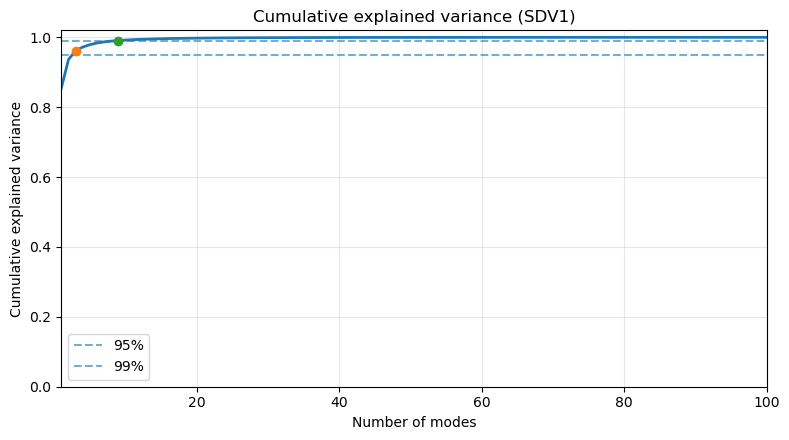

[SDV4] Total modes: 100 | Modes for 95%: 2, for 99%: 4


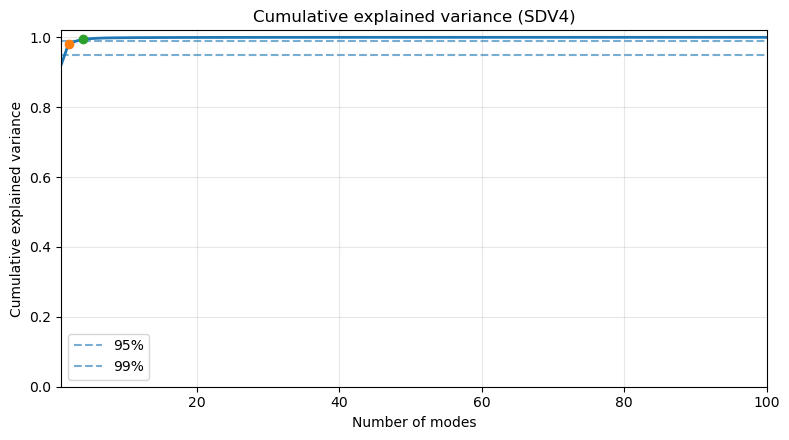

In [29]:
import numpy as np
import zarr
import matplotlib.pyplot as plt

# --- CONFIG ---
ZARR_PATH = "ip_nodal.zarr"
FIELDS = ("SDV1", "SDV4")
N_MODES_TO_PLOT = 100

# --- open Zarr group ---
g = zarr.open_group(ZARR_PATH, mode="r")

# --- helper: cumulative variance plot ---
def plot_cumulative_variance(field):
    pg = g[f"pod_{field}"]
    svals = pg["svals"][:]  # shape (r,)
    r_saved = len(svals)

    # Explained variance from singular values (energy ~ s^2)
    energy = svals**2
    energy_total = energy.sum()
    var_ratio = energy / energy_total
    cum_var = np.cumsum(var_ratio)

    # Threshold functions
    def modes_for(thresh):
        idx = np.searchsorted(cum_var, thresh) + 1
        return int(min(idx, r_saved))

    r95 = modes_for(0.95)
    r99 = modes_for(0.99)
    r_plot = min(N_MODES_TO_PLOT, r_saved)

    print(f"[{field}] Total modes: {r_saved} | Modes for 95%: {r95}, for 99%: {r99}")

    # Plot cumulative explained variance
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(np.arange(1, r_plot+1), cum_var[:r_plot], lw=2)
    ax.axhline(0.95, ls="--", alpha=0.6, label="95%")
    ax.axhline(0.99, ls="--", alpha=0.6, label="99%")
    if r95 <= r_plot:
        ax.plot(r95, cum_var[r95-1], "o")
    if r99 <= r_plot:
        ax.plot(r99, cum_var[r99-1], "o")
    ax.set_xlim(1, r_plot)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("Number of modes")
    ax.set_ylabel("Cumulative explained variance")
    ax.set_title(f"Cumulative explained variance ({field})")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(f"cumulative_var_{field}.png", transparent=True, dpi=300)
    plt.show()

# --- plot for each field ---
for f in FIELDS:
    plot_cumulative_variance(f)


## Build Lamg snapshots directly at the int pts

In [134]:
def _create_or_overwrite_array(g, name, data, dtype):
    """Delete if exists, then create and fill (works on Zarr v2/v3)."""
    if name in g:
        del g[name]
    arr = None
    # Try v3-style create_array(shape=...) then assign
    try:
        arr = g.create_array(name, shape=data.shape, chunks=data.shape, dtype=dtype)
        arr[:] = data
        return arr
    except TypeError:
        pass
    # Fallback to v2-style create_dataset(data=...)
    try:
        arr = g.create_dataset(name, data=data, chunks=data.shape, dtype=dtype)
        return arr
    except Exception as e:
        # Last resort: require_array then fill
        arr = g.require_dataset(name, shape=data.shape, chunks=data.shape, dtype=dtype)
        arr[:] = data
        return arr

In [138]:
import numpy as np, zarr

def _create_or_overwrite_array(g, name, data, dtype):
    """Delete if exists, then create and fill (Zarr v2/v3 safe)."""
    if name in g:
        del g[name]
    arr = None
    # Try v3-style create_array -> assign
    try:
        arr = g.create_array(name, shape=data.shape, chunks=data.shape, dtype=dtype)
        arr[:] = data
        return arr
    except TypeError:
        pass
    # Fallback to v2-style create_dataset(data=...)
    try:
        arr = g.create_dataset(name, data=data, chunks=data.shape, dtype=dtype)
        return arr
    except Exception:
        # Last resort: require_dataset then fill
        arr = g.require_dataset(name, shape=data.shape, chunks=data.shape, dtype=dtype)
        arr[:] = data
        return arr

def ensure_meta_arrays(mg, mapping, allow_overwrite=False):
    """
    Ensure required meta arrays exist and match. 
    mapping: {name: (data_ndarray, dtype_str)}
    """
    for name, (data, dtype) in mapping.items():
        if name not in mg:
            _create_or_overwrite_array(mg, name, np.asarray(data), dtype)
            print(f"[meta] created: {name} shape={data.shape}")
        else:
            old = np.asarray(mg[name])
            if old.shape != data.shape or not np.array_equal(old, data):
                if allow_overwrite:
                    _create_or_overwrite_array(mg, name, np.asarray(data), dtype)
                    print(f"[meta] overwrote: {name} (shape/content differed)")
                else:
                    raise ValueError(
                        f"[meta] '{name}' differs from current store. "
                        f"Existing shape={old.shape}, new shape={data.shape}. "
                        f"Set allow_overwrite=True to replace."
                    )

In [139]:
import numpy as np, pandas as pd, zarr, glob, re, time
from numpy.linalg import norm
from pathlib import Path
from typing import Iterator, Tuple, Optional, List

# ----------------------------- USER CONFIG -----------------------------
NODES_CSV_PATH = r"GOH_Nodes_Test_for_Visualization.csv"     # id,x,y,z (FULL mesh)
ELEMS_CSV_PATH = r"GOH_Elements_Test_for_Visualization.csv"  # elemLabel,n1..n8
CSV_GLOB       = r"PATH_TO_YOUR_RAW_FE_OUTPUT_FOLDER\GOH_Job*_combined_data.csv"  # <-- set this to your local copy; see data_processing/README.md

ZARR_PATH      = "Lamg_int_pts"   # <-- requested output store name
GLOBAL_NORMAL  = np.array([0,0,-1], dtype=float)  # outward normal of bottom surface
GAUSS_A        = 1.0/np.sqrt(3.0)                 # 2x2x2 rule
CHECKPOINT_EVERY = 10
DTYPE_OUT      = "f4"
# -----------------------------------------------------------------------

# ---------------------------- GEOMETRY HELPERS -------------------------
def hex8_shape_functions(xi, eta, zeta):
    local = np.array([
        [-1, -1, -1],
        [ 1, -1, -1],
        [ 1,  1, -1],
        [-1,  1, -1],
        [-1, -1,  1],
        [ 1, -1,  1],
        [ 1,  1,  1],
        [-1,  1,  1],
    ], dtype=float)
    N = 0.125*(1 + local[:,0]*xi)*(1 + local[:,1]*eta)*(1 + local[:,2]*zeta)
    return N  # (8,)

def gauss_points_hex8(a=GAUSS_A):
    # (xi, eta, zeta) in the ORDER we’ll also use to compute ip positions
    return [(-a,-a,-a),(+a,-a,-a),(+a,+a,-a),(-a,+a,-a),
            (-a,-a,+a),(+a,-a,+a),(+a,+a,+a),(-a,+a,+a)]

def q4_shape(xi, eta):
    N = 0.25*np.array([(1-xi)*(1-eta),
                       (1+xi)*(1-eta),
                       (1+xi)*(1+eta),
                       (1-xi)*(1+eta)], dtype=float)
    dN_dxi  = 0.25*np.array([-(1-eta), (1-eta), (1+eta), -(1+eta)])
    dN_deta = 0.25*np.array([-(1-xi), -(1+xi), (1+xi),   (1-xi)])
    return N, dN_dxi, dN_deta

def gauss_points_2x2_face(a=GAUSS_A):
    return [(-a,-a),(+a,-a),(+a,+a),(-a,+a)]

def face_node_sets_hex8():
    return [
        [0,1,2,3],  # "bottom" (-z in usual local orientation)
        [4,5,6,7],  # top
        [0,1,5,4],
        [1,2,6,5],
        [2,3,7,6],
        [3,0,4,7],
    ]

def pick_bottom_face(nodes_xyz_elem, prefer_normal):
    """Return local indices (length 4) of the face with smallest mean projection."""
    faces = face_node_sets_hex8()
    n = prefer_normal / (norm(prefer_normal)+1e-12)
    best_f, best_proj = None, +np.inf
    for f in faces:
        pts = nodes_xyz_elem[f, :]
        proj = (pts @ n).mean()
        if proj < best_proj:
            best_proj, best_f = proj, f
    # impose CCW order in-plane for stability
    X4 = nodes_xyz_elem[best_f, :]
    c  = X4.mean(axis=0)
    u  = X4[1]-X4[0]; u -= (u@n)*n
    if norm(u) < 1e-12:
        u = X4[2]-X4[0]; u -= (u@n)*n
    u /= (norm(u)+1e-12)
    v  = np.cross(n, u)
    ang = np.arctan2(((X4-c)@v), ((X4-c)@u))
    order = np.argsort(ang)
    return [best_f[i] for i in order]

def compute_ip_positions_ref(X_all, elem_conn):
    """Physical positions of all 8 IPs for every element in reference config."""
    Ne = elem_conn.shape[0]
    gps = gauss_points_hex8()
    ip_pos = np.zeros((Ne*8, 3), dtype=float)
    for e in range(Ne):
        X = X_all[elem_conn[e], :]  # (8,3)
        for k,(xi,eta,z) in enumerate(gps, start=1):
            N8 = hex8_shape_functions(xi, eta, z)[:,None]  # (8,1)
            ip_pos[e*8 + (k-1), :] = (N8 * X).sum(axis=0)
    return ip_pos  # (Ne*8,3)

def map_bottom_face_ips(elem_nodes_xyz, ip_pos_elem, prefer_normal):
    """
    For one element:
      - pick bottom face (via prefer_normal)
      - compute 4 face Gauss-point positions (reference)
      - for each GP, choose the nearest of the element's 8 IP positions
    Return the 4 local ip indices (0..7) matched to face GPs.
    """
    # 1) bottom face nodes
    face_locals = pick_bottom_face(elem_nodes_xyz, prefer_normal)
    Xf = elem_nodes_xyz[face_locals, :]  # (4,3)

    # 2) 4 face GP positions (reference)
    face_gps = gauss_points_2x2_face()
    face_gp_ref = []
    for (xi,eta) in face_gps:
        Nf, _, _ = q4_shape(xi, eta)
        X_gp = (Nf[:,None] * Xf).sum(axis=0)
        face_gp_ref.append(X_gp)
    face_gp_ref = np.array(face_gp_ref)  # (4,3)

    # 3) nearest among the 8 element IP positions
    # ip_pos_elem: (8,3)
    d2 = ((face_gp_ref[:,None,:] - ip_pos_elem[None,:,:])**2).sum(axis=2)  # (4,8)
    gp_to_ip_local = np.argmin(d2, axis=1)  # (4,)
    return gp_to_ip_local.tolist()
# -----------------------------------------------------------------------

# --------------------------- CSV FRAME PARSER --------------------------
FRAME_RE = re.compile(r"^###\s*Frame Time:\s*([0-9.+-Ee]+)\s*###")
SECTION_IP = "=== INTEGRATION POINT DATA ==="

def iter_ip_frames(csv_path: str) -> Iterator[Tuple[float, pd.DataFrame]]:
    """
    Yields (time, df) per frame for the INTEGRATION POINT DATA table.
    df columns must include: ElemLabel, IPIndex, SDV1, SDV4 (others ignored).
    """
    with open(csv_path, "r", encoding="utf-8", errors="ignore") as f:
        push: Optional[str] = None
        def rdline() -> Optional[str]:
            nonlocal push
            if push is not None:
                s = push; push = None; return s
            s = f.readline()
            return s if s != "" else None
        def unread(s: str):
            nonlocal push
            push = s

        while True:
            line = rdline()
            if line is None: return
            m = FRAME_RE.match(line)
            if not m:
                continue
            tval = float(m.group(1))
            # skip next line (CVOL ...)
            _ = rdline()

            # find IP section
            while True:
                line = rdline()
                if line is None: return
                if line.strip() == SECTION_IP:
                    break

            header = rdline()
            if header is None: return
            cols = [c.strip() for c in header.strip().split(",")]
            # read rows until next section or next frame
            recs = []
            while True:
                line = rdline()
                if line is None:
                    break
                s = line.strip()
                if (not s) or s.startswith("===") or s.startswith("### Frame Time:"):
                    unread(line)
                    break
                parts = [p.strip() for p in s.split(",")]
                if len(parts) < len(cols):
                    continue
                recs.append(parts)
            if recs:
                df = pd.DataFrame(recs, columns=cols)
                # keep only the columns we need, coerce types
                need = ["ElemLabel","IPIndex","SDV1","SDV4"]
                keep = [c for c in need if c in df.columns]
                df = df[keep].copy()
                for c in ["ElemLabel","IPIndex"]:
                    df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int64")
                for c in ["SDV1","SDV4"]:
                    df[c] = pd.to_numeric(df[c], errors="coerce")
                df = df.dropna(subset=["ElemLabel","IPIndex"]).astype({"ElemLabel":int,"IPIndex":int})
                yield tval, df
# -----------------------------------------------------------------------

# -------------------------- RESUME-SAFE BUILDER ------------------------
def build_growth_bottomip_zarr_resume(
    csv_glob_or_list,
    nodes_csv: str,
    elems_csv: str,
    zarr_path: str = "Lamg_int_pts",
    prefer_normal: np.ndarray = GLOBAL_NORMAL,
    dtype_out: str = DTYPE_OUT,
    checkpoint_every: int = CHECKPOINT_EVERY,
):
    """
    Extract SDV1, SDV4 at bottom-surface integration points (4 per HEX8 element),
    resume-safe across files/frames, and save to Zarr:
      - meta/bottom_flat_indices, meta/bottom_elem_labels, meta/bottom_ipindex
      - snaps_SDV1_bottom: (Ne*4, S)
      - snaps_SDV4_bottom: (Ne*4, S)
      - times: (S,)

    Assumes element set/connectivity is fixed across frames.
    """

    # ---- normalize file list
    if isinstance(csv_glob_or_list, (list, tuple)):
        files = [str(p) for p in csv_glob_or_list]
    else:
        files = sorted(glob.glob(csv_glob_or_list))
    if not files:
        raise FileNotFoundError(f"No files matched: {csv_glob_or_list}")

    # ---- load full mesh & connectivity
    nodes_df = pd.read_csv(nodes_csv, header=None, names=["id","x","y","z"])
    node_ids = nodes_df["id"].to_numpy(int)
    X_all    = nodes_df[["x","y","z"]].to_numpy(float)
    id2row   = {int(n): i for i,n in enumerate(node_ids)}

    elems_df = pd.read_csv(elems_csv, header=None)
    elem_labels = elems_df.iloc[:,0].to_numpy(int)          # (Ne,)
    elem_node_ids = elems_df.iloc[:,1:9].to_numpy(int)      # (Ne,8)
    Ne = elem_node_ids.shape[0]
    # 0-based connectivity
    elem_conn = np.vectorize(id2row.get)(elem_node_ids)     # (Ne,8)

    # ---- precompute ALL 8 IP positions (reference) for every element
    ip_pos_ref = compute_ip_positions_ref(X_all, elem_conn)  # (Ne*8,3)

    # ---- build bottom-4 per element (local IP indices -> global flat indices)
    prefer_normal = prefer_normal / (norm(prefer_normal)+1e-12)
    p_hex = gauss_points_hex8()  # just to have consistent length 8

    bottom_local = []
    for e in range(Ne):
        nodes_xyz = X_all[elem_conn[e], :]          # (8,3)
        ip_pos_e  = ip_pos_ref[e*8:(e+1)*8, :]      # (8,3)
        loc4 = map_bottom_face_ips(nodes_xyz, ip_pos_e, prefer_normal)  # 4 local ip ids
        bottom_local.append(loc4)

    bottom_local = np.array(bottom_local, dtype=int)       # (Ne,4)
    bottom_flat  = (np.arange(Ne)[:,None]*8 + bottom_local).reshape(-1)  # (Ne*4,)
    bottom_ipidx = (bottom_local + 1).reshape(-1)          # Abaqus 1..8
    bottom_elabs = np.repeat(elem_labels, 4)

    # ---- map (ElemLabel, IPIndex) -> flat index for fast fills
    elemip_to_flat = {(int(l), int(ip)): (e*8 + (ip-1))
                      for e,l in enumerate(elem_labels) for ip in range(1,9)}

    g = zarr.open_group(zarr_path, mode="a")
    mg = g.require_group("meta")
    
    required_meta = {
        "elem_labels":          (elem_labels.astype("i8"), "i8"),
        "bottom_flat_indices":  (bottom_flat.astype("i8"), "i8"),
        "bottom_elem_labels":   (bottom_elabs.astype("i8"), "i8"),
        "bottom_ipindex":       (bottom_ipidx.astype("i8"), "i8"),
    }
    
    # If you want to strictly verify and fail on mismatch:
    ensure_meta_arrays(mg, required_meta, allow_overwrite=False)


    # data arrays
    S_total_ckpt = int(g.attrs.get("S_total", 0))
    snaps1 = g.get("snaps_SDV1_bottom", None)
    snaps4 = g.get("snaps_SDV4_bottom", None)
    times  = g.get("times", None)

    if snaps1 is None or snaps4 is None or times is None:
        # fresh create
        if "snaps_SDV1_bottom" in g: del g["snaps_SDV1_bottom"]
        if "snaps_SDV4_bottom" in g: del g["snaps_SDV4_bottom"]
        if "times" in g:            del g["times"]
        snaps1 = g.create_array("snaps_SDV1_bottom", shape=(Ne*4, 0),
                                chunks=(min(Ne*4, 65536), 64), dtype=dtype_out)
        snaps4 = g.create_array("snaps_SDV4_bottom", shape=(Ne*4, 0),
                                chunks=(min(Ne*4, 65536), 64), dtype=dtype_out)
        times  = g.create_array("times", shape=(0,), chunks=(256,), dtype="f4")
        S_total_ckpt = 0

    # resume state: which file/frame to start from?
    ckpt = g.attrs.get("checkpoint", {"file_idx": 0, "frame_idx": 0})
    file_start = int(ckpt.get("file_idx", 0))
    frame_start_for_first = int(ckpt.get("frame_idx", 0))
    S = int(S_total_ckpt)

    wrote_any = False
    t0 = time.time()

    for i in range(file_start, len(files)):
        fp = files[i]
        frame_counter = 0
        for tval, df in iter_ip_frames(fp):
            # skip frames already written in this file (resume)
            if i == file_start and frame_counter < frame_start_for_first:
                frame_counter += 1
                continue

            # Build dense arrays (Ne*8) for SDV1/SDV4, then pick bottom_flat (Ne*4)
            n_total_ip = Ne*8
            A1 = np.zeros((n_total_ip,), dtype=np.float64)
            A4 = np.zeros((n_total_ip,), dtype=np.float64)

            # vectorized mapping to flat indices
            lab  = df["ElemLabel"].to_numpy(int)
            ipix = df["IPIndex"].to_numpy(int)
            flats = np.fromiter((elemip_to_flat.get((int(l), int(ii)), -1) for l,ii in zip(lab, ipix)),
                                dtype=np.int64, count=lab.size)
            valid = flats >= 0
            A1[flats[valid]] = df.loc[valid, "SDV1"].to_numpy(float)
            A4[flats[valid]] = df.loc[valid, "SDV4"].to_numpy(float)

            # slice to bottom (Ne*4)
            B1 = A1[bottom_flat].astype(dtype_out, copy=False)
            B4 = A4[bottom_flat].astype(dtype_out, copy=False)

            # append snapshot column
            snaps1.resize((Ne*4, S+1))
            snaps4.resize((Ne*4, S+1))
            times.resize((S+1,))
            snaps1[:, S] = B1
            snaps4[:, S] = B4
            times[S]     = np.float32(tval)
            S += 1
            frame_counter += 1
            wrote_any = True

            if (S % checkpoint_every) == 0:
                g.attrs["checkpoint"] = {"file_idx": i, "frame_idx": frame_counter}
                g.attrs["S_total"]    = S
                print(f"[checkpoint] Written {S} snapshots so far (file {i+1}/{len(files)})")

        # file boundary checkpoint
        g.attrs["checkpoint"] = {"file_idx": i+1, "frame_idx": 0}
        g.attrs["S_total"]    = S

    # final
    elapsed = time.time() - t0
    print(("Appended" if wrote_any else "Nothing to append") +
          f". Total snapshots now: {S}. Elapsed {elapsed:.2f}s")
    return zarr.open_group(zarr_path, mode="r")

# ------------------------------ RUN IT ---------------------------------
_ = build_growth_bottomip_zarr_resume(
    CSV_GLOB,
    nodes_csv=NODES_CSV_PATH,
    elems_csv=ELEMS_CSV_PATH,
    zarr_path=ZARR_PATH,
    prefer_normal=GLOBAL_NORMAL,
    dtype_out=DTYPE_OUT,
    checkpoint_every=CHECKPOINT_EVERY,
)


[meta] created: elem_labels shape=(7200,)
[meta] created: bottom_flat_indices shape=(28800,)
[meta] created: bottom_elem_labels shape=(28800,)
[meta] created: bottom_ipindex shape=(28800,)
[checkpoint] Written 10 snapshots so far (file 1/928)
[checkpoint] Written 20 snapshots so far (file 1/928)
[checkpoint] Written 30 snapshots so far (file 1/928)
[checkpoint] Written 40 snapshots so far (file 1/928)
[checkpoint] Written 50 snapshots so far (file 1/928)
[checkpoint] Written 60 snapshots so far (file 1/928)
[checkpoint] Written 70 snapshots so far (file 2/928)
[checkpoint] Written 80 snapshots so far (file 2/928)
[checkpoint] Written 90 snapshots so far (file 2/928)
[checkpoint] Written 100 snapshots so far (file 2/928)
[checkpoint] Written 110 snapshots so far (file 2/928)
[checkpoint] Written 120 snapshots so far (file 2/928)
[checkpoint] Written 130 snapshots so far (file 2/928)
[checkpoint] Written 140 snapshots so far (file 3/928)
[checkpoint] Written 150 snapshots so far (file 3/

KeyboardInterrupt: 

## Build PK2 stress snapshots at the int pts (Voigt notation)

In [91]:
import re, time, glob
import numpy as np
import pandas as pd
import zarr

# ---------- config ----------
N_CHECKPOINT = 50
DTYPE_SNAP   = "f4"
CHUNK_COLS   = 16_384
# ---------------------------

# ========== mesh → IP geometry ==========
def hex8_shape_functions(xi, eta, zeta):
    local = np.array([
        [-1, -1, -1],
        [ 1, -1, -1],
        [ 1,  1, -1],
        [-1,  1, -1],
        [-1, -1,  1],
        [ 1, -1,  1],
        [ 1,  1,  1],
        [-1,  1,  1],
    ], dtype=float)
    N = 0.125 * (1 + local[:,0]*xi) * (1 + local[:,1]*eta) * (1 + local[:,2]*zeta)
    return N

def gauss_points_2x2x2(a=1.0/np.sqrt(3.0)):
    # keep an explicit fixed order (1..8)
    return [(-a,-a,-a),(+a,-a,-a),(+a,+a,-a),(-a,+a,-a),
            (-a,-a,+a),(+a,-a,+a),(+a,+a,+a),(-a,+a,+a)]

def compute_ip_positions_hex8(node_coords, elem_conn, gauss_pts=None):
    """
    node_coords: (Nnodes,3)
    elem_conn:   (Ne,8) with node indices (0-based) into node_coords
    returns ip_positions: (Ne*8,3)
    """
    if gauss_pts is None:
        gauss_pts = gauss_points_2x2x2()
    Ne = elem_conn.shape[0]
    ip_positions = np.zeros((Ne*8, 3), dtype=float)
    for e in range(Ne):
        X = node_coords[elem_conn[e]]  # (8,3)
        for ip_i, (xi,eta,zeta) in enumerate(gauss_pts, start=1):
            N = hex8_shape_functions(xi,eta,zeta)[:,None]  # (8,1)
            flat = e*8 + (ip_i-1)
            ip_positions[flat,:] = (N*X).sum(axis=0)
    return ip_positions

def build_elemip_index(elem_labels, ip_per_elem=8):
    """(ElemLabel, IPIndex) -> flat ip index (0..Ne*8-1)"""
    m = {}
    for e, lab in enumerate(elem_labels):
        lab = int(lab)
        for ip in range(1, ip_per_elem+1):
            m[(lab, ip)] = e*ip_per_elem + (ip-1)
    return m

def select_bottom_ips_per_element(ip_positions, elem_labels, ip_per_elem=8, normal=None):
    """
    For each element, choose the 4 IPs on the 'bottom' layer:
      - If normal is None: pick the 4 smallest global z.
      - Else: pick 4 with smallest projection along `normal` (closest in the -normal direction).
    Returns:
      bottom_flats: (Ne*4,) flat IP indices in a frozen order (per-element groups of 4)
      bottom_pairs: array [(ElemLabel, IPIndex)] aligned with bottom_flats
    """
    Ne = len(elem_labels)
    if normal is None:
        proj = ip_positions[:,2]  # use z
    else:
        n = np.asarray(normal, float)
        n /= (np.linalg.norm(n) + 1e-12)
        proj = ip_positions @ n   # scalar projection along n

    bottom_flats = []
    bottom_pairs = []

    # Recover which IPIndex (1..8) each flat corresponds to
    # flat = e*8 + (ip-1)  => ip = (flat - e*8) + 1
    for e, lab in enumerate(elem_labels):
        start = e*ip_per_elem
        end   = start + ip_per_elem
        flats_e = np.arange(start, end)
        # pick 4 with smallest projection
        order = np.argsort(proj[flats_e])[:4]
        kept = flats_e[order]
        bottom_flats.extend(kept.tolist())
        for flat in kept:
            ip_idx = (flat - start) + 1  # back to 1..8
            bottom_pairs.append((int(lab), int(ip_idx)))

    return np.asarray(bottom_flats, dtype=int), np.asarray(bottom_pairs, dtype=np.int64)

# ========== CSV frame iterator (IP section) ==========
FRAME_RE       = re.compile(r"^###\s*Frame Time:\s*([0-9.+\-Ee]+)\s*###")
SECTION_IP_RE  = re.compile(r"^=+\s*INTEGRATION\s+POINT\s+DATA\s*=+$", re.I)

def iter_ip_frames(csv_path, fields=("SDV22","SDV23","SDV24","SDV25","SDV26","SDV27")):
    """Yield (time, df) for each frame's IP table (with ElemLabel, IPIndex, and requested fields)."""
    with open(csv_path, "r", encoding="utf-8", errors="ignore") as f:
        push = None
        def readline():
            nonlocal push
            if push is not None:
                s = push; push = None; return s
            s = f.readline()
            return s if s != "" else None
        def unread(s):
            nonlocal push
            push = s

        while True:
            line = readline()
            if line is None:
                return
            m = FRAME_RE.match(line)
            if not m:
                continue
            t = float(m.group(1))
            _ = readline()  # skip CVOL line

            # advance to section
            while True:
                line = readline()
                if line is None:
                    return
                if SECTION_IP_RE.match(line.strip()):
                    break

            header = readline()
            if header is None:
                return
            cols = [c.strip() for c in header.strip().split(",")]

            rows = []
            while True:
                line = readline()
                if line is None:
                    break
                s = line.strip()
                if (not s) or s.startswith("===") or s.startswith("### Frame Time:"):
                    unread(line); break
                rows.append(s.split(","))

            if not rows:
                continue

            df = pd.DataFrame(rows, columns=cols)
            need = ["ElemLabel","IPIndex", *fields]
            miss = [c for c in need if c not in df.columns]
            if miss:
                raise ValueError(f"Missing columns {miss} in {csv_path}")

            df["ElemLabel"] = df["ElemLabel"].astype(int)
            df["IPIndex"]   = df["IPIndex"].astype(int)
            for c in fields:
                df[c] = df[c].astype(float)
            yield t, df

# ========== dense vectorizer on the kept bottom IPs ==========
def vectorize_pk2_bottom(df_ip, elemip_to_flat, kept_flat_indices, kept_pairs):
    """
    Build a (6 * N_kept,) vector in Voigt order per kept IP:
      [11,22,33,12,13,23] mapped from [SDV22..SDV27].
    kept_flat_indices: (N_kept,) flats we keep (defines ordering)
    kept_pairs:        (N_kept,2) [(ElemLabel, IPIndex)] aligned with `kept_flat_indices`
    """
    n_kept = kept_flat_indices.size
    # map (ElemLabel,IPIndex) to kept index (0..n_kept-1)
    # via flat index: (lab,ip) -> flat -> pos
    flat_to_pos = {int(f): i for i, f in enumerate(kept_flat_indices)}

    # rows → flat indices
    flats = df_ip.apply(lambda r: elemip_to_flat.get((int(r["ElemLabel"]), int(r["IPIndex"])), -1), axis=1).to_numpy()
    valid = flats >= 0
    dfv = df_ip.loc[valid]
    flats = flats[valid]

    # gather only those rows that correspond to kept flats
    pos = np.array([flat_to_pos.get(int(f), -1) for f in flats], dtype=int)
    take = pos >= 0
    if not np.any(take):
        # No bottom IPs present in this frame (unlikely) → return zeros
        return np.zeros((n_kept*6,), dtype=np.float32)

    pos = pos[take]
    dfv = dfv.iloc[take]

    # prepare component arrays
    comp = np.zeros((n_kept, 6), dtype=np.float32)
    # Voigt order mapping: SDV22..SDV27 → [11,22,33,12,13,23]
    comp[pos, 0] = dfv["SDV22"].to_numpy(dtype=np.float32)  # 11
    comp[pos, 1] = dfv["SDV23"].to_numpy(dtype=np.float32)  # 22
    comp[pos, 2] = dfv["SDV24"].to_numpy(dtype=np.float32)  # 33
    comp[pos, 3] = dfv["SDV25"].to_numpy(dtype=np.float32)  # 12
    comp[pos, 4] = dfv["SDV26"].to_numpy(dtype=np.float32)  # 13
    comp[pos, 5] = dfv["SDV27"].to_numpy(dtype=np.float32)  # 23

    return comp.reshape(-1)

# ========== zarr helpers ==========
def _require_array(g, name, shape, chunks, dtype):
    try:
        return g[name]
    except KeyError:
        pass
    try:
        return g.require_array(name, shape=shape, chunks=chunks, dtype=dtype)  # zarr v3
    except TypeError:
        return g.require_dataset(name, shape=shape, chunks=chunks, dtype=dtype)  # zarr v2

# ========== main builder ==========
def build_pk2_bottom_ip_zarr_resume(
    csv_list_or_glob,
    zarr_path: str,
    *,
    node_coords: np.ndarray,
    elem_conn: np.ndarray,      # (Ne,8) 0-based node indices
    elem_labels: np.ndarray,    # (Ne,) Abaqus labels (1-based)
    normal=None,                # e.g., (0,0,1) to pick “lowest along +z”; None → use z
    chunks_snap: int = CHUNK_COLS,
    dtype_snap: str = DTYPE_SNAP,
    checkpoint_every: int = N_CHECKPOINT,
):
    """
    Extract PK2 at integration points but keep ONLY bottom-surface IPs (4 per element),
    no node mapping. Stores a dense snapshot matrix with rows = 6 * (Ne*4).
    Also saves a meta mapping so each row-block maps back to (ElemLabel, IPIndex).
    """
    # Resolve files
    if isinstance(csv_list_or_glob, (list, tuple)):
        files = [str(p) for p in csv_list_or_glob]
    else:
        files = sorted(glob.glob(csv_list_or_glob))
    if not files:
        raise FileNotFoundError(f"No files found for {csv_list_or_glob}")

    # Precompute IP positions and bottom selection
    ip_pos   = compute_ip_positions_hex8(node_coords, elem_conn)
    kept_flats, kept_pairs = select_bottom_ips_per_element(ip_pos, elem_labels, ip_per_elem=8, normal=normal)
    n_kept = kept_flats.size                # = Ne * 4
    n_rows = 6 * n_kept

    elemip_to_flat = build_elemip_index(elem_labels, ip_per_elem=8)

    g  = zarr.open_group(zarr_path, mode="a")
    mg = g.require_group("meta")

    # Save meta (once)
    mg.attrs["description"] = "PK2 Voigt snapshots at bottom 2x2 Gauss layer (no node mapping)"
    mg.attrs["voigt_order"] = ["11","22","33","12","13","23"]
    mg.attrs["kept_per_elem"] = 4
    mg.attrs["ip_per_elem"] = 8

    # Keep explicit mapping arrays (aligned with row blocks)
    # For each kept IP there are 6 rows in the snapshot matrix in this order.
    if "bottom_flat_indices" in mg: del mg["bottom_flat_indices"]
    if "bottom_elem_labels"  in mg: del mg["bottom_elem_labels"]
    if "bottom_ipindex"      in mg: del mg["bottom_ipindex"]
    mg.create_array("bottom_flat_indices", shape=(n_kept,), dtype="i8")[:] = kept_flats
    mg.create_array("bottom_elem_labels",  shape=(n_kept,), dtype="i8")[:] = kept_pairs[:,0]
    mg.create_array("bottom_ipindex",      shape=(n_kept,), dtype="i8")[:] = kept_pairs[:,1]

    # Resume checkpoint
    ckpt = g.attrs.get("checkpoint", {"file_idx": 0, "frame_idx": 0, "S_total": 0})
    file_start = int(ckpt.get("file_idx", 0))
    frame_start_for_first = int(ckpt.get("frame_idx", 0))
    S_total = int(ckpt.get("S_total", 0))

    # Arrays
    snaps = g.get("snaps_PK2_bottom", None)
    times = g.get("times", None)
    if snaps is None:
        snaps = _require_array(
            g, "snaps_PK2_bottom",
            shape=(n_rows, 0),
            chunks=(min(n_rows, chunks_snap), chunks_snap),
            dtype=dtype_snap
        )
    if times is None:
        times = _require_array(g, "times", shape=(0,), chunks=(chunks_snap,), dtype="f4")

    # Trim to checkpoint sizes (if needed)
    if S_total > 0:
        _, S_exist = snaps.shape
        if S_exist != S_total:
            snaps.resize((snaps.shape[0], S_total))
            times.resize((S_total,))

    print(f"[info] PK2-bottom extraction: files={len(files)}  kept_ips={n_kept}  rows={n_rows}")
    wrote_any = False

    for i in range(file_start, len(files)):
        fp = files[i]
        frame_counter = 0
        for t, df_ip in iter_ip_frames(fp, fields=("SDV22","SDV23","SDV24","SDV25","SDV26","SDV27")):
            if i == file_start and frame_counter < frame_start_for_first:
                frame_counter += 1
                continue

            col = vectorize_pk2_bottom(df_ip, elemip_to_flat, kept_flats, kept_pairs)  # (6*n_kept,)
            snaps.resize((n_rows, S_total+1))
            snaps[:, S_total] = col.astype(dtype_snap)

            times.resize((S_total+1,))
            times[S_total] = np.float32(t)

            S_total += 1
            frame_counter += 1
            wrote_any = True

            if checkpoint_every and (S_total % checkpoint_every) == 0:
                g.attrs["checkpoint"] = {"file_idx": i, "frame_idx": frame_counter, "S_total": S_total}
                print(f"[checkpoint] Written {S_total} snapshots so far (file {i+1}/{len(files)})", flush=True)

        g.attrs["checkpoint"] = {"file_idx": i+1, "frame_idx": 0, "S_total": S_total}

    g.attrs["checkpoint"] = {"file_idx": len(files), "frame_idx": 0, "S_total": S_total}
    print(f"[info] Done. Total PK2-bottom snapshots: {S_total}.")

In [94]:
# Pre-existing mesh info you already have:
# node_coords: (Nnodes,3) float
# elem_conn  : (Ne,8) int (0-based indices into node_coords)
# elem_labels: (Ne,)  int (Abaqus labels, 1-based)

build_pk2_bottom_ip_zarr_resume(
    CSV_GLOB,
    zarr_path="pk2_bottom_ip.zarr",
    node_coords=node_coords,
    elem_conn=elem_conn,
    elem_labels=elem_labels,
    normal=None,           # or e.g., (0,0,1) if you prefer a specific global normal
    chunks_snap=16_384,
    dtype_snap="f4",
    checkpoint_every=50
)
# pk2_bottom_ip.zarr/
# ├── snaps_PK2_bottom   (6 * (Ne*4), S)   # Voigt per kept IP, element-major, 4/IPs per element
# ├── times              (S,)
# └── meta/
#     ├── bottom_flat_indices (Ne*4,)      # flat IP index (e*8 + (ip-1)) for each kept slot
#     ├── bottom_elem_labels  (Ne*4,)      # matching ElemLabel for each kept slot
#     └── bottom_ipindex      (Ne*4,)      # matching IPIndex (1..8) for each kept slot
# attrs:
#   checkpoint = {file_idx, frame_idx, S_total}
#   + voigt_order, kept_per_elem, ip_per_elem

[info] PK2-bottom extraction: files=928  kept_ips=28800  rows=172800
[checkpoint] Written 50 snapshots so far (file 1/928)
[checkpoint] Written 100 snapshots so far (file 2/928)
[checkpoint] Written 150 snapshots so far (file 3/928)
[checkpoint] Written 200 snapshots so far (file 4/928)
[checkpoint] Written 250 snapshots so far (file 5/928)
[checkpoint] Written 300 snapshots so far (file 7/928)


KeyboardInterrupt: 

In [283]:
def build_pk2_all_ip_zarr_resume(
    csv_list_or_glob,
    zarr_path: str,
    *,
    node_coords: np.ndarray,     # (Nnodes,3) — kept for API parity; not used here
    elem_conn: np.ndarray,       # (Ne,8)     — kept for API parity; not used here
    elem_labels: np.ndarray,     # (Ne,) Abaqus labels (1-based)
    chunks_snap: int = CHUNK_COLS,
    dtype_snap: str = DTYPE_SNAP,
    checkpoint_every: int = N_CHECKPOINT,
    batch_write: int = 12,        # number of frames to buffer before writing
):
    """
    Extract PK2 at ALL integration points (8 per HEX8 element) into:
        snaps_PK2_all: (6 * (Ne*8), S)
        times:         (S,)
    Meta includes (all_elem_labels, all_ipindex) mapping for flat IP index 0..Ne*8-1.
    Faster version: vectorized label→index, no pandas .apply, batched Zarr writes.
    Requires: `iter_ip_frames(...)` and `_require_array(...)` already defined.
    """
    # -------- resolve files ----------
    if isinstance(csv_list_or_glob, (list, tuple)):
        files = [str(p) for p in csv_list_or_glob]
    else:
        files = sorted(glob.glob(csv_list_or_glob))
    if not files:
        raise FileNotFoundError(f"No files found for {csv_list_or_glob}")

    # -------- mesh / sizes ----------
    Ne = int(elem_conn.shape[0])
    elem_labels = np.asarray(elem_labels, dtype=np.int64)
    assert elem_labels.size == Ne, "elem_labels must match elem_conn.shape[0]"
    ip_per_elem = 8
    n_flats = Ne * ip_per_elem
    n_rows  = 6 * n_flats

    # -------- fast label → element-index map (array-based) ----------
    # We want: given a vector of ElemLabel (int64), return element indices in the *original* order.
    sort_perm = np.argsort(elem_labels)             # indices that sort elem_labels
    labels_sorted = elem_labels[sort_perm]          # sorted labels

    def labels_to_eidx(label_vec: np.ndarray) -> np.ndarray:
        """Map vector of ElemLabel -> element index (−1 if not found)."""
        pos = np.searchsorted(labels_sorted, label_vec)
        ok = (pos >= 0) & (pos < labels_sorted.size)
        ok &= (labels_sorted[np.clip(pos, 0, labels_sorted.size-1)] == label_vec)
        eidx = np.full(label_vec.shape, -1, dtype=np.int64)
        eidx[ok] = sort_perm[pos[ok]]
        return eidx

    # -------- open/create Zarr ----------
    g  = zarr.open_group(zarr_path, mode="a")
    mg = g.require_group("meta")

    # meta
    mg.attrs["description"]  = "PK2 Voigt snapshots at ALL 8 Gauss points per HEX8 element"
    mg.attrs["voigt_order"]  = ["11","22","33","12","13","23"]
    mg.attrs["ip_per_elem"]  = ip_per_elem
    mg.attrs["rows_per_ip"]  = 6
    mg.attrs["order_note"]   = "Row blocks follow element order with IPIndex 1..8 inside each element"

    # mapping arrays aligned with flat IP index 0..Ne*8−1
    if "all_elem_labels" in mg: del mg["all_elem_labels"]
    if "all_ipindex"     in mg: del mg["all_ipindex"]
    mg.create_array("all_elem_labels", shape=(n_flats,), dtype="i8")[:] = np.repeat(elem_labels, ip_per_elem)
    mg.create_array("all_ipindex",     shape=(n_flats,), dtype="i8")[:] = np.tile(np.arange(1, ip_per_elem+1, dtype=np.int64), Ne)

    # resume checkpoint
    ckpt = g.attrs.get("checkpoint", {"file_idx": 0, "frame_idx": 0, "S_total": 0})
    file_start = int(ckpt.get("file_idx", 0))
    frame_start_for_first = int(ckpt.get("frame_idx", 0))
    S_total = int(ckpt.get("S_total", 0))

    # arrays
    snaps = g.get("snaps_PK2_all", None)
    times = g.get("times", None)
    if snaps is None:
        snaps = _require_array(
            g, "snaps_PK2_all",
            shape=(n_rows, 0),
            chunks=(min(n_rows, chunks_snap), chunks_snap),
            dtype=dtype_snap
        )
    if times is None:
        times = _require_array(g, "times", shape=(0,), chunks=(chunks_snap,), dtype="f4")

    # trim to checkpoint sizes if needed
    if S_total > 0:
        _, S_exist = snaps.shape
        if S_exist != S_total:
            snaps.resize((snaps.shape[0], S_total))
            times.resize((S_total,))

    print(f"[info] PK2-all extraction: files={len(files)}  elements={Ne}  flats={n_flats}  rows={n_rows}")

    # -------- fast per-frame vectorizer (no .apply) ----------
    def vectorize_pk2_all_fast(df_ip: pd.DataFrame) -> np.ndarray:
        """
        Dense (6*(Ne*8),) vector in Voigt [11,22,33,12,13,23].
        Missing (label,ip) pairs remain zeros for that frame.
        """
        out = np.zeros((n_flats, 6), dtype=np.float32)

        # columns → numpy (once)
        lab = df_ip["ElemLabel"].to_numpy(np.int64)
        ip  = df_ip["IPIndex"].to_numpy(np.int64)

        eidx = labels_to_eidx(lab)                    # −1 where not found
        valid = (eidx >= 0) & (ip >= 1) & (ip <= ip_per_elem)
        if not np.any(valid):
            return out.ravel()

        e    = eidx[valid]
        ipm1 = ip[valid] - 1
        flats = e * ip_per_elem + ipm1               # flat IP indices

        # gather stress columns (float32) and scatter
        out[flats, 0] = df_ip["SDV22"].to_numpy(np.float32)[valid]  # 11
        out[flats, 1] = df_ip["SDV23"].to_numpy(np.float32)[valid]  # 22
        out[flats, 2] = df_ip["SDV24"].to_numpy(np.float32)[valid]  # 33
        out[flats, 3] = df_ip["SDV25"].to_numpy(np.float32)[valid]  # 12
        out[flats, 4] = df_ip["SDV26"].to_numpy(np.float32)[valid]  # 13
        out[flats, 5] = df_ip["SDV27"].to_numpy(np.float32)[valid]  # 23

        return out.ravel()

    # -------- main I/O loop with batched writes ----------
    for i in range(file_start, len(files)):
        fp = files[i]
        frame_counter = 0
        batch_cols = []
        batch_times = []

        for t, df_ip in iter_ip_frames(fp, fields=("SDV22","SDV23","SDV24","SDV25","SDV26","SDV27")):
            if i == file_start and frame_counter < frame_start_for_first:
                frame_counter += 1
                continue

            col = vectorize_pk2_all_fast(df_ip)                     # (6*n_flats,)
            batch_cols.append(col.astype(dtype_snap, copy=False))
            batch_times.append(np.float32(t))
            frame_counter += 1

            if len(batch_cols) >= batch_write:
                B = len(batch_cols)
                snaps.resize((n_rows, S_total + B))
                snaps[:, S_total:S_total+B] = np.stack(batch_cols, axis=1)
                times.resize((S_total + B,))
                times[S_total:S_total+B] = np.asarray(batch_times, dtype="f4")
                S_total += B
                batch_cols.clear(); batch_times.clear()

                if checkpoint_every and (S_total % checkpoint_every) == 0:
                    g.attrs["checkpoint"] = {"file_idx": i, "frame_idx": frame_counter, "S_total": S_total}
                    print(f"[checkpoint] Written {S_total} snapshots so far (file {i+1}/{len(files)})", flush=True)

        # flush tail of this file
        if batch_cols:
            B = len(batch_cols)
            snaps.resize((n_rows, S_total + B))
            snaps[:, S_total:S_total+B] = np.stack(batch_cols, axis=1)
            times.resize((S_total + B,))
            times[S_total:S_total+B] = np.asarray(batch_times, dtype="f4")
            S_total += B
            batch_cols.clear(); batch_times.clear()

        g.attrs["checkpoint"] = {"file_idx": i+1, "frame_idx": 0, "S_total": S_total}

    g.attrs["checkpoint"] = {"file_idx": len(files), "frame_idx": 0, "S_total": S_total}
    print(f"[info] Done. Total PK2-all snapshots: {S_total}.")


In [290]:
build_pk2_all_ip_zarr_resume(
    CSV_GLOB,
    zarr_path="pk2_all_ips.zarr",   # NEW folder
    node_coords=node_coords,
    elem_conn=elem_conn,
    elem_labels=elem_labels,
    chunks_snap=16_384,
    dtype_snap="f4",
    checkpoint_every=1
)

[info] PK2-all extraction: files=928  elements=7200  flats=57600  rows=345600
[checkpoint] Written 73 snapshots so far (file 2/928)


KeyboardInterrupt: 

In [ ]:
# (Removed: an unused, never-executed scratch cell for deleting stale arrays/checkpoint
# from an old pk2_ip.zarr store; not part of the POD-basis pipeline.)

In [132]:
import os
print(os.listdir("."))  # should list your .zarr folders

['.ipynb_checkpoints', 'Build POD Bases.ipynb', 'cpress.zarr', 'displacements.zarr', 'GOH_Elements_Test_for_Visualization.csv', 'GOH_Nodes_Test_for_Visualization.csv', 'ip_nodal.zarr', 'pk2_bottom_ip.zarr', 'pk2_ip.zarr']


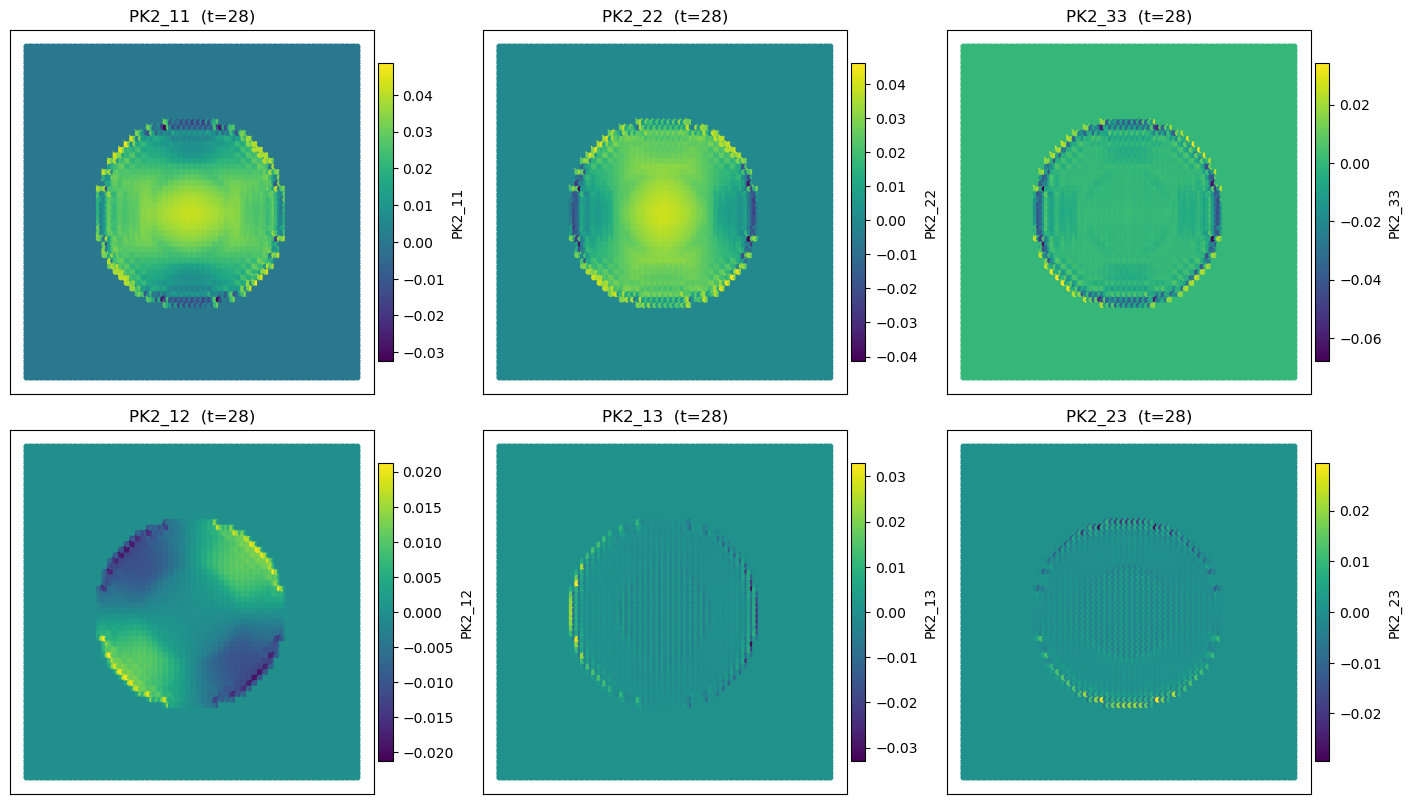

In [95]:
# ===== Plot PK2 (bottom IPs) for one snapshot =====
import numpy as np, pandas as pd, zarr, matplotlib.pyplot as plt

# --- user inputs ---
PK2_ZARR_PATH  = "pk2_bottom_ip.zarr"                    # your PK2 store (bottom layer, no node mapping)
NODES_CSV_PATH = r"GOH_Nodes_Test_for_Visualization.csv" # id,x,y,z
ELEMS_CSV_PATH = r"GOH_Elements_Test_for_Visualization.csv"  # elemLabel, n1..n8
SNAP_IDX       = 20                                       # which snapshot column to plot
COMPONENTS     = ["11","22","33","12","13","23"]         # order stored in Zarr
PLOT_ALL       = True                                    # True: 2x3 grid; False: set COMP_TO_PLOT below
COMP_TO_PLOT   = "von_mises"                             # if PLOT_ALL=False, choose one: "11","22","33","12","13","23","von_mises"

# --- helpers ---
def hex8_shape_functions(xi, eta, zeta):
    # local coords for the 8 corner nodes (standard HEX8 order)
    local = np.array([
        [-1, -1, -1],
        [ 1, -1, -1],
        [ 1,  1, -1],
        [-1,  1, -1],
        [-1, -1,  1],
        [ 1, -1,  1],
        [ 1,  1,  1],
        [-1,  1,  1],
    ], dtype=float)
    return 0.125 * (1 + local[:,0]*xi) * (1 + local[:,1]*eta) * (1 + local[:,2]*zeta)

def gauss_points_2x2x2(a=1.0/np.sqrt(3.0)):
    # fixed Abaqus-like order 1..8 (no 7/8 swapping here)
    return [(-a,-a,-a), (+a,-a,-a), (+a,+a,-a), (-a,+a,-a),
            (-a,-a,+a), (+a,-a,+a), (+a,+a,+a), (-a,+a,+a)]

def compute_ip_positions_hex8(node_coords, elem_conn):
    """Return (Ne*8,3) IP positions for 2x2x2 Gauss points."""
    pts = gauss_points_2x2x2()
    Ne  = elem_conn.shape[0]
    out = np.zeros((Ne*8, 3), dtype=float)
    for e in range(Ne):
        X = node_coords[elem_conn[e]]  # (8,3)
        for ip_i, (xi,eta,zeta) in enumerate(pts, start=1):
            N = hex8_shape_functions(xi,eta,zeta)[:, None]   # (8,1)
            out[e*8 + (ip_i-1), :] = (N * X).sum(axis=0)
    return out  # (Ne*8,3)

def assemble_pk2_voigt_to_tensor(voigt):  # (N,6) -> (N,3,3)
    S = np.zeros((voigt.shape[0], 3, 3), dtype=voigt.dtype)
    S[:,0,0] = voigt[:,0]  # 11
    S[:,1,1] = voigt[:,1]  # 22
    S[:,2,2] = voigt[:,2]  # 33
    S[:,0,1] = S[:,1,0] = voigt[:,3]  # 12
    S[:,0,2] = S[:,2,0] = voigt[:,4]  # 13
    S[:,1,2] = S[:,2,1] = voigt[:,5]  # 23
    return S

def von_mises_3D(S):  # S: (...,3,3)
    # σ_vm = sqrt(3/2 ||dev(S)||_F^2)
    tr = (S[...,0,0] + S[...,1,1] + S[...,2,2]) / 3.0
    dev = S.copy()
    dev[...,0,0] -= tr
    dev[...,1,1] -= tr
    dev[...,2,2] -= tr
    j2 = 0.5 * ((dev**2).sum(axis=(-2,-1)))  # J2 = 1/2 dev:dev
    return np.sqrt(3.0 * j2)

# --- load mesh ---
nodes_df = pd.read_csv(NODES_CSV_PATH, header=None, names=["id","x","y","z"])
node_ids = nodes_df["id"].to_numpy(dtype=int)
xyz_all  = nodes_df[["x","y","z"]].to_numpy(dtype=float)
id_to_idx = {nid:i for i,nid in enumerate(node_ids)}

elems_df = pd.read_csv(ELEMS_CSV_PATH, header=None)
elem_labels = elems_df.iloc[:,0].to_numpy(dtype=int)           # (Ne,)
elem_nodes  = elems_df.iloc[:,1:9].to_numpy(dtype=int)         # (Ne,8) node IDs
# map node IDs -> 0-based indices into xyz_all
elem_conn = np.vectorize(id_to_idx.get)(elem_nodes)

# --- compute all 8-IP positions per element ---
ip_pos_all = compute_ip_positions_hex8(xyz_all, elem_conn)     # (Ne*8,3)

# --- open Zarr and fetch bottom-layer mapping/order + snapshot ---
g  = zarr.open_group(PK2_ZARR_PATH, mode="r")
sn = g["snaps_PK2_bottom"]      # shape (6 * (Ne*4), S)
times = np.asarray(g["times"])
mg = g["meta"]
kept_flats = mg["bottom_flat_indices"][:]   # (Ne*4,) flat IP indices into ip_pos_all
# sanity: derive how many kept IPs
N_kept = kept_flats.size
assert sn.shape[0] == 6 * N_kept, "Row count does not match 6 * (#kept IPs)."

Smax = sn.shape[1]
if SNAP_IDX < 0: SNAP_IDX += Smax
if not (0 <= SNAP_IDX < Smax):
    raise ValueError(f"SNAP_IDX={SNAP_IDX} out of range 0..{Smax-1}")

col = np.asarray(sn[:, SNAP_IDX])           # (6*N_kept,)
voigt = col.reshape(N_kept, 6)              # (N_kept,6)
S_pk2 = assemble_pk2_voigt_to_tensor(voigt) # (N_kept,3,3)

# --- positions of just the kept bottom IPs, in the same order as snapshots ---
pos = ip_pos_all[kept_flats]                # (N_kept,3)
x, y, z = pos.T

# --- choose what to plot ---
def plot_component(vals, title):
    fig, ax = plt.subplots(figsize=(6, 5))
    sc = ax.scatter(x, y, c=vals, s=10, cmap="viridis")
    ax.set_title(title + f"\n(t={times[SNAP_IDX]:.6g})")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    cb = plt.colorbar(sc, ax=ax, shrink=0.85, pad=0.02)
    cb.set_label(title)
    plt.show()

if PLOT_ALL:
    comp_vals = {
        "11": S_pk2[:,0,0],
        "22": S_pk2[:,1,1],
        "33": S_pk2[:,2,2],
        "12": S_pk2[:,0,1],
        "13": S_pk2[:,0,2],
        "23": S_pk2[:,1,2],
    }
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
    axes = axes.ravel()
    for i, comp in enumerate(["11","22","33","12","13","23"]):
        vals = comp_vals[comp]
        sc = axes[i].scatter(x, y, c=vals, s=10, cmap="viridis")
        axes[i].set_title(f"PK2_{comp}  (t={times[SNAP_IDX]:.6g})")
        axes[i].set_aspect("equal", adjustable="box")
        axes[i].set_xticks([]); axes[i].set_yticks([])
        cb = plt.colorbar(sc, ax=axes[i], shrink=0.8, pad=0.01)
        cb.set_label(f"PK2_{comp}")
    plt.show()
else:
    if COMP_TO_PLOT == "von_mises":
        vm = von_mises_3D(S_pk2)
        plot_component(vm, "PK2 von Mises")
    else:
        idx = {"11":(0,0), "22":(1,1), "33":(2,2),
               "12":(0,1), "13":(0,2), "23":(1,2)}[COMP_TO_PLOT]
        plot_component(S_pk2[:,idx[0],idx[1]], f"PK2_{COMP_TO_PLOT}")

## Build Contact Pressure Snapshots

In [86]:
# ================================
# CPRESS snapshot extractor (NODAL)
# ================================
import re, glob, time
import numpy as np
import zarr

# ---- CONFIG YOU CAN TWEAK ----
N_CHECKPOINT = 50          # print progress every N frames
DTYPE_X      = "f4"        # storage dtype for snapshots
ROW_CHUNK    = 16_384      # row chunk for zarr array
# --------------------------------

# --- Parsers ---
FRAME_RE        = re.compile(r"^###\s*Frame Time:\s*([0-9.+\-Ee]+)\s*###")
SECTION_NODAL   = "=== NODAL DATA ==="

def iter_cpress_snapshots(csv_path):
    """
    Yields (time, node_labels, CPRESS) for each frame in one CSV.
    CPRESS shape: (N,) as float32; node_labels shape: (N,) int64.
    """
    with open(csv_path, "r", encoding="utf-8", errors="ignore") as f:
        pushback = None

        def readline():
            nonlocal pushback
            if pushback is not None:
                s = pushback; pushback = None; return s
            s = f.readline()
            return s if s != "" else None

        def unread(s):
            nonlocal pushback
            pushback = s

        while True:
            line = readline()
            if line is None:
                return
            m = FRAME_RE.match(line)
            if not m:
                continue
            t_val = float(m.group(1))

            # Skip next line (e.g., CVOL or blank)
            _ = readline()

            # Advance to NODAL section
            while True:
                line = readline()
                if line is None:
                    return
                if line.strip() == SECTION_NODAL:
                    break

            # Header row
            header = readline()
            if header is None:
                return
            cols = [c.strip() for c in header.strip().split(",")]
            # Required columns
            try:
                idx_node   = cols.index("NodeLabel")
                idx_cpress = cols.index("CPRESS")
            except ValueError:
                raise ValueError(f"Expected 'NodeLabel' and 'CPRESS' in header, got: {cols}")

            nodes = []
            cp    = []

            # Read until next section or next frame
            while True:
                line = readline()
                if line is None:
                    break
                s = line.strip()
                if (not s) or s.startswith("===") or s.startswith("### Frame Time:"):
                    unread(line)
                    break
                parts = s.split(",")
                if len(parts) <= max(idx_node, idx_cpress):
                    continue
                try:
                    n  = int(parts[idx_node])
                    c  = float(parts[idx_cpress])
                except ValueError:
                    continue
                nodes.append(n)
                cp.append(c)

            if nodes:
                yield t_val, np.asarray(nodes, dtype=np.int64), np.asarray(cp, dtype=np.float32)

# --- Zarr create-or-get helper (v2/v3 compatible) ---
def _require_array(g, name, shape, chunks, dtype):
    try:
        return g[name]
    except KeyError:
        pass
    try:
        # zarr v3
        return g.require_array(name, shape=shape, chunks=chunks, dtype=dtype)
    except TypeError:
        # zarr v2
        return g.require_dataset(name, shape=shape, chunks=chunks, dtype=dtype)

# --- Main builder ---
def build_cpress_zarr_resume(csv_glob_or_list,
                             zarr_path: str,
                             *,
                             chunks_snap: int = ROW_CHUNK,
                             dtype: str = DTYPE_X,
                             checkpoint_every: int = N_CHECKPOINT):
    """
    Stream CPRESS from NODAL DATA across all CSVs and append to Zarr.

    Creates (or appends to):
      - /snaps_CPRESS : (N, S)     float (one column per frame)
      - /times        : (S,)       float32 frame times
      - /meta/node_labels : (N,)   int64 (fixed node order)
      - attrs['checkpoint'] = {'file_idx','frame_idx','S_total'}

    Resume-safe: will continue at the last checkpoint; first mismatch in node order raises.
    """
    # Resolve file list
    if isinstance(csv_glob_or_list, (list, tuple)):
        files = [str(p) for p in csv_glob_or_list]
    else:
        files = sorted(glob.glob(csv_glob_or_list))
    if not files:
        raise FileNotFoundError(f"No files matched: {csv_glob_or_list}")

    g = zarr.open_group(zarr_path, mode="a")
    mg = g.require_group("meta")

    # Resume checkpoint
    ckpt = g.attrs.get("checkpoint", {"file_idx": 0, "frame_idx": 0, "S_total": 0})
    file_start = int(ckpt.get("file_idx", 0))
    frame_start_for_first = int(ckpt.get("frame_idx", 0))
    S_total = int(ckpt.get("S_total", 0))

    # Existing arrays (if any)
    snaps = g.get("snaps_CPRESS", None)
    times = g.get("times", None)
    node_labels = mg.get("node_labels", None)
    if node_labels is not None:
        node_labels = node_labels[:]
        N = len(node_labels)

    if snaps is not None and times is not None and S_total > 0:
        # Ensure arrays aren't longer than checkpoint (in case of prior partial writes)
        _, S_exist = snaps.shape
        if S_exist != S_total:
            snaps.resize((snaps.shape[0], S_total))
            times.resize((S_total,))

    wrote_any = False
    print(f"[info] Starting CPRESS extraction on {len(files)} file(s).", flush=True)

    for i in range(file_start, len(files)):
        fp = files[i]
        frame_counter = 0
        for t, nodes, cpress in iter_cpress_snapshots(fp):
            # Skip frames already processed in the current resume file
            if i == file_start and frame_counter < frame_start_for_first:
                frame_counter += 1
                continue

            if node_labels is None:
                # First ever frame: initialize meta + arrays
                node_labels = nodes
                N = len(node_labels)
                # (re)create node_labels cleanly
                if "node_labels" in mg:
                    del mg["node_labels"]
                mg.create_array("node_labels", shape=(N,), dtype="i8")[:] = node_labels

                # Create (or reset) datasets
                if "snaps_CPRESS" in g: del g["snaps_CPRESS"]
                if "times"        in g: del g["times"]

                snaps = _require_array(
                    g, "snaps_CPRESS",
                    shape=(N, 0),
                    chunks=(min(N, chunks_snap), chunks_snap),
                    dtype=dtype
                )
                times = _require_array(
                    g, "times",
                    shape=(0,),
                    chunks=(chunks_snap,),
                    dtype="f4"
                )
                S_total = 0
            else:
                # Enforce identical node ordering for resume correctness
                if not np.array_equal(nodes, node_labels):
                    raise ValueError("Node order or set changed; CPRESS resume requires fixed node order.")

            # Append this frame
            snaps.resize((N, S_total+1))
            snaps[:, S_total] = cpress.astype(dtype)

            times.resize((S_total+1,))
            times[S_total] = np.float32(t)

            S_total += 1
            frame_counter += 1
            wrote_any = True

            if checkpoint_every and (S_total % checkpoint_every) == 0:
                g.attrs["checkpoint"] = {"file_idx": i, "frame_idx": frame_counter, "S_total": S_total}
                print(f"[checkpoint] Written {S_total} snapshots so far (file {i+1}/{len(files)})", flush=True)

        # Checkpoint at file boundary
        g.attrs["checkpoint"] = {"file_idx": i+1, "frame_idx": 0, "S_total": S_total}

    # Final checkpoint
    g.attrs["checkpoint"] = {"file_idx": len(files), "frame_idx": 0, "S_total": S_total}

    msg = "Appended" if wrote_any else "Nothing to append (already complete)"
    print(f"[info] {msg}. Total CPRESS snapshots: {S_total}.", flush=True)

In [87]:
# Using your existing file list:
# CSV_GLOB = [str(p) for p in files]  # as you prepared earlier

_ = build_cpress_zarr_resume(
    CSV_GLOB,
    zarr_path="cpress.zarr",
    chunks_snap=16_384,
    dtype="f4",
    checkpoint_every=50
)

[info] Starting CPRESS extraction on 928 file(s).
[checkpoint] Written 950 snapshots so far (file 19/928)
[checkpoint] Written 1000 snapshots so far (file 20/928)
[checkpoint] Written 1050 snapshots so far (file 21/928)
[checkpoint] Written 1100 snapshots so far (file 22/928)
[checkpoint] Written 1150 snapshots so far (file 24/928)
[checkpoint] Written 1200 snapshots so far (file 26/928)
[checkpoint] Written 1250 snapshots so far (file 26/928)
[checkpoint] Written 1300 snapshots so far (file 27/928)
[checkpoint] Written 1350 snapshots so far (file 28/928)
[checkpoint] Written 1400 snapshots so far (file 29/928)
[checkpoint] Written 1450 snapshots so far (file 30/928)
[checkpoint] Written 1500 snapshots so far (file 31/928)
[checkpoint] Written 1550 snapshots so far (file 31/928)
[checkpoint] Written 1600 snapshots so far (file 32/928)
[checkpoint] Written 1650 snapshots so far (file 34/928)
[checkpoint] Written 1700 snapshots so far (file 34/928)
[checkpoint] Written 1750 snapshots so 

KeyboardInterrupt: 